In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yomnaahelali/raw-document/2010 - mashboot.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/2008 - peering - scanned.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/2002 - sce api.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/1999 - tcs - scanned.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/2008 - vub.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/2004 - jse.doc
/kaggle/input/datasets/yomnaahelali/raw-document/0000 - inventory - scanned.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/2004 - watcom gui.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/2003 - pnnl - scanned.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/2007 - eirene fun 7 - scanned.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/2001 - beyond - scanned.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/2007 - puget sound.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/0000 - cctns-scanned.pdf
/kaggle/input/datasets/yomnaahelali/raw-document/19

In [2]:


import numpy as np
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [3]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================================
# MODULE C1 — DATASET-BASED SRS TEMPLATE COMPLIANCE
# =========================================

In [4]:
# =========================================
# STEP C1.1 - Build canonical SRS template dataset
# =========================================

canonical_srs_rows = [
    {"order_id": 1, "section": "introduction"},
    {"order_id": 2, "section": "general_description"},
    {"order_id": 3, "section": "functional_requirements"},
    {"order_id": 4, "section": "interface_requirements"},
    {"order_id": 5, "section": "performance_requirements"},
    {"order_id": 6, "section": "design_constraints"},
    {"order_id": 7, "section": "non_functional_requirements"},
    {"order_id": 8, "section": "risks"},
    {"order_id": 9, "section": "acceptance_criteria"},
    {"order_id": 10, "section": "appendices"}
]

df_canonical_srs = pd.DataFrame(canonical_srs_rows)

print("Canonical SRS dataset shape:", df_canonical_srs.shape)
display(df_canonical_srs)

Canonical SRS dataset shape: (10, 2)


,order_id,section
0,1,introduction
1,2,general_description
2,3,functional_requirements
3,4,interface_requirements
4,5,performance_requirements
5,6,design_constraints
6,7,non_functional_requirements
7,8,risks
8,9,acceptance_criteria
9,10,appendices


In [5]:
# =========================================
# STEP C1.2 - Build section pattern dataset
# =========================================

section_pattern_rows = [
    {"section": "introduction", "pattern": "introduction", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "introduction", "pattern": "purpose", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "introduction", "pattern": "scope", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "introduction", "pattern": "overview", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "general_description", "pattern": "general description", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "general_description", "pattern": "product perspective", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "general_description", "pattern": "product functions", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "general_description", "pattern": "user classes", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "general_description", "pattern": "operating environment", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "functional_requirements", "pattern": "functional requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "functional_requirements", "pattern": "system features", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "functional_requirements", "pattern": "functionalities", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "interface_requirements", "pattern": "interface requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "external interfaces", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "user interface", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "software interfaces", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "hardware interfaces", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "performance_requirements", "pattern": "performance requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "performance_requirements", "pattern": "response time", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "performance_requirements", "pattern": "latency", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "performance_requirements", "pattern": "throughput", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "design_constraints", "pattern": "design constraints", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "design_constraints", "pattern": "constraints", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "design_constraints", "pattern": "technical limitations", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "design_constraints", "pattern": "standards compliance", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "non_functional_requirements", "pattern": "non-functional requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "non functional requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "quality attributes", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "security", "pattern_type": "heading_keyword", "weight": 1, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "usability", "pattern_type": "heading_keyword", "weight": 1, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "reliability", "pattern_type": "heading_keyword", "weight": 1, "source": "manual_template"},

    {"section": "risks", "pattern": "risks", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "risks", "pattern": "risk analysis", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "risks", "pattern": "project risks", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "risks", "pattern": "assumptions and dependencies", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "acceptance_criteria", "pattern": "acceptance criteria", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "acceptance_criteria", "pattern": "validation criteria", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "acceptance_criteria", "pattern": "success criteria", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "acceptance_criteria", "pattern": "definition of done", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "appendices", "pattern": "appendix", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "appendices", "pattern": "appendices", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "appendices", "pattern": "glossary", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "appendices", "pattern": "references", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"}
]

df_section_patterns = pd.DataFrame(section_pattern_rows)

print("Section pattern dataset shape:", df_section_patterns.shape)
display(df_section_patterns.head(20))

Section pattern dataset shape: (43, 5)


,section,pattern,pattern_type,weight,source
0,introduction,introduction,heading,3,manual_template
1,introduction,purpose,heading_keyword,2,manual_template
2,introduction,scope,heading_keyword,2,manual_template
3,introduction,overview,heading_keyword,2,manual_template
4,general_description,general description,heading,3,manual_template
5,general_description,product perspective,heading_keyword,2,manual_template
6,general_description,product functions,heading_keyword,2,manual_template
7,general_description,user classes,heading_keyword,2,manual_template
8,general_description,operating environment,heading_keyword,2,manual_template
9,functional_requirements,functional requirements,heading,3,manual_template


In [6]:
# =========================================
# STEP C1.3 - Normalize heading text
# =========================================

import re

def normalize_heading_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"^\d+(\.\d+)*\s*", "", text)
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print(normalize_heading_text("3.2 Functional Requirements"))
print(normalize_heading_text("1. Introduction and Scope"))

functional requirements
introduction and scope


In [7]:
# =========================================
# STEP C1.4 - Section detection from heading using dataset
# =========================================

def detect_section_from_heading_dataset(heading, pattern_df):
    heading_norm = normalize_heading_text(heading)

    matched = pattern_df[
        pattern_df["pattern"].apply(lambda p: normalize_heading_text(p) in heading_norm)
    ].copy()

    if matched.empty:
        return {
            "raw_heading": heading,
            "normalized_heading": heading_norm,
            "predicted_section": "unknown",
            "matched_patterns": [],
            "total_weight": 0
        }

    section_scores = matched.groupby("section")["weight"].sum().sort_values(ascending=False)
    best_section = section_scores.index[0]

    return {
        "raw_heading": heading,
        "normalized_heading": heading_norm,
        "predicted_section": best_section,
        "matched_patterns": matched["pattern"].tolist(),
        "total_weight": int(section_scores.iloc[0])
    }

print(detect_section_from_heading_dataset("3. Functional Requirements", df_section_patterns))
print(detect_section_from_heading_dataset("1. Introduction and Scope", df_section_patterns))
print(detect_section_from_heading_dataset("External Interfaces", df_section_patterns))

{'raw_heading': '3. Functional Requirements', 'normalized_heading': 'functional requirements', 'predicted_section': 'functional_requirements', 'matched_patterns': ['functional requirements'], 'total_weight': 3}
{'raw_heading': '1. Introduction and Scope', 'normalized_heading': 'introduction and scope', 'predicted_section': 'introduction', 'matched_patterns': ['introduction', 'scope'], 'total_weight': 5}
{'raw_heading': 'External Interfaces', 'normalized_heading': 'external interfaces', 'predicted_section': 'interface_requirements', 'matched_patterns': ['external interfaces'], 'total_weight': 2}


In [8]:
# =========================================
# STEP C1.5 - Build sample heading dataframe
# =========================================

sample_detected_headings = [
    "1. Introduction",
    "2. General Description",
    "3. Functional Requirements",
    "4. Interface Requirements",
    "5. Non-Functional Requirements",
    "6. Risks",
    "7. Acceptance Criteria"
]

heading_results = [
    detect_section_from_heading_dataset(h, df_section_patterns)
    for h in sample_detected_headings
]

sample_heading_df = pd.DataFrame(heading_results)
display(sample_heading_df)

,raw_heading,normalized_heading,predicted_section,matched_patterns,total_weight
0,1. Introduction,introduction,introduction,[introduction],3
1,2. General Description,general description,general_description,[general description],3
2,3. Functional Requirements,functional requirements,functional_requirements,[functional requirements],3
3,4. Interface Requirements,interface requirements,interface_requirements,[interface requirements],3
4,5. Non-Functional Requirements,non-functional requirements,functional_requirements,"[functional requirements, non-functional requi...",3
5,6. Risks,risks,risks,[risks],3
6,7. Acceptance Criteria,acceptance criteria,acceptance_criteria,[acceptance criteria],3


In [9]:
# =========================================
# STEP C1.6 - Compare headings to canonical SRS dataset
# =========================================

def compare_detected_sections_to_template(detected_sections, canonical_df):
    canonical_sections = canonical_df["section"].tolist()
    detected_clean = [s for s in detected_sections if s != "unknown"]

    present_sections = [s for s in canonical_sections if s in detected_clean]
    missing_sections = [s for s in canonical_sections if s not in detected_clean]
    unexpected_sections = [s for s in detected_clean if s not in canonical_sections]

    return {
        "present_sections": present_sections,
        "missing_sections": missing_sections,
        "unexpected_sections": unexpected_sections
    }

template_compare_result = compare_detected_sections_to_template(
    sample_heading_df["predicted_section"].tolist(),
    df_canonical_srs
)

template_compare_result

{'present_sections': ['introduction',
  'general_description',
  'functional_requirements',
  'interface_requirements',
  'risks',
  'acceptance_criteria'],
 'missing_sections': ['performance_requirements',
  'design_constraints',
  'non_functional_requirements',
  'appendices'],
 'unexpected_sections': []}

In [10]:
# =========================================
# STEP C1.7 - Compute order score
# =========================================

def compute_dataset_order_score(detected_sections, canonical_df):
    canonical_order = {
        row["section"]: row["order_id"]
        for _, row in canonical_df.iterrows()
    }

    detected_clean = [s for s in detected_sections if s in canonical_order]

    if len(detected_clean) <= 1:
        return 1.0

    correct_pairs = 0
    total_pairs = 0

    for i in range(len(detected_clean)):
        for j in range(i + 1, len(detected_clean)):
            total_pairs += 1
            if canonical_order[detected_clean[i]] <= canonical_order[detected_clean[j]]:
                correct_pairs += 1

    if total_pairs == 0:
        return 1.0

    return round(correct_pairs / total_pairs, 3)

order_score = compute_dataset_order_score(
    sample_heading_df["predicted_section"].tolist(),
    df_canonical_srs
)

print("Order score:", order_score)

Order score: 0.952


In [11]:
# =========================================
# STEP C1.8 - Compute template compliance score
# =========================================

def compute_dataset_template_compliance(detected_sections, canonical_df):
    compare_result = compare_detected_sections_to_template(detected_sections, canonical_df)

    present_ratio = len(compare_result["present_sections"]) / len(canonical_df)
    order_score = compute_dataset_order_score(detected_sections, canonical_df)

    template_compliance_score = round((0.7 * present_ratio) + (0.3 * order_score), 3)

    recommendations = []
    if len(compare_result["missing_sections"]) > 0:
        recommendations.append("add_missing_sections")
    if order_score < 1.0:
        recommendations.append("reorganize_sections")
    if len(compare_result["unexpected_sections"]) > 0:
        recommendations.append("review_unexpected_sections")

    return {
        "present_sections": compare_result["present_sections"],
        "missing_sections": compare_result["missing_sections"],
        "unexpected_sections": compare_result["unexpected_sections"],
        "order_score": order_score,
        "template_compliance_score": template_compliance_score,
        "recommendations": recommendations
    }

compliance_result = compute_dataset_template_compliance(
    sample_heading_df["predicted_section"].tolist(),
    df_canonical_srs
)

compliance_result

{'present_sections': ['introduction',
  'general_description',
  'functional_requirements',
  'interface_requirements',
  'risks',
  'acceptance_criteria'],
 'missing_sections': ['performance_requirements',
  'design_constraints',
  'non_functional_requirements',
  'appendices'],
 'unexpected_sections': [],
 'order_score': 0.952,
 'template_compliance_score': 0.706,
 'recommendations': ['add_missing_sections', 'reorganize_sections']}

In [12]:
# =========================================
# STEP C1.9 - Build compliance dataframe
# =========================================

compliance_df = pd.DataFrame([
    {
        "present_sections": ", ".join(compliance_result["present_sections"]),
        "missing_sections": ", ".join(compliance_result["missing_sections"]),
        "unexpected_sections": ", ".join(compliance_result["unexpected_sections"]),
        "order_score": compliance_result["order_score"],
        "template_compliance_score": compliance_result["template_compliance_score"],
        "recommendations": ", ".join(compliance_result["recommendations"])
    }
])

display(compliance_df)

,present_sections,missing_sections,unexpected_sections,order_score,template_compliance_score,recommendations
0,"introduction, general_description, functional_...","performance_requirements, design_constraints, ...",,0.952,0.706,"add_missing_sections, reorganize_sections"


In [13]:
# =========================================
# STEP C1.10 - Reusable compliance function
# =========================================

def analyze_document_template_compliance_dataset(headings_list):
    heading_results = [
        detect_section_from_heading_dataset(h, df_section_patterns)
        for h in headings_list
    ]

    heading_df = pd.DataFrame(heading_results)

    compliance = compute_dataset_template_compliance(
        heading_df["predicted_section"].tolist(),
        df_canonical_srs
    )

    return {
        "heading_table": heading_df,
        "compliance_result": compliance
    }

doc_result = analyze_document_template_compliance_dataset([
    "1. Introduction",
    "2. General Description",
    "3. Functional Requirements",
    "4. Risks",
    "5. Acceptance Criteria"
])

display(doc_result["heading_table"])
doc_result["compliance_result"]

,raw_heading,normalized_heading,predicted_section,matched_patterns,total_weight
0,1. Introduction,introduction,introduction,[introduction],3
1,2. General Description,general description,general_description,[general description],3
2,3. Functional Requirements,functional requirements,functional_requirements,[functional requirements],3
3,4. Risks,risks,risks,[risks],3
4,5. Acceptance Criteria,acceptance criteria,acceptance_criteria,[acceptance criteria],3


{'present_sections': ['introduction',
  'general_description',
  'functional_requirements',
  'risks',
  'acceptance_criteria'],
 'missing_sections': ['interface_requirements',
  'performance_requirements',
  'design_constraints',
  'non_functional_requirements',
  'appendices'],
 'unexpected_sections': [],
 'order_score': 1.0,
 'template_compliance_score': 0.65,
 'recommendations': ['add_missing_sections']}

# =========================================================
# MODULE C0 — DOCUMENT INPUT / OCR / BLOCK EXTRACTION
# =========================================================

# # =========================================================
# MODULE C0.9 — MULTI-PDF / XML CORPUS INVENTORY
# =========================================================

In [14]:
# =========================================================
# MODULE C0.9B — DEFINE ROOT PATHS ROBUSTLY
# =========================================================

from pathlib import Path
import os
import re
import pandas as pd

def first_existing_path(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    raise FileNotFoundError("None of these paths exist:\n" + "\n".join(map(str, candidates)))

RAW_DOCS_ROOT = first_existing_path([
    "/kaggle/input/datasets/yomnaahelali/raw-document"

])

PAGE_IMAGES_ROOT = first_existing_path([
    "/kaggle/input/datasets/yomnaahelali/page-image/page_images"
])

print("RAW_DOCS_ROOT:", RAW_DOCS_ROOT)
print("Exists:", RAW_DOCS_ROOT.exists())

print("PAGE_IMAGES_ROOT:", PAGE_IMAGES_ROOT)
print("Exists:", PAGE_IMAGES_ROOT.exists())

RAW_DOCS_ROOT: /kaggle/input/datasets/yomnaahelali/raw-document
Exists: True
PAGE_IMAGES_ROOT: /kaggle/input/datasets/yomnaahelali/page-image/page_images
Exists: True


In [15]:
# =========================================================
# MODULE C0.10 — RAW DOCUMENTS INVENTORY
# =========================================================

raw_files = []

for root, _, files in os.walk(RAW_DOCS_ROOT):
    for fname in files:
        fpath = Path(root) / fname
        ext = fpath.suffix.lower()

        if ext in [".pdf", ".xml", ".png", ".jpg", ".jpeg"]:
            raw_files.append({
                "file_name": fname,
                "file_path": str(fpath),
                "extension": ext,
                "parent_folder": fpath.parent.name
            })

df_raw_files = pd.DataFrame(raw_files)

print("Total raw files found:", len(df_raw_files))
display(df_raw_files.head(30))

Total raw files found: 124


,file_name,file_path,extension,parent_folder
0,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document
1,2008 - peering - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document
2,2002 - sce api.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document
3,1999 - tcs - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document
4,2008 - vub.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document
5,0000 - inventory - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document
6,2004 - watcom gui.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document
7,2003 - pnnl - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document
8,2007 - eirene fun 7 - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document
9,2001 - beyond - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document


In [16]:
# =========================================================
# MODULE C0.11 — NORMALIZE DOCUMENT IDS
# =========================================================

def normalize_doc_id(file_name):
    stem = Path(str(file_name)).stem.lower().strip()
    stem = stem.replace("_", " ").replace("-", " ")
    stem = re.sub(r"\s+", " ", stem).strip()
    return stem

df_raw_files["doc_id"] = df_raw_files["file_name"].apply(normalize_doc_id)

display(df_raw_files.head(30))

,file_name,file_path,extension,parent_folder,doc_id
0,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2010 mashboot
1,2008 - peering - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2008 peering scanned
2,2002 - sce api.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2002 sce api
3,1999 - tcs - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,1999 tcs scanned
4,2008 - vub.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2008 vub
5,0000 - inventory - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,0000 inventory scanned
6,2004 - watcom gui.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2004 watcom gui
7,2003 - pnnl - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2003 pnnl scanned
8,2007 - eirene fun 7 - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2007 eirene fun 7 scanned
9,2001 - beyond - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2001 beyond scanned


In [17]:
# =========================================================
# MODULE C0.12 — SPLIT RAW FILE TYPES
# =========================================================

df_pdfs = df_raw_files[df_raw_files["extension"] == ".pdf"].copy()
df_xmls = df_raw_files[df_raw_files["extension"] == ".xml"].copy()
df_raw_images = df_raw_files[df_raw_files["extension"].isin([".png", ".jpg", ".jpeg"])].copy()

print("PDF count:", len(df_pdfs))
print("XML count:", len(df_xmls))
print("Raw image count:", len(df_raw_images))

display(df_pdfs.head(10))
display(df_xmls.head(10))
display(df_raw_images.head(10))

PDF count: 124
XML count: 0
Raw image count: 0


,file_name,file_path,extension,parent_folder,doc_id
0,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2010 mashboot
1,2008 - peering - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2008 peering scanned
2,2002 - sce api.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2002 sce api
3,1999 - tcs - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,1999 tcs scanned
4,2008 - vub.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2008 vub
5,0000 - inventory - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,0000 inventory scanned
6,2004 - watcom gui.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2004 watcom gui
7,2003 - pnnl - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2003 pnnl scanned
8,2007 - eirene fun 7 - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2007 eirene fun 7 scanned
9,2001 - beyond - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,.pdf,raw-document,2001 beyond scanned


,file_name,file_path,extension,parent_folder,doc_id


,file_name,file_path,extension,parent_folder,doc_id


In [18]:
# =========================================================
# MODULE C0.13 — BUILD DOCUMENT REGISTRY
# =========================================================

df_pdf_registry = df_pdfs[["doc_id", "file_name", "file_path"]].rename(columns={
    "file_name": "pdf_file_name",
    "file_path": "pdf_path"
})

df_xml_registry = df_xmls[["doc_id", "file_name", "file_path"]].rename(columns={
    "file_name": "xml_file_name",
    "file_path": "xml_path"
})

df_document_registry = pd.merge(
    df_pdf_registry,
    df_xml_registry,
    on="doc_id",
    how="left"
)

df_document_registry["has_pdf"] = df_document_registry["pdf_path"].notna().astype(int)
df_document_registry["has_xml"] = df_document_registry["xml_path"].notna().astype(int)

print("Document registry shape:", df_document_registry.shape)
display(df_document_registry.head(30))

Document registry shape: (124, 7)


,doc_id,pdf_file_name,pdf_path,xml_file_name,xml_path,has_pdf,has_xml
0,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
1,2008 peering scanned,2008 - peering - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
2,2002 sce api,2002 - sce api.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
3,1999 tcs scanned,1999 - tcs - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
4,2008 vub,2008 - vub.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
5,0000 inventory scanned,0000 - inventory - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
6,2004 watcom gui,2004 - watcom gui.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
7,2003 pnnl scanned,2003 - pnnl - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
8,2007 eirene fun 7 scanned,2007 - eirene fun 7 - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
9,2001 beyond scanned,2001 - beyond - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0


In [19]:
# =========================================================
# MODULE C0.14 — PAGE IMAGE INVENTORY
# =========================================================

image_rows = []

for doc_folder in PAGE_IMAGES_ROOT.iterdir():
    if doc_folder.is_dir():
        doc_folder_name = doc_folder.name

        for img_file in sorted(doc_folder.glob("*.png")):
            fname = img_file.name

            page_match = re.search(r"-(\d+)\.png$", fname.lower())
            page_num = int(page_match.group(1)) if page_match else None

            image_rows.append({
                "doc_folder": doc_folder_name,
                "image_file_name": fname,
                "image_path": str(img_file),
                "page_num": page_num
            })

df_page_images = pd.DataFrame(image_rows)

# MODULE C0.15 — NORMALIZE IMAGE DOC IDS

df_page_images["doc_id"] = df_page_images["doc_folder"].apply(
    lambda x: re.sub(r"\s+", " ", str(x).lower().replace("-", " ")).strip()
)

print("Total page images found:", len(df_page_images))
display(df_page_images.head(20))

Total page images found: 5666


,doc_folder,image_file_name,image_path,page_num,doc_id
0,2005 - triangle - scanned,2005 - triangle - scanned-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,1,2005 triangle scanned
1,2005 - triangle - scanned,2005 - triangle - scanned-02.png,/kaggle/input/datasets/yomnaahelali/page-image...,2,2005 triangle scanned
2,2005 - triangle - scanned,2005 - triangle - scanned-03.png,/kaggle/input/datasets/yomnaahelali/page-image...,3,2005 triangle scanned
3,2005 - triangle - scanned,2005 - triangle - scanned-04.png,/kaggle/input/datasets/yomnaahelali/page-image...,4,2005 triangle scanned
4,2005 - triangle - scanned,2005 - triangle - scanned-05.png,/kaggle/input/datasets/yomnaahelali/page-image...,5,2005 triangle scanned
5,2005 - triangle - scanned,2005 - triangle - scanned-06.png,/kaggle/input/datasets/yomnaahelali/page-image...,6,2005 triangle scanned
6,2005 - triangle - scanned,2005 - triangle - scanned-07.png,/kaggle/input/datasets/yomnaahelali/page-image...,7,2005 triangle scanned
7,2005 - triangle - scanned,2005 - triangle - scanned-08.png,/kaggle/input/datasets/yomnaahelali/page-image...,8,2005 triangle scanned
8,2005 - triangle - scanned,2005 - triangle - scanned-09.png,/kaggle/input/datasets/yomnaahelali/page-image...,9,2005 triangle scanned
9,2005 - triangle - scanned,2005 - triangle - scanned-10.png,/kaggle/input/datasets/yomnaahelali/page-image...,10,2005 triangle scanned


In [20]:
# =========================================================
# MODULE C0.16 — BUILD PAGES DATASET
# =========================================================

df_pages_dataset = pd.merge(
    df_page_images,
    df_document_registry,
    on="doc_id",
    how="left"
)

df_pages_dataset = df_pages_dataset[[
    "doc_id",
    "page_num",
    "image_file_name",
    "image_path",
    "pdf_file_name",
    "pdf_path",
    "xml_file_name",
    "xml_path",
    "has_pdf",
    "has_xml"
]].sort_values(by=["doc_id", "page_num"]).reset_index(drop=True)

print("Pages dataset shape:", df_pages_dataset.shape)
display(df_pages_dataset.head(20))

Pages dataset shape: (5666, 10)


,doc_id,page_num,image_file_name,image_path,pdf_file_name,pdf_path,xml_file_name,xml_path,has_pdf,has_xml
0,0000 cctns,1,0000 - cctns-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
1,0000 cctns,2,0000 - cctns-02.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
2,0000 cctns,3,0000 - cctns-03.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
3,0000 cctns,4,0000 - cctns-04.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
4,0000 cctns,5,0000 - cctns-05.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
5,0000 cctns,6,0000 - cctns-06.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
6,0000 cctns,7,0000 - cctns-07.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
7,0000 cctns,8,0000 - cctns-08.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
8,0000 cctns,9,0000 - cctns-09.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
9,0000 cctns,10,0000 - cctns-10.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0


In [21]:
# =========================================================
# MODULE C0.17 — SAVE REGISTRY AND PAGES DATASET
# =========================================================

document_registry_path = "/kaggle/working/document_registry.csv"
pages_dataset_path = "/kaggle/working/pages_dataset.csv"

df_document_registry.to_csv(document_registry_path, index=False)
df_pages_dataset.to_csv(pages_dataset_path, index=False)

print("Saved:", document_registry_path)
print("Saved:", pages_dataset_path)

Saved: /kaggle/working/document_registry.csv
Saved: /kaggle/working/pages_dataset.csv



# =========================================================
# MODULE C1 — VISUAL PREVIEW AND PAGE-LEVEL VALIDATION
# =========================================================

In [22]:
# =========================================================
# MODULE C1.1 — BASIC CHECKS ON PAGES DATASET
# =========================================================

print("Pages dataset shape:", df_pages_dataset.shape)
print("\nUnique documents in pages dataset:", df_pages_dataset["doc_id"].nunique())
print("\nPages per document (first 20):")
display(df_pages_dataset.groupby("doc_id")["page_num"].count().sort_values(ascending=False).head(20))

Pages dataset shape: (5666, 10)

Unique documents in pages dataset: 124

Pages per document (first 20):


doc_id
2003 pnnl scanned             176
2003 pnnl                     176
1999 tcs scanned              148
1999 tcs                      148
2006 eirene sys 15 scanned    138
2006 eirene sys 15            138
2009 peppol scanned           127
2009 peppol                   127
2001 telescope scanned        107
2001 telescope                107
2005 clarus low scanned        99
2005 clarus low                99
2007 nde scanned               99
2007 nde                       99
2007 ertms                     98
2007 ertms scanned             98
2007 eirene fun 7              97
2007 eirene fun 7 scanned      97
1995 gemini                    96
1995 gemini scanned            96
Name: page_num, dtype: int64

In [23]:
# =========================================================
# MODULE C1.2 — PREVIEW DOCUMENT IDS
# =========================================================

sample_docs = df_pages_dataset["doc_id"].drop_duplicates().sort_values().tolist()[:10]

print("Sample document IDs:")
for d in sample_docs:
    print("-", d)

Sample document IDs:
- 0000 cctns
- 0000 cctns scanned
- 0000 gamma j
- 0000 gamma j scanned
- 0000 inventory
- 0000 inventory scanned
- 1995 gemini
- 1995 gemini scanned
- 1998 themas
- 1998 themas scanned


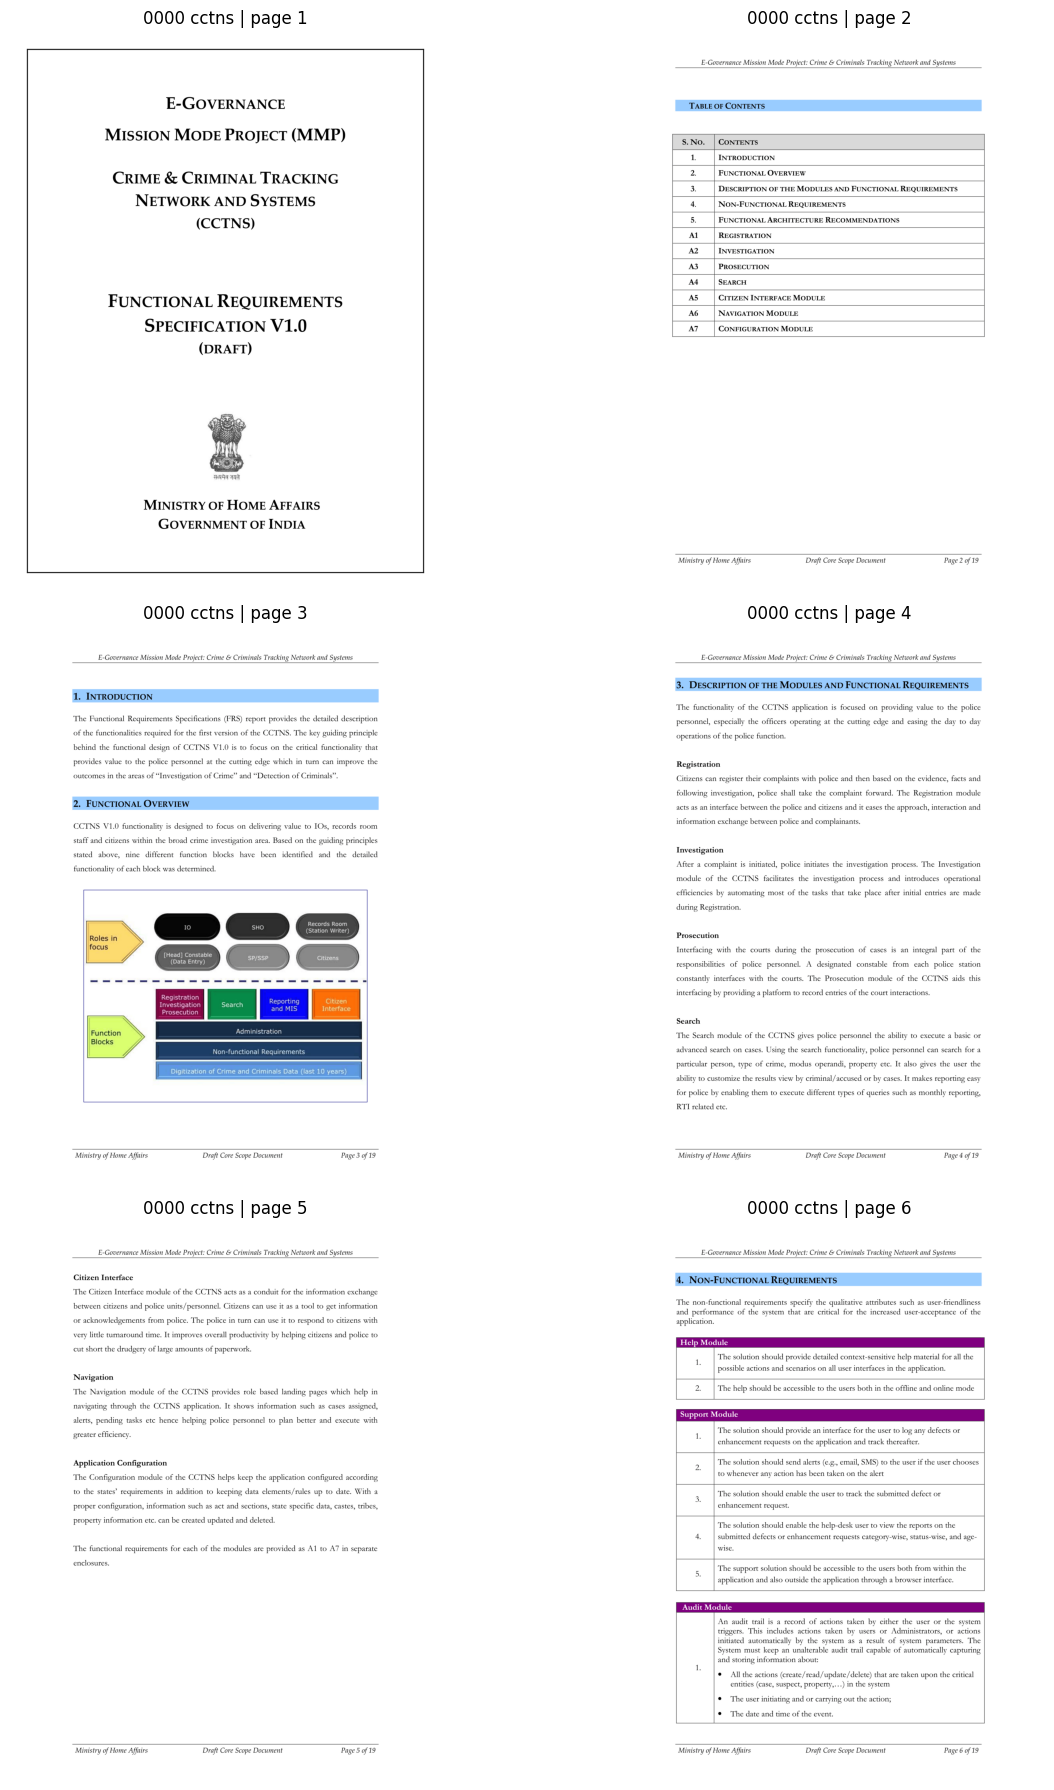

In [24]:
# =========================================================
# MODULE C1.3 — DISPLAY SAMPLE PAGE IMAGES
# =========================================================

import matplotlib.pyplot as plt
from PIL import Image

sample_rows = df_pages_dataset.head(6)

plt.figure(figsize=(14, 18))

for i, (_, row) in enumerate(sample_rows.iterrows(), start=1):
    img = Image.open(row["image_path"])
    
    plt.subplot(3, 2, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f'{row["doc_id"]} | page {row["page_num"]}')

plt.tight_layout()
plt.show()

In [25]:
# =========================================================
# MODULE C1.4 — FIRST PAGE OF SEVERAL DOCUMENTS
# =========================================================

first_pages = (
    df_pages_dataset.sort_values(["doc_id", "page_num"])
    .groupby("doc_id")
    .head(1)
    .reset_index(drop=True)
)

display(first_pages.head(20))

,doc_id,page_num,image_file_name,image_path,pdf_file_name,pdf_path,xml_file_name,xml_path,has_pdf,has_xml
0,0000 cctns,1,0000 - cctns-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
1,0000 cctns scanned,1,0000 - cctns - scanned-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns-scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
2,0000 gamma j,1,0000 - gamma j-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - gamma j.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
3,0000 gamma j scanned,1,0000 - gamma j - scanned-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - gamma j - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
4,0000 inventory,1,0000 - inventory-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - inventory.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
5,0000 inventory scanned,1,0000 - inventory - scanned-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - inventory - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
6,1995 gemini,1,1995 - gemini-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,1995 - gemini.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
7,1995 gemini scanned,1,1995 - gemini - scanned-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,1995 - gemini - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
8,1998 themas,1,1998 - themas-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,1998 - themas.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0
9,1998 themas scanned,1,1998 - themas - scanned-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,1998 - themas - scanned.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0


In [26]:
import matplotlib.pyplot as plt
from PIL import Image

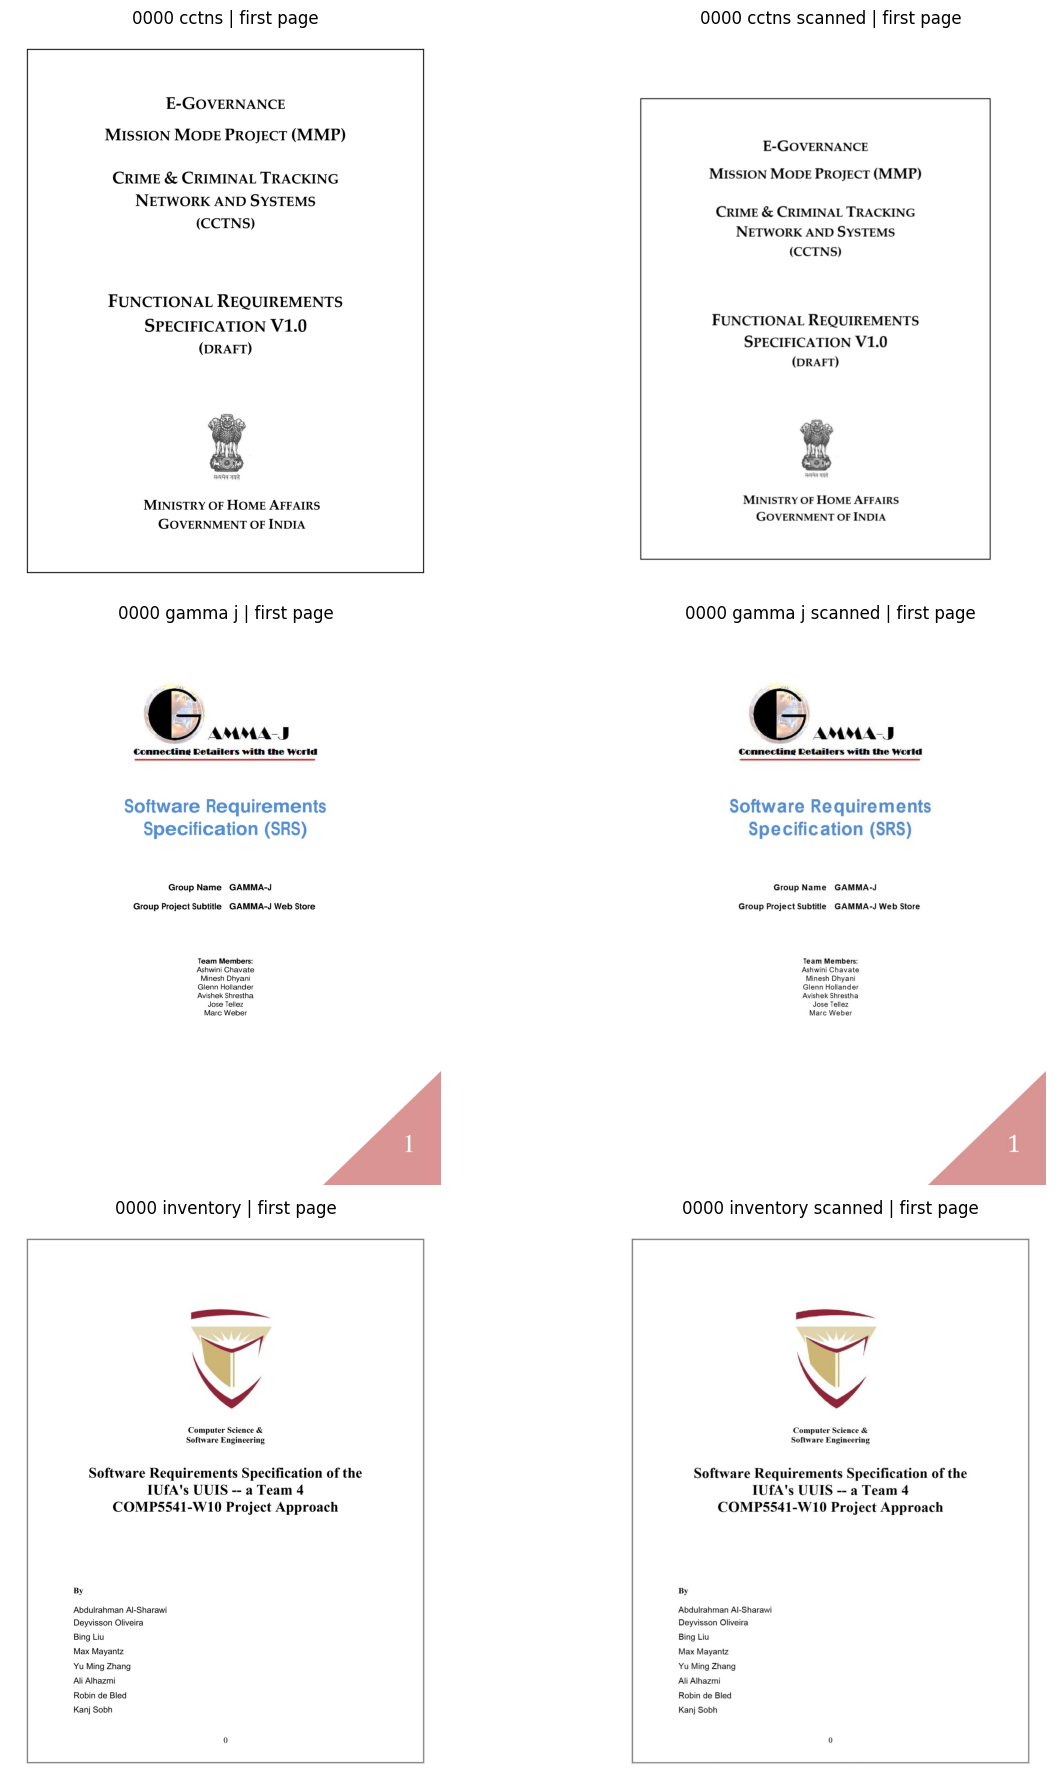

In [27]:
# =========================================================
# MODULE C1.5 — VISUALIZE FIRST PAGES OF DIFFERENT DOCUMENTS
# =========================================================

sample_first_pages = first_pages.head(6)

plt.figure(figsize=(14, 18))

for i, (_, row) in enumerate(sample_first_pages.iterrows(), start=1):
    img = Image.open(row["image_path"])
    
    plt.subplot(3, 2, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f'{row["doc_id"]} | first page')

plt.tight_layout()
plt.show()

# =========================================================
# C2 — PAGE TEXT ALIGNMENT
# =========================================================

In [28]:
# =========================================================
# MODULE C2.0 — GLOBAL OCR FALLBACK FUNCTIONS WITH EASYOCR
# =========================================================

!pip install -q pymupdf pillow easyocr

import fitz
import pandas as pd
import numpy as np
import easyocr
import torch
from PIL import Image
from io import BytesIO

# EasyOCR reader
EASYOCR_GPU = torch.cuda.is_available()

easyocr_reader = easyocr.Reader(
    ["en"],
    gpu=EASYOCR_GPU
)

print("EasyOCR ready.")
print("GPU used:", EASYOCR_GPU)


def easyocr_image(img):
    """
    OCR a PIL image using EasyOCR.
    """
    try:
        img_np = np.array(img)
        results = easyocr_reader.readtext(
            img_np,
            detail=0,
            paragraph=True
        )
        text = "\n".join(results)
        return text if text else ""
    except Exception as e:
        print("EasyOCR image error:", e)
        return ""


def easyocr_pdf_page_with_fitz(page, zoom=2.0):
    """
    Render one PDF page as image with PyMuPDF,
    then OCR it with EasyOCR.
    """
    mat = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img = Image.open(BytesIO(pix.tobytes("png"))).convert("RGB")

    return easyocr_image(img)


def extract_pdf_text_with_ocr_fallback(
    pdf_path,
    force_ocr=False,
    min_avg_chars=100,
    empty_ratio_threshold=0.70
):
    """
    First tries embedded PDF text using PyMuPDF.
    If the PDF looks scanned/image-only, it uses EasyOCR page by page.
    """
    pdf_doc = fitz.open(str(pdf_path))

    text_rows = []

    # First pass: native PDF text
    for page_idx in range(len(pdf_doc)):
        page = pdf_doc[page_idx]
        text = page.get_text("text") or ""

        text_rows.append({
            "page_num": page_idx + 1,
            "page_text": text,
            "char_count": len(text),
            "word_count": len(text.split()) if text else 0,
            "source_type": "pdf_text",
            "ocr_used": False
        })

    df_temp = pd.DataFrame(text_rows)

    avg_chars_per_page = df_temp["char_count"].mean() if len(df_temp) else 0
    empty_page_ratio = (df_temp["char_count"] < 30).mean() if len(df_temp) else 1

    needs_ocr = (
        force_ocr
        or avg_chars_per_page < min_avg_chars
        or empty_page_ratio > empty_ratio_threshold
        or "scanned" in str(pdf_path).lower()
    )

    print(
        f"{Path(str(pdf_path)).name} | "
        f"avg_chars={avg_chars_per_page:.1f} | "
        f"empty_ratio={empty_page_ratio:.2f} | "
        f"EasyOCR={needs_ocr}"
    )

    # OCR fallback with EasyOCR
    if needs_ocr:
        ocr_rows = []

        for page_idx in range(len(pdf_doc)):
            page = pdf_doc[page_idx]
            text = easyocr_pdf_page_with_fitz(page, zoom=2.0)

            ocr_rows.append({
                "page_num": page_idx + 1,
                "page_text": text,
                "char_count": len(text),
                "word_count": len(text.split()) if text else 0,
                "source_type": "easyocr_pdf",
                "ocr_used": True
            })

        df_temp = pd.DataFrame(ocr_rows)

    pdf_doc.close()
    return df_temp

EasyOCR ready.
GPU used: True


In [29]:
# =========================================================
# MODULE C2.1 — EXTRACT PAGE TEXT FROM ALL PDF DOCUMENTS WITH OCR FALLBACK
# =========================================================

page_text_rows = []

for _, row in df_pdfs.iterrows():
    pdf_path = row["file_path"]
    doc_id = row["doc_id"]
    pdf_file_name = row["file_name"]

    try:
        df_doc_pages = extract_pdf_text_with_ocr_fallback(pdf_path)

        df_doc_pages["doc_id"] = doc_id
        df_doc_pages["pdf_file_name"] = pdf_file_name
        df_doc_pages["pdf_path"] = pdf_path

        page_text_rows.append(df_doc_pages)

        print(
            f"Processed: {pdf_file_name} | pages={len(df_doc_pages)} | "
            f"source={df_doc_pages['source_type'].value_counts().to_dict()}"
        )

    except Exception as e:
        print(f"Error reading {pdf_file_name}: {e}")

if len(page_text_rows) > 0:
    df_pages_text = pd.concat(page_text_rows, ignore_index=True)
else:
    df_pages_text = pd.DataFrame(columns=[
        "doc_id", "page_num", "pdf_file_name", "pdf_path",
        "page_text", "char_count", "word_count", "source_type", "ocr_used"
    ])

print("Pages text dataset shape:", df_pages_text.shape)
print(df_pages_text["source_type"].value_counts(dropna=False))
display(df_pages_text.head(20))

2010 - mashboot.pdf | avg_chars=1454.9 | empty_ratio=0.00 | EasyOCR=False
Processed: 2010 - mashboot.pdf | pages=15 | source={'pdf_text': 15}
2008 - peering - scanned.pdf | avg_chars=0.0 | empty_ratio=1.00 | EasyOCR=True
Processed: 2008 - peering - scanned.pdf | pages=17 | source={'easyocr_pdf': 17}
2002 - sce api.pdf | avg_chars=2175.0 | empty_ratio=0.00 | EasyOCR=False
Processed: 2002 - sce api.pdf | pages=94 | source={'pdf_text': 94}
1999 - tcs - scanned.pdf | avg_chars=0.0 | empty_ratio=1.00 | EasyOCR=True
Processed: 1999 - tcs - scanned.pdf | pages=148 | source={'easyocr_pdf': 148}
2008 - vub.pdf | avg_chars=1248.6 | empty_ratio=0.07 | EasyOCR=False
Processed: 2008 - vub.pdf | pages=40 | source={'pdf_text': 40}
0000 - inventory - scanned.pdf | avg_chars=0.0 | empty_ratio=1.00 | EasyOCR=True
Processed: 0000 - inventory - scanned.pdf | pages=31 | source={'easyocr_pdf': 31}
2004 - watcom gui.pdf | avg_chars=1417.3 | empty_ratio=0.00 | EasyOCR=False
Processed: 2004 - watcom gui.pdf | 

,page_num,page_text,char_count,word_count,source_type,ocr_used,doc_id,pdf_file_name,pdf_path
0,1,Software Requirements Speciﬁcation for Mashbot...,130,19,pdf_text,False,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...
1,2,Revision History\nName\nDate\nReason for Chang...,269,42,pdf_text,False,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...
2,3,Contents\n1\nIntroduction\n3\n1.1\nPurpose . ....,2777,1141,pdf_text,False,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...
3,4,1\nIntroduction\n1.1\nPurpose\nThis document i...,3234,480,pdf_text,False,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...
4,5,comes from providing such a service. Furthermo...,3051,488,pdf_text,False,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...
5,6,2.1.4\nSoftware Interfaces\nThe Mashbot softwa...,1664,252,pdf_text,False,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...
6,7,2.4\nRequirements Apportioning\nPriority\nDesc...,2090,335,pdf_text,False,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...
7,8,0230 Publishers may schedule or immediately in...,1908,314,pdf_text,False,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...
8,9,0530 A schedule is a mapping of times to publi...,2043,334,pdf_text,False,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...
9,10,4.1\nDashboard\nThe dashboard consists of grap...,1990,354,pdf_text,False,2010 mashboot,2010 - mashboot.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...


In [30]:
# =========================================================
# MODULE C2.2 — CHECK PAGE TEXT EXTRACTION QUALITY
# =========================================================

print("Total extracted pages:", len(df_pages_text))
print("\nPages with empty text:", (df_pages_text["char_count"] == 0).sum())
print("\nAverage chars per page:", round(df_pages_text["char_count"].mean(), 2))
print("\nAverage words per page:", round(df_pages_text["word_count"].mean(), 2))

display(df_pages_text[["doc_id", "page_num", "char_count", "word_count"]].head(20))

Total extracted pages: 5666

Pages with empty text: 42

Average chars per page: 1625.33

Average words per page: 234.39


,doc_id,page_num,char_count,word_count
0,2010 mashboot,1,130,19
1,2010 mashboot,2,269,42
2,2010 mashboot,3,2777,1141
3,2010 mashboot,4,3234,480
4,2010 mashboot,5,3051,488
5,2010 mashboot,6,1664,252
6,2010 mashboot,7,2090,335
7,2010 mashboot,8,1908,314
8,2010 mashboot,9,2043,334
9,2010 mashboot,10,1990,354


In [31]:
# =========================================================
# MODULE C2.3 — BUILD PAGE-LEVEL ALIGNED DATASET
# =========================================================

df_pages_aligned = pd.merge(
    df_pages_dataset,
    df_pages_text[
        [
            "doc_id",
            "page_num",
            "page_text",
            "char_count",
            "word_count",
            "source_type",
            "ocr_used"
        ]
    ],
    on=["doc_id", "page_num"],
    how="left"
)

df_pages_aligned["page_text"] = df_pages_aligned["page_text"].fillna("")
df_pages_aligned["char_count"] = df_pages_aligned["char_count"].fillna(0).astype(int)
df_pages_aligned["word_count"] = df_pages_aligned["word_count"].fillna(0).astype(int)
df_pages_aligned["source_type"] = df_pages_aligned["source_type"].fillna("missing_text")
df_pages_aligned["ocr_used"] = df_pages_aligned["ocr_used"].fillna(False)

df_pages_aligned = df_pages_aligned.sort_values(
    ["doc_id", "page_num"]
).reset_index(drop=True)

print("Aligned pages dataset shape:", df_pages_aligned.shape)
print(df_pages_aligned["source_type"].value_counts(dropna=False))
display(df_pages_aligned.head(30))



Aligned pages dataset shape: (5666, 15)
source_type
pdf_text       2833
easyocr_pdf    2833
Name: count, dtype: int64


,doc_id,page_num,image_file_name,image_path,pdf_file_name,pdf_path,xml_file_name,xml_path,has_pdf,has_xml,page_text,char_count,word_count,source_type,ocr_used
0,0000 cctns,1,0000 - cctns-01.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0,E-GOVERNANCE \nMISSION MODE PROJECT (MMP) \n...,234,25,pdf_text,False
1,0000 cctns,2,0000 - cctns-02.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0,E-Governance Mission Mode Project: Crime & Cri...,587,67,pdf_text,False
2,0000 cctns,3,0000 - cctns-03.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0,E-Governance Mission Mode Project: Crime & Cri...,1028,142,pdf_text,False
3,0000 cctns,4,0000 - cctns-04.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0,E-Governance Mission Mode Project: Crime & Cri...,2006,286,pdf_text,False
4,0000 cctns,5,0000 - cctns-05.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0,E-Governance Mission Mode Project: Crime & Cri...,1450,205,pdf_text,False
5,0000 cctns,6,0000 - cctns-06.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0,E-Governance Mission Mode Project: Crime & Cri...,2016,299,pdf_text,False
6,0000 cctns,7,0000 - cctns-07.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0,E-Governance Mission Mode Project: Crime & Cri...,2220,350,pdf_text,False
7,0000 cctns,8,0000 - cctns-08.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0,E-Governance Mission Mode Project: Crime & Cri...,2391,401,pdf_text,False
8,0000 cctns,9,0000 - cctns-09.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0,E-Governance Mission Mode Project: Crime & Cri...,2190,320,pdf_text,False
9,0000 cctns,10,0000 - cctns-10.png,/kaggle/input/datasets/yomnaahelali/page-image...,0000 - cctns.pdf,/kaggle/input/datasets/yomnaahelali/raw-docume...,NaN,NaN,1,0,E-Governance Mission Mode Project: Crime & Cri...,3073,452,pdf_text,False


In [147]:
# =========================================================
# MODULE C2.3B — EASYOCR PAGE IMAGES WHEN PAGE TEXT IS MISSING
# =========================================================

def easyocr_image_path(image_path):
    """
    OCR a page image directly using EasyOCR.
    """
    try:
        img = Image.open(image_path).convert("RGB")
        text = easyocr_image(img)
        return text if text else ""
    except Exception as e:
        print(f"EasyOCR image error: {image_path} | {e}")
        return ""


missing_mask = (
    (df_pages_aligned["char_count"] < 30) &
    (df_pages_aligned["image_path"].notna())
)

print("Pages needing EasyOCR image OCR:", missing_mask.sum())

for idx in df_pages_aligned[missing_mask].index:
    img_path = df_pages_aligned.loc[idx, "image_path"]
    text = easyocr_image_path(img_path)

    df_pages_aligned.loc[idx, "page_text"] = text
    df_pages_aligned.loc[idx, "char_count"] = len(text)
    df_pages_aligned.loc[idx, "word_count"] = len(text.split()) if text else 0
    df_pages_aligned.loc[idx, "source_type"] = "easyocr_page_image"
    df_pages_aligned.loc[idx, "ocr_used"] = True

print("After EasyOCR image OCR:")
print(df_pages_aligned["source_type"].value_counts(dropna=False))

display(
    df_pages_aligned[
        ["doc_id", "page_num", "char_count", "word_count", "source_type", "ocr_used"]
    ].head(30)
)

Pages needing EasyOCR image OCR: 53
After EasyOCR image OCR:
source_type
pdf_text              2805
easyocr_pdf           2805
easyocr_page_image      56
Name: count, dtype: int64


,doc_id,page_num,char_count,word_count,source_type,ocr_used
0,0000 cctns,1,234,25,pdf_text,False
1,0000 cctns,2,587,67,pdf_text,False
2,0000 cctns,3,1028,142,pdf_text,False
3,0000 cctns,4,2006,286,pdf_text,False
4,0000 cctns,5,1450,205,pdf_text,False
5,0000 cctns,6,2016,299,pdf_text,False
6,0000 cctns,7,2220,350,pdf_text,False
7,0000 cctns,8,2391,401,pdf_text,False
8,0000 cctns,9,2190,320,pdf_text,False
9,0000 cctns,10,3073,452,pdf_text,False


In [148]:
# vérifie que EasyOCR fonctionne
print(df_pages_aligned["source_type"].value_counts())
print(df_pages_aligned["ocr_used"].value_counts())

display(
    df_pages_aligned[
        df_pages_aligned["doc_id"].str.contains("scanned", na=False)
    ][
        [
            "doc_id",
            "page_num",
            "char_count",
            "word_count",
            "source_type",
            "ocr_used",
            "page_text"
        ]
    ].head(20)
)

source_type
pdf_text              2805
easyocr_pdf           2805
easyocr_page_image      56
Name: count, dtype: int64
ocr_used
True     2861
False    2805
Name: count, dtype: int64


,doc_id,page_num,char_count,word_count,source_type,ocr_used,page_text
19,0000 cctns scanned,1,198,27,easyocr_pdf,True,E-GOVERNANCE\nMISSION MODE PROJECT (MMP)\nCRIM...
20,0000 cctns scanned,2,466,61,easyocr_pdf,True,E-Governance Mission Mode Project: Crime & Cri...
21,0000 cctns scanned,3,1229,179,easyocr_pdf,True,E-Governance Mission Mode Project: Crime & Cri...
22,0000 cctns scanned,4,1882,280,easyocr_pdf,True,E-Governance Mission Mode Project: Crime & Cri...
23,0000 cctns scanned,5,1329,205,easyocr_pdf,True,E-Governance Mission Mode Project: Crime & Cri...
24,0000 cctns scanned,6,1856,294,easyocr_pdf,True,E-Governance Mission Mode Project: Crime & Cri...
25,0000 cctns scanned,7,2044,333,easyocr_pdf,True,E-Governance Mission Mode Project: Crime & Cri...
26,0000 cctns scanned,8,2218,384,easyocr_pdf,True,E-Governance Mission Mode Project: Crime & Cri...
27,0000 cctns scanned,9,2054,302,easyocr_pdf,True,E-Governance Mission Mode Project: Crime & Cri...
28,0000 cctns scanned,10,2889,429,easyocr_pdf,True,E-Governance Mission Mode Project: Crime & Cri...


In [149]:
# =========================================================
# MODULE C2.4 — PREVIEW PAGE TEXT WITH DOCUMENT IDS
# =========================================================

preview_cols = ["doc_id", "page_num", "image_file_name", "char_count", "word_count", "page_text"]
display(df_pages_aligned[preview_cols].head(10))

,doc_id,page_num,image_file_name,char_count,word_count,page_text
0,0000 cctns,1,0000 - cctns-01.png,234,25,E-GOVERNANCE \nMISSION MODE PROJECT (MMP) \n...
1,0000 cctns,2,0000 - cctns-02.png,587,67,E-Governance Mission Mode Project: Crime & Cri...
2,0000 cctns,3,0000 - cctns-03.png,1028,142,E-Governance Mission Mode Project: Crime & Cri...
3,0000 cctns,4,0000 - cctns-04.png,2006,286,E-Governance Mission Mode Project: Crime & Cri...
4,0000 cctns,5,0000 - cctns-05.png,1450,205,E-Governance Mission Mode Project: Crime & Cri...
5,0000 cctns,6,0000 - cctns-06.png,2016,299,E-Governance Mission Mode Project: Crime & Cri...
6,0000 cctns,7,0000 - cctns-07.png,2220,350,E-Governance Mission Mode Project: Crime & Cri...
7,0000 cctns,8,0000 - cctns-08.png,2391,401,E-Governance Mission Mode Project: Crime & Cri...
8,0000 cctns,9,0000 - cctns-09.png,2190,320,E-Governance Mission Mode Project: Crime & Cri...
9,0000 cctns,10,0000 - cctns-10.png,3073,452,E-Governance Mission Mode Project: Crime & Cri...


In [150]:
# =========================================================
# MODULE C2.5 — SAVE PAGE-LEVEL ALIGNED DATASET
# =========================================================

pages_aligned_path = "/kaggle/working/pages_aligned_dataset.csv"
df_pages_aligned.to_csv(pages_aligned_path, index=False)

print("Saved:", pages_aligned_path)

Saved: /kaggle/working/pages_aligned_dataset.csv


In [151]:
# =========================================================
# MODULE C2.6 — GLOBAL BLOCK EXTRACTION FROM ALIGNED PAGES
# =========================================================

block_rows = []

for _, row in df_pages_aligned.iterrows():
    doc_id = row["doc_id"]
    page_num = row["page_num"]
    page_text = row["page_text"]
    source_type = row["source_type"]
    ocr_used = row["ocr_used"]

    blocks = re.split(r"\n\s*\n+", str(page_text))

    for block_id, block in enumerate(blocks, start=1):
        clean_block = re.sub(r"\s+", " ", str(block)).strip()

        if len(clean_block) < 3:
            continue

        block_rows.append({
            "doc_id": doc_id,
            "page_num": page_num,
            "block_id": block_id,
            "block_text": clean_block,
            "block_char_count": len(clean_block),
            "block_word_count": len(clean_block.split()),
            "source_type": source_type,
            "ocr_used": ocr_used
        })

df_blocks_all = pd.DataFrame(block_rows)

print("Global blocks dataset shape:", df_blocks_all.shape)
print(df_blocks_all["source_type"].value_counts(dropna=False))
display(df_blocks_all.head(50))

df_blocks_all.to_csv("/kaggle/working/c2_global_blocks_dataset.csv", index=False)
print("Saved: /kaggle/working/c2_global_blocks_dataset.csv")

Global blocks dataset shape: (16852, 8)
source_type
pdf_text              14034
easyocr_pdf            2808
easyocr_page_image       10
Name: count, dtype: int64


,doc_id,page_num,block_id,block_text,block_char_count,block_word_count,source_type,ocr_used
0,0000 cctns,1,1,E-GOVERNANCE MISSION MODE PROJECT (MMP),39,5,pdf_text,False
1,0000 cctns,1,2,CRIME & CRIMINAL TRACKING NETWORK AND SYSTEMS ...,53,8,pdf_text,False
2,0000 cctns,1,3,FUNCTIONAL REQUIREMENTS SPECIFICATION V1.0 (DR...,50,5,pdf_text,False
3,0000 cctns,1,4,MINISTRY OF HOME AFFAIRS GOVERNMENT OF INDIA,44,7,pdf_text,False
4,0000 cctns,2,1,E-Governance Mission Mode Project: Crime & Cri...,145,23,pdf_text,False
5,0000 cctns,2,2,TABLE OF CONTENTS,17,3,pdf_text,False
6,0000 cctns,2,3,S. NO. CONTENTS 1. INTRODUCTION 2. FUNCTIONAL ...,317,41,pdf_text,False
7,0000 cctns,3,1,E-Governance Mission Mode Project: Crime & Cri...,145,23,pdf_text,False
8,0000 cctns,3,2,1. INTRODUCTION,15,2,pdf_text,False
9,0000 cctns,3,3,The Functional Requirements Specifications (FR...,442,68,pdf_text,False


Saved: /kaggle/working/c2_global_blocks_dataset.csv


# =========================================================
# MODULE C3 — DOCUMENT STRUCTURE INTELLIGENCE
# =========================================================

In [152]:
import re
import pandas as pd

In [153]:
# =========================================================
# C3.1 — CANONICAL SRS TEMPLATE
# =========================================================

canonical_srs_rows = [
    {"order_id": 1, "section": "introduction"},
    {"order_id": 2, "section": "general_description"},
    {"order_id": 3, "section": "functional_requirements"},
    {"order_id": 4, "section": "interface_requirements"},
    {"order_id": 5, "section": "performance_requirements"},
    {"order_id": 6, "section": "design_constraints"},
    {"order_id": 7, "section": "non_functional_requirements"},
    {"order_id": 8, "section": "risks"},
    {"order_id": 9, "section": "acceptance_criteria"},
    {"order_id": 10, "section": "appendices"}
]

df_canonical_srs = pd.DataFrame(canonical_srs_rows)

print("Canonical SRS dataset shape:", df_canonical_srs.shape)
display(df_canonical_srs)


Canonical SRS dataset shape: (10, 2)


,order_id,section
0,1,introduction
1,2,general_description
2,3,functional_requirements
3,4,interface_requirements
4,5,performance_requirements
5,6,design_constraints
6,7,non_functional_requirements
7,8,risks
8,9,acceptance_criteria
9,10,appendices


In [154]:
# =========================================================
# C3.2 — SECTION PATTERN DATASET
# =========================================================

section_pattern_rows = [
    # introduction
    {"section": "introduction", "pattern": "introduction", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "introduction", "pattern": "purpose", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "introduction", "pattern": "scope", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "introduction", "pattern": "overview", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    # general description
    {"section": "general_description", "pattern": "general description", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "general_description", "pattern": "product perspective", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "general_description", "pattern": "product functions", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "general_description", "pattern": "user classes", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "general_description", "pattern": "operating environment", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "general_description", "pattern": "user characteristics", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    # functional requirements
    {"section": "functional_requirements", "pattern": "functional requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "functional_requirements", "pattern": "system features", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "functional_requirements", "pattern": "functionalities", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "functional_requirements", "pattern": "functional overview", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "functional_requirements", "pattern": "description of modules and functional requirements", "pattern_type": "heading_keyword", "weight": 3, "source": "manual_template"},

    # interface requirements
    {"section": "interface_requirements", "pattern": "interface requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "external interfaces", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "user interface", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "software interfaces", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "hardware interfaces", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "api interface", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    # performance requirements
    {"section": "performance_requirements", "pattern": "performance requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "performance_requirements", "pattern": "response time", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "performance_requirements", "pattern": "latency", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "performance_requirements", "pattern": "throughput", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "performance_requirements", "pattern": "scalability", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    # design constraints
    {"section": "design_constraints", "pattern": "design constraints", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "design_constraints", "pattern": "constraints", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "design_constraints", "pattern": "technical constraints", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "design_constraints", "pattern": "technical limitations", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "design_constraints", "pattern": "standards compliance", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    # non functional requirements
    {"section": "non_functional_requirements", "pattern": "non-functional requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "non functional requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "quality attributes", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "security", "pattern_type": "heading_keyword", "weight": 1, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "usability", "pattern_type": "heading_keyword", "weight": 1, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "reliability", "pattern_type": "heading_keyword", "weight": 1, "source": "manual_template"},

    # risks
    {"section": "risks", "pattern": "risks", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "risks", "pattern": "risk analysis", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "risks", "pattern": "project risks", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "risks", "pattern": "assumptions and dependencies", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    # acceptance criteria
    {"section": "acceptance_criteria", "pattern": "acceptance criteria", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "acceptance_criteria", "pattern": "validation criteria", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "acceptance_criteria", "pattern": "success criteria", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "acceptance_criteria", "pattern": "definition of done", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    # appendices
    {"section": "appendices", "pattern": "appendix", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "appendices", "pattern": "appendices", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "appendices", "pattern": "glossary", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "appendices", "pattern": "references", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    # other / structural pages
    {"section": "other", "pattern": "table of contents", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "other", "pattern": "revision history", "pattern_type": "heading", "weight": 2, "source": "manual_template"},
    {"section": "other", "pattern": "document control", "pattern_type": "heading", "weight": 2, "source": "manual_template"}
]

df_section_patterns = pd.DataFrame(section_pattern_rows)

print("Section pattern dataset shape:", df_section_patterns.shape)
display(df_section_patterns.head(20))

Section pattern dataset shape: (52, 5)


,section,pattern,pattern_type,weight,source
0,introduction,introduction,heading,3,manual_template
1,introduction,purpose,heading_keyword,2,manual_template
2,introduction,scope,heading_keyword,2,manual_template
3,introduction,overview,heading_keyword,2,manual_template
4,general_description,general description,heading,3,manual_template
5,general_description,product perspective,heading_keyword,2,manual_template
6,general_description,product functions,heading_keyword,2,manual_template
7,general_description,user classes,heading_keyword,2,manual_template
8,general_description,operating environment,heading_keyword,2,manual_template
9,general_description,user characteristics,heading_keyword,2,manual_template


In [155]:
# =========================================================
# C3.3 — NORMALIZE HEADING TEXT
# =========================================================

def normalize_heading_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"^\d+(\.\d+)*\.?\s*", "", text)
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print(normalize_heading_text("3.2 Functional Requirements"))
print(normalize_heading_text("1. Introduction and Scope"))



functional requirements
introduction and scope


In [156]:
# =========================================================
# C3.4 — EXTRACT HEADING CANDIDATES FROM REAL PAGE TEXT (IMPROVED)
# =========================================================

def extract_heading_candidates_from_page_text(page_text):
    lines = str(page_text).split("\n")
    candidates = []

    sentence_like_starts = (
        "the ", "this ", "these ", "those ", "it ", "they ",
        "he ", "she ", "we ", "you ", "i "
    )

    for line in lines:
        line_clean = re.sub(r"\s+", " ", line).strip()
        if len(line_clean) < 3:
            continue

        line_norm = normalize_heading_text(line_clean)
        word_count = len(line_clean.split())
        char_count = len(line_clean)

        starts_with_section_num = bool(re.match(r"^\d+(\.\d+)*\.?\s+[A-Za-z]", line_clean))
        all_caps = line_clean.isupper()

        has_section_keywords = any(k in line_clean.lower() for k in [
            "introduction",
            "general description",
            "functional requirements",
            "non functional requirements",
            "non-functional requirements",
            "interface requirements",
            "performance requirements",
            "constraints",
            "design constraints",
            "risks",
            "acceptance criteria",
            "appendix",
            "appendices",
            "table of contents",
            "overview",
            "scope",
            "references",
            "glossary",
            "external interfaces",
            "user interface",
            "product perspective",
            "user classes",
            "operating environment",
            "response time",
            "scalability"
        ])

        # ---------- HARD NEGATIVE RULES ----------
        # obvious sentence-like lines
        if line_norm.startswith(sentence_like_starts):
            continue

        # long lines are usually paragraph text, not headings
        if word_count > 10 or char_count > 90:
            continue

        # full sentence punctuation
        if line_clean.endswith(".") or line_clean.endswith(";") or line_clean.endswith(":"):
            continue

        # verbs that often indicate sentence text rather than headings
        if any(v in line_norm for v in [
            " should ", " shall ", " must ", " may ", " can ",
            " is ", " are ", " be ", " have ", " has "
        ]):
            # keep only if it is clearly numbered heading
            if not starts_with_section_num:
                continue

        # ---------- POSITIVE RULES ----------
        if starts_with_section_num or all_caps or has_section_keywords:
            candidates.append(line_clean)

    return candidates


df_pages_aligned["heading_candidates"] = df_pages_aligned["page_text"].apply(
    extract_heading_candidates_from_page_text
)

display(df_pages_aligned[["doc_id", "page_num", "heading_candidates"]].head(10))

,doc_id,page_num,heading_candidates
0,0000 cctns,1,"[E-GOVERNANCE, MISSION MODE PROJECT (MMP), CRI..."
1,0000 cctns,2,"[TABLE OF CONTENTS, CONTENTS, INTRODUCTION, FU..."
2,0000 cctns,3,"[1. INTRODUCTION, 2. FUNCTIONAL OVERVIEW]"
3,0000 cctns,4,[3. DESCRIPTION OF THE MODULES AND FUNCTIONAL ...
4,0000 cctns,5,[]
5,0000 cctns,6,[4. NON-FUNCTIONAL REQUIREMENTS]
6,0000 cctns,7,[]
7,0000 cctns,8,[]
8,0000 cctns,9,[accessibility. Application user interfaces to...
9,0000 cctns,10,[]


In [157]:
# =========================================================
# C3.5 — FLATTEN PAGE HEADING CANDIDATES
# =========================================================

heading_candidate_rows = []

for _, row in df_pages_aligned.iterrows():
    for heading in row["heading_candidates"]:
        heading_candidate_rows.append({
            "doc_id": row["doc_id"],
            "page_num": row["page_num"],
            "heading_text": heading,
            "heading_norm": normalize_heading_text(heading)
        })

df_heading_candidates = pd.DataFrame(heading_candidate_rows)

print("Heading candidates shape:", df_heading_candidates.shape)
display(df_heading_candidates.head(30))


Heading candidates shape: (22222, 4)


,doc_id,page_num,heading_text,heading_norm
0,0000 cctns,1,E-GOVERNANCE,e-governance
1,0000 cctns,1,MISSION MODE PROJECT (MMP),mission mode project mmp
2,0000 cctns,1,CRIME & CRIMINAL TRACKING,crime criminal tracking
3,0000 cctns,1,NETWORK AND SYSTEMS,network and systems
4,0000 cctns,1,(CCTNS),cctns
5,0000 cctns,1,FUNCTIONAL REQUIREMENTS,functional requirements
6,0000 cctns,1,SPECIFICATION V1.0,specification v1 0
7,0000 cctns,1,(DRAFT),draft
8,0000 cctns,1,MINISTRY OF HOME AFFAIRS,ministry of home affairs
9,0000 cctns,1,GOVERNMENT OF INDIA,government of india


In [158]:
# =========================================================
# C3.6 — SECTION DETECTION FROM HEADING USING PATTERN DATASET
# =========================================================

def detect_section_from_heading_dataset(heading, pattern_df):
    heading_norm = normalize_heading_text(heading)

    matched = pattern_df[
        pattern_df["pattern"].apply(lambda p: normalize_heading_text(p) in heading_norm)
    ].copy()

    if matched.empty:
        return {
            "raw_heading": heading,
            "normalized_heading": heading_norm,
            "predicted_section": "unknown",
            "matched_patterns": [],
            "total_weight": 0
        }

    section_scores = matched.groupby("section")["weight"].sum().sort_values(ascending=False)
    best_section = section_scores.index[0]

    return {
        "raw_heading": heading,
        "normalized_heading": heading_norm,
        "predicted_section": best_section,
        "matched_patterns": matched["pattern"].tolist(),
        "total_weight": int(section_scores.iloc[0])
    }

heading_results = [
    detect_section_from_heading_dataset(h, df_section_patterns)
    for h in df_heading_candidates["heading_text"].tolist()
]

df_heading_detected = pd.DataFrame(heading_results)
df_heading_candidates = pd.concat(
    [df_heading_candidates.reset_index(drop=True), df_heading_detected[["predicted_section", "matched_patterns", "total_weight"]]],
    axis=1
)

display(df_heading_candidates.head(30))

,doc_id,page_num,heading_text,heading_norm,predicted_section,matched_patterns,total_weight
0,0000 cctns,1,E-GOVERNANCE,e-governance,unknown,[],0
1,0000 cctns,1,MISSION MODE PROJECT (MMP),mission mode project mmp,unknown,[],0
2,0000 cctns,1,CRIME & CRIMINAL TRACKING,crime criminal tracking,unknown,[],0
3,0000 cctns,1,NETWORK AND SYSTEMS,network and systems,unknown,[],0
4,0000 cctns,1,(CCTNS),cctns,unknown,[],0
5,0000 cctns,1,FUNCTIONAL REQUIREMENTS,functional requirements,functional_requirements,[functional requirements],3
6,0000 cctns,1,SPECIFICATION V1.0,specification v1 0,unknown,[],0
7,0000 cctns,1,(DRAFT),draft,unknown,[],0
8,0000 cctns,1,MINISTRY OF HOME AFFAIRS,ministry of home affairs,unknown,[],0
9,0000 cctns,1,GOVERNMENT OF INDIA,government of india,unknown,[],0


In [159]:
# =========================================================
# C3.7 — CLEAN HEADING CANDIDATES
# =========================================================

def is_noisy_heading_candidate(heading_text):
    h = str(heading_text).strip()
    h_norm = normalize_heading_text(h)

    if len(h_norm) < 3:
        return True

    word_count = len(h_norm.split())

    if h_norm in {"draft", "contents", "s no", "sno"}:
        return True

    if re.fullmatch(r"[a-z]?\d+(\.\d+)*", h_norm):
        return True

    noisy_phrases = [
        "ministry of home affairs",
        "government of india",
        "draft core scope document",
        "mission mode project",
        "crime criminal tracking",
        "network and systems",
        "specification v1 0",
        "functional requirements specification",
        "e governance",
        "mmp",
        "cctns"
    ]

    if any(p in h_norm for p in noisy_phrases):
        return True

    module_like_words = {
        "registration", "investigation", "prosecution", "search",
        "navigation module", "configuration module",
        "citizen interface module"
    }
    if h_norm in module_like_words:
        return True

    allowed_short_keywords = {
        "introduction", "overview", "scope", "risks", "appendix",
        "appendices", "references", "glossary"
    }

    if word_count == 1 and h_norm not in allowed_short_keywords:
        if not any(normalize_heading_text(p) == h_norm for p in df_section_patterns["pattern"].tolist()):
            return True

    return False

df_heading_candidates["is_noisy_heading"] = df_heading_candidates["heading_text"].apply(is_noisy_heading_candidate)

print("Noisy heading candidates:", df_heading_candidates["is_noisy_heading"].sum())
print("Clean heading candidates:", (~df_heading_candidates["is_noisy_heading"]).sum())

display(df_heading_candidates[
    ["doc_id", "page_num", "heading_text", "heading_norm", "predicted_section", "is_noisy_heading"]
].head(40))

Noisy heading candidates: 9802
Clean heading candidates: 12420


,doc_id,page_num,heading_text,heading_norm,predicted_section,is_noisy_heading
0,0000 cctns,1,E-GOVERNANCE,e-governance,unknown,True
1,0000 cctns,1,MISSION MODE PROJECT (MMP),mission mode project mmp,unknown,True
2,0000 cctns,1,CRIME & CRIMINAL TRACKING,crime criminal tracking,unknown,True
3,0000 cctns,1,NETWORK AND SYSTEMS,network and systems,unknown,True
4,0000 cctns,1,(CCTNS),cctns,unknown,True
5,0000 cctns,1,FUNCTIONAL REQUIREMENTS,functional requirements,functional_requirements,False
6,0000 cctns,1,SPECIFICATION V1.0,specification v1 0,unknown,True
7,0000 cctns,1,(DRAFT),draft,unknown,True
8,0000 cctns,1,MINISTRY OF HOME AFFAIRS,ministry of home affairs,unknown,True
9,0000 cctns,1,GOVERNMENT OF INDIA,government of india,unknown,True


In [160]:
# =========================================================
# C3.8 — KEEP ONLY CLEAN HEADINGS
# =========================================================

df_heading_candidates_clean = df_heading_candidates[
    df_heading_candidates["is_noisy_heading"] == False
].copy()

print("Clean heading candidates shape:", df_heading_candidates_clean.shape)
display(df_heading_candidates_clean.head(40))

Clean heading candidates shape: (12420, 8)


,doc_id,page_num,heading_text,heading_norm,predicted_section,matched_patterns,total_weight,is_noisy_heading
5,0000 cctns,1,FUNCTIONAL REQUIREMENTS,functional requirements,functional_requirements,[functional requirements],3,False
10,0000 cctns,2,TABLE OF CONTENTS,table of contents,other,[table of contents],3,False
12,0000 cctns,2,INTRODUCTION,introduction,introduction,[introduction],3,False
13,0000 cctns,2,FUNCTIONAL OVERVIEW,functional overview,functional_requirements,"[overview, functional overview]",2,False
14,0000 cctns,2,DESCRIPTION OF THE MODULES AND FUNCTIONAL REQU...,description of the modules and functional requ...,functional_requirements,[functional requirements],3,False
15,0000 cctns,2,NON-FUNCTIONAL REQUIREMENTS,non-functional requirements,functional_requirements,"[functional requirements, non-functional requi...",3,False
16,0000 cctns,2,FUNCTIONAL ARCHITECTURE RECOMMENDATIONS,functional architecture recommendations,unknown,[],0,False
24,0000 cctns,3,1. INTRODUCTION,introduction,introduction,[introduction],3,False
25,0000 cctns,3,2. FUNCTIONAL OVERVIEW,functional overview,functional_requirements,"[overview, functional overview]",2,False
26,0000 cctns,4,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,description of the modules and functional requ...,functional_requirements,[functional requirements],3,False


In [161]:
# =========================================================
# C3.9 — FIX AMBIGUOUS SECTION LABELS
# =========================================================

def fix_predicted_section(row):
    heading_norm = row["heading_norm"]
    predicted = row["predicted_section"]

    if "non functional requirements" in heading_norm or "non-functional requirements" in heading_norm:
        return "non_functional_requirements"

    if "design constraints" in heading_norm:
        return "design_constraints"

    return predicted

df_heading_candidates_clean["predicted_section_fixed"] = df_heading_candidates_clean.apply(
    fix_predicted_section, axis=1
)

display(df_heading_candidates_clean[
    ["doc_id", "page_num", "heading_text", "predicted_section", "predicted_section_fixed"]
].head(40))

,doc_id,page_num,heading_text,predicted_section,predicted_section_fixed
5,0000 cctns,1,FUNCTIONAL REQUIREMENTS,functional_requirements,functional_requirements
10,0000 cctns,2,TABLE OF CONTENTS,other,other
12,0000 cctns,2,INTRODUCTION,introduction,introduction
13,0000 cctns,2,FUNCTIONAL OVERVIEW,functional_requirements,functional_requirements
14,0000 cctns,2,DESCRIPTION OF THE MODULES AND FUNCTIONAL REQU...,functional_requirements,functional_requirements
15,0000 cctns,2,NON-FUNCTIONAL REQUIREMENTS,functional_requirements,non_functional_requirements
16,0000 cctns,2,FUNCTIONAL ARCHITECTURE RECOMMENDATIONS,unknown,unknown
24,0000 cctns,3,1. INTRODUCTION,introduction,introduction
25,0000 cctns,3,2. FUNCTIONAL OVERVIEW,functional_requirements,functional_requirements
26,0000 cctns,4,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,functional_requirements,functional_requirements


In [162]:
# =========================================================
# C3.10 — BUILD DOCUMENT-LEVEL SECTION INVENTORY FROM CLEAN HEADINGS
# =========================================================

def unique_keep_order(seq):
    seen = set()
    result = []
    for x in seq:
        if x not in seen and x not in ["unknown", "other"]:
            seen.add(x)
            result.append(x)
    return result

df_document_sections_clean = (
    df_heading_candidates_clean
    .groupby("doc_id")["predicted_section_fixed"]
    .apply(lambda x: unique_keep_order(x.tolist()))
    .reset_index(name="detected_sections")
)

display(df_document_sections_clean.head(20))

,doc_id,detected_sections
0,0000 cctns,"[functional_requirements, introduction, non_fu..."
1,0000 cctns scanned,"[functional_requirements, non_functional_requi..."
2,0000 gamma j,"[introduction, appendices, general_description..."
3,0000 gamma j scanned,"[introduction, appendices, risks, functional_r..."
4,0000 inventory,"[introduction, functional_requirements, non_fu..."
5,0000 inventory scanned,[appendices]
6,1995 gemini,"[introduction, appendices, general_description..."
7,1995 gemini scanned,"[introduction, appendices, general_description..."
8,1998 themas,"[introduction, appendices, general_description..."
9,1998 themas scanned,"[introduction, appendices, general_description..."


In [163]:
# =========================================================
# C3.11 — COMPARE DETECTED SECTIONS TO TEMPLATE
# =========================================================

def compare_detected_sections_to_template(detected_sections, canonical_df):
    canonical_sections = canonical_df["section"].tolist()
    detected_clean = [s for s in detected_sections if s != "unknown"]

    present_sections = [s for s in canonical_sections if s in detected_clean]
    missing_sections = [s for s in canonical_sections if s not in detected_clean]
    unexpected_sections = [s for s in detected_clean if s not in canonical_sections]

    return {
        "present_sections": present_sections,
        "missing_sections": missing_sections,
        "unexpected_sections": unexpected_sections
    }


In [164]:

# =========================================================
# C3.12 — COMPUTE ORDER SCORE
# =========================================================

def compute_dataset_order_score(detected_sections, canonical_df):
    canonical_order = {
        row["section"]: row["order_id"]
        for _, row in canonical_df.iterrows()
    }

    detected_clean = [s for s in detected_sections if s in canonical_order]

    if len(detected_clean) <= 1:
        return 1.0

    correct_pairs = 0
    total_pairs = 0

    for i in range(len(detected_clean)):
        for j in range(i + 1, len(detected_clean)):
            total_pairs += 1
            if canonical_order[detected_clean[i]] <= canonical_order[detected_clean[j]]:
                correct_pairs += 1

    if total_pairs == 0:
        return 1.0

    return round(correct_pairs / total_pairs, 3)


In [165]:
# =========================================================
# C3.13 — COMPUTE TEMPLATE COMPLIANCE SCORE
# =========================================================

def compute_dataset_template_compliance(detected_sections, canonical_df):
    compare_result = compare_detected_sections_to_template(detected_sections, canonical_df)

    present_ratio = len(compare_result["present_sections"]) / len(canonical_df)
    order_score = compute_dataset_order_score(detected_sections, canonical_df)

    template_compliance_score = round((0.7 * present_ratio) + (0.3 * order_score), 3)

    recommendations = []
    if len(compare_result["missing_sections"]) > 0:
        recommendations.append("add_missing_sections")
    if order_score < 1.0:
        recommendations.append("reorganize_sections")
    if len(compare_result["unexpected_sections"]) > 0:
        recommendations.append("review_unexpected_sections")

    return {
        "present_sections": compare_result["present_sections"],
        "missing_sections": compare_result["missing_sections"],
        "unexpected_sections": compare_result["unexpected_sections"],
        "order_score": order_score,
        "template_compliance_score": template_compliance_score,
        "recommendations": recommendations
    }




In [166]:
# =========================================================
# C3.14 — BUILD DOCUMENT-LEVEL TEMPLATE COMPLIANCE TABLE
# =========================================================

template_rows_clean = []

for _, row in df_document_sections_clean.iterrows():
    compliance = compute_dataset_template_compliance(row["detected_sections"], df_canonical_srs)

    template_rows_clean.append({
        "doc_id": row["doc_id"],
        "detected_sections": row["detected_sections"],
        "present_sections": compliance["present_sections"],
        "missing_sections": compliance["missing_sections"],
        "unexpected_sections": compliance["unexpected_sections"],
        "order_score": compliance["order_score"],
        "template_compliance_score": compliance["template_compliance_score"],
        "recommendations": compliance["recommendations"]
    })

df_template_compliance_clean = pd.DataFrame(template_rows_clean)

display(df_template_compliance_clean.head(20))




,doc_id,detected_sections,present_sections,missing_sections,unexpected_sections,order_score,template_compliance_score,recommendations
0,0000 cctns,"[functional_requirements, introduction, non_fu...","[introduction, functional_requirements, interf...","[general_description, design_constraints, risk...",[],0.700,0.560,"[add_missing_sections, reorganize_sections]"
1,0000 cctns scanned,"[functional_requirements, non_functional_requi...","[functional_requirements, non_functional_requi...","[introduction, general_description, interface_...",[],1.000,0.440,[add_missing_sections]
2,0000 gamma j,"[introduction, appendices, general_description...","[introduction, general_description, functional...",[acceptance_criteria],[],0.611,0.813,"[add_missing_sections, reorganize_sections]"
3,0000 gamma j scanned,"[introduction, appendices, risks, functional_r...","[introduction, functional_requirements, interf...","[general_description, performance_requirements...",[],0.533,0.580,"[add_missing_sections, reorganize_sections]"
4,0000 inventory,"[introduction, functional_requirements, non_fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],1.000,0.580,[add_missing_sections]
5,0000 inventory scanned,[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.370,[add_missing_sections]
6,1995 gemini,"[introduction, appendices, general_description...","[introduction, general_description, interface_...","[functional_requirements, acceptance_criteria]",[],0.607,0.742,"[add_missing_sections, reorganize_sections]"
7,1995 gemini scanned,"[introduction, appendices, general_description...","[introduction, general_description, interface_...","[functional_requirements, performance_requirem...",[],0.600,0.600,"[add_missing_sections, reorganize_sections]"
8,1998 themas,"[introduction, appendices, general_description...","[introduction, general_description, functional...","[non_functional_requirements, acceptance_crite...",[],0.536,0.721,"[add_missing_sections, reorganize_sections]"
9,1998 themas scanned,"[introduction, appendices, general_description...","[introduction, general_description, design_con...","[functional_requirements, interface_requiremen...",[],0.667,0.480,"[add_missing_sections, reorganize_sections]"


In [167]:
# =========================================================
# C3.15 — REUSABLE FUNCTION FOR A SINGLE DOCUMENT
# =========================================================

def analyze_real_document_template_compliance(doc_id):
    doc_headings = df_heading_candidates_clean[df_heading_candidates_clean["doc_id"] == doc_id].copy()

    if doc_headings.empty:
        return {
            "doc_id": doc_id,
            "heading_table": pd.DataFrame(),
            "compliance_result": None
        }

    detected_sections = unique_keep_order(doc_headings["predicted_section_fixed"].tolist())
    compliance = compute_dataset_template_compliance(detected_sections, df_canonical_srs)

    return {
        "doc_id": doc_id,
        "heading_table": doc_headings,
        "compliance_result": compliance
    }

example_doc_id = df_document_sections_clean["doc_id"].iloc[0]
doc_result = analyze_real_document_template_compliance(example_doc_id)

print("Example document:", doc_result["doc_id"])
display(doc_result["heading_table"].head(20))
print(doc_result["compliance_result"])

Example document: 0000 cctns


,doc_id,page_num,heading_text,heading_norm,predicted_section,matched_patterns,total_weight,is_noisy_heading,predicted_section_fixed
5,0000 cctns,1,FUNCTIONAL REQUIREMENTS,functional requirements,functional_requirements,[functional requirements],3,False,functional_requirements
10,0000 cctns,2,TABLE OF CONTENTS,table of contents,other,[table of contents],3,False,other
12,0000 cctns,2,INTRODUCTION,introduction,introduction,[introduction],3,False,introduction
13,0000 cctns,2,FUNCTIONAL OVERVIEW,functional overview,functional_requirements,"[overview, functional overview]",2,False,functional_requirements
14,0000 cctns,2,DESCRIPTION OF THE MODULES AND FUNCTIONAL REQU...,description of the modules and functional requ...,functional_requirements,[functional requirements],3,False,functional_requirements
15,0000 cctns,2,NON-FUNCTIONAL REQUIREMENTS,non-functional requirements,functional_requirements,"[functional requirements, non-functional requi...",3,False,non_functional_requirements
16,0000 cctns,2,FUNCTIONAL ARCHITECTURE RECOMMENDATIONS,functional architecture recommendations,unknown,[],0,False,unknown
24,0000 cctns,3,1. INTRODUCTION,introduction,introduction,[introduction],3,False,introduction
25,0000 cctns,3,2. FUNCTIONAL OVERVIEW,functional overview,functional_requirements,"[overview, functional overview]",2,False,functional_requirements
26,0000 cctns,4,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,description of the modules and functional requ...,functional_requirements,[functional requirements],3,False,functional_requirements


{'present_sections': ['introduction', 'functional_requirements', 'interface_requirements', 'performance_requirements', 'non_functional_requirements'], 'missing_sections': ['general_description', 'design_constraints', 'risks', 'acceptance_criteria', 'appendices'], 'unexpected_sections': [], 'order_score': 0.7, 'template_compliance_score': 0.56, 'recommendations': ['add_missing_sections', 'reorganize_sections']}


In [168]:
# =========================================================
# C3.16 — PAGE TYPE DETECTION
# =========================================================

def detect_page_type(row):
    page_text = str(row["page_text"])
    page_text_lower = page_text.lower()
    heading_candidates = row["heading_candidates"] if isinstance(row["heading_candidates"], list) else []
    heading_candidates_lower = [str(h).lower() for h in heading_candidates]

    char_count = row["char_count"] if "char_count" in row else len(page_text)

    has_toc_phrase = (
        "table of contents" in page_text_lower
        or "contents" in page_text_lower
    )

    toc_like_count = sum(
        1 for h in heading_candidates_lower
        if any(k in h for k in [
            "introduction", "general description", "functional requirements",
            "non-functional requirements", "interface requirements",
            "performance requirements", "constraints", "risks",
            "acceptance criteria", "appendix", "appendices"
        ])
    )

    cover_keywords = [
        "software requirements specification",
        "functional requirements specification",
        "draft",
        "version",
        "ministry",
        "government",
        "project"
    ]
    cover_keyword_hits = sum(1 for k in cover_keywords if k in page_text_lower)

    appendix_keywords = ["appendix", "appendices", "references", "glossary"]
    appendix_hits = sum(1 for k in appendix_keywords if k in page_text_lower)

    # ---- rules ----

    # TOC page
    if has_toc_phrase or toc_like_count >= 4:
        return "toc_page"

    # Cover page
    if row["page_num"] == 1 and cover_keyword_hits >= 2:
        return "cover_page"

    # Appendix / references page
    if appendix_hits >= 1 and row["page_num"] >= 2:
        return "appendix_page"

    # Very low-text visual page
    if char_count < 120 and len(heading_candidates) <= 2:
        return "low_text_page"

    # Normal content page
    return "content_page"


df_pages_aligned["page_type"] = df_pages_aligned.apply(detect_page_type, axis=1)

print(df_pages_aligned["page_type"].value_counts())
display(df_pages_aligned[[
    "doc_id", "page_num", "page_type", "heading_candidates", "char_count"
]].head(30))

page_type
content_page     4564
appendix_page     559
toc_page          276
low_text_page     192
cover_page         75
Name: count, dtype: int64


,doc_id,page_num,page_type,heading_candidates,char_count
0,0000 cctns,1,cover_page,"[E-GOVERNANCE, MISSION MODE PROJECT (MMP), CRI...",234
1,0000 cctns,2,toc_page,"[TABLE OF CONTENTS, CONTENTS, INTRODUCTION, FU...",587
2,0000 cctns,3,content_page,"[1. INTRODUCTION, 2. FUNCTIONAL OVERVIEW]",1028
3,0000 cctns,4,content_page,[3. DESCRIPTION OF THE MODULES AND FUNCTIONAL ...,2006
4,0000 cctns,5,content_page,[],1450
5,0000 cctns,6,content_page,[4. NON-FUNCTIONAL REQUIREMENTS],2016
6,0000 cctns,7,toc_page,[],2220
7,0000 cctns,8,content_page,[],2391
8,0000 cctns,9,toc_page,[accessibility. Application user interfaces to...,2190
9,0000 cctns,10,content_page,[],3073


In [169]:
# =========================================================
# C3.17 — PAGE TYPE SUMMARY PER DOCUMENT
# =========================================================

df_page_type_summary = (
    df_pages_aligned.groupby(["doc_id", "page_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["doc_id", "count"], ascending=[True, False])
)

display(df_page_type_summary.head(50))

,doc_id,page_type,count
0,0000 cctns,content_page,15
2,0000 cctns,toc_page,3
1,0000 cctns,cover_page,1
3,0000 cctns scanned,content_page,15
5,0000 cctns scanned,toc_page,3
4,0000 cctns scanned,cover_page,1
7,0000 gamma j,content_page,27
8,0000 gamma j,low_text_page,9
6,0000 gamma j,appendix_page,7
9,0000 gamma j,toc_page,1


In [170]:
# =========================================================
# C3.18 — PREVIEW PAGE TYPES
# =========================================================

display(
    df_pages_aligned[[
        "doc_id", "page_num", "page_type", "heading_candidates"
    ]].sort_values(["doc_id", "page_num"]).head(50)
)

,doc_id,page_num,page_type,heading_candidates
0,0000 cctns,1,cover_page,"[E-GOVERNANCE, MISSION MODE PROJECT (MMP), CRI..."
1,0000 cctns,2,toc_page,"[TABLE OF CONTENTS, CONTENTS, INTRODUCTION, FU..."
2,0000 cctns,3,content_page,"[1. INTRODUCTION, 2. FUNCTIONAL OVERVIEW]"
3,0000 cctns,4,content_page,[3. DESCRIPTION OF THE MODULES AND FUNCTIONAL ...
4,0000 cctns,5,content_page,[]
5,0000 cctns,6,content_page,[4. NON-FUNCTIONAL REQUIREMENTS]
6,0000 cctns,7,toc_page,[]
7,0000 cctns,8,content_page,[]
8,0000 cctns,9,toc_page,[accessibility. Application user interfaces to...
9,0000 cctns,10,content_page,[]


In [171]:
# =========================================================
# C3.19 — BUILD HIGH-VALUE HEADING TABLE
# =========================================================

allowed_page_types_for_structure = {"toc_page", "content_page", "appendix_page"}

df_high_value_headings = df_heading_candidates_clean.copy()

# join page_type from df_pages_aligned
df_high_value_headings = df_high_value_headings.merge(
    df_pages_aligned[["doc_id", "page_num", "page_type"]],
    on=["doc_id", "page_num"],
    how="left"
)

# keep only useful page types
df_high_value_headings = df_high_value_headings[
    df_high_value_headings["page_type"].isin(allowed_page_types_for_structure)
].copy()

# remove useless unresolved headings
df_high_value_headings = df_high_value_headings[
    ~(
        (df_high_value_headings["predicted_section_fixed"] == "unknown") &
        (df_high_value_headings["heading_norm"].str.split().str.len() <= 2)
    )
].copy()

# add heading length metadata
df_high_value_headings["heading_word_count"] = (
    df_high_value_headings["heading_text"].astype(str).str.split().str.len()
)

df_high_value_headings["heading_char_count"] = (
    df_high_value_headings["heading_text"].astype(str).str.len()
)

# remove extremely long headings
df_high_value_headings = df_high_value_headings[
    df_high_value_headings["heading_word_count"] <= 14
].copy()

# keep clean ordering
df_high_value_headings = df_high_value_headings.sort_values(
    ["doc_id", "page_num"]
).reset_index(drop=True)

print("High-value headings shape:", df_high_value_headings.shape)
display(df_high_value_headings.head(40))

High-value headings shape: (8104, 12)


,doc_id,page_num,heading_text,heading_norm,predicted_section,matched_patterns,total_weight,is_noisy_heading,predicted_section_fixed,page_type,heading_word_count,heading_char_count
0,0000 cctns,2,TABLE OF CONTENTS,table of contents,other,[table of contents],3,False,other,toc_page,3,17
1,0000 cctns,2,INTRODUCTION,introduction,introduction,[introduction],3,False,introduction,toc_page,1,12
2,0000 cctns,2,FUNCTIONAL OVERVIEW,functional overview,functional_requirements,"[overview, functional overview]",2,False,functional_requirements,toc_page,2,19
3,0000 cctns,2,DESCRIPTION OF THE MODULES AND FUNCTIONAL REQU...,description of the modules and functional requ...,functional_requirements,[functional requirements],3,False,functional_requirements,toc_page,7,54
4,0000 cctns,2,NON-FUNCTIONAL REQUIREMENTS,non-functional requirements,functional_requirements,"[functional requirements, non-functional requi...",3,False,non_functional_requirements,toc_page,2,27
5,0000 cctns,2,FUNCTIONAL ARCHITECTURE RECOMMENDATIONS,functional architecture recommendations,unknown,[],0,False,unknown,toc_page,3,39
6,0000 cctns,3,1. INTRODUCTION,introduction,introduction,[introduction],3,False,introduction,content_page,2,15
7,0000 cctns,3,2. FUNCTIONAL OVERVIEW,functional overview,functional_requirements,"[overview, functional overview]",2,False,functional_requirements,content_page,3,22
8,0000 cctns,4,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,description of the modules and functional requ...,functional_requirements,[functional requirements],3,False,functional_requirements,content_page,8,57
9,0000 cctns,6,4. NON-FUNCTIONAL REQUIREMENTS,non-functional requirements,functional_requirements,"[functional requirements, non-functional requi...",3,False,non_functional_requirements,content_page,3,30


In [172]:
# =========================================================
# C3.20 — PREVIEW HIGH-VALUE HEADINGS BY DOCUMENT
# =========================================================

display(
    df_high_value_headings[
        ["doc_id", "page_num", "page_type", "heading_text", "predicted_section_fixed"]
    ].head(60)
)

,doc_id,page_num,page_type,heading_text,predicted_section_fixed
0,0000 cctns,2,toc_page,TABLE OF CONTENTS,other
1,0000 cctns,2,toc_page,INTRODUCTION,introduction
2,0000 cctns,2,toc_page,FUNCTIONAL OVERVIEW,functional_requirements
3,0000 cctns,2,toc_page,DESCRIPTION OF THE MODULES AND FUNCTIONAL REQU...,functional_requirements
4,0000 cctns,2,toc_page,NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
5,0000 cctns,2,toc_page,FUNCTIONAL ARCHITECTURE RECOMMENDATIONS,unknown
6,0000 cctns,3,content_page,1. INTRODUCTION,introduction
7,0000 cctns,3,content_page,2. FUNCTIONAL OVERVIEW,functional_requirements
8,0000 cctns,4,content_page,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,functional_requirements
9,0000 cctns,6,content_page,4. NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements


In [173]:
# =========================================================
# C3.21 — DOCUMENT-LEVEL HIGH-VALUE STRUCTURE
# =========================================================

df_document_structure = (
    df_high_value_headings
    .groupby("doc_id")
    .agg({
        "heading_text": list,
        "predicted_section_fixed": lambda x: unique_keep_order(
            [v for v in x if v not in ["unknown", "other"]]
        )
    })
    .reset_index()
    .rename(columns={
        "heading_text": "high_value_headings",
        "predicted_section_fixed": "high_value_sections"
    })
)

display(df_document_structure.head(20))

,doc_id,high_value_headings,high_value_sections
0,0000 cctns,"[TABLE OF CONTENTS, INTRODUCTION, FUNCTIONAL O...","[introduction, functional_requirements, non_fu..."
1,0000 cctns scanned,"[TABLE OF CONTENTS, 2. FUNCTIONAL OVERVIEW, No...","[functional_requirements, non_functional_requi..."
2,0000 gamma j,"[Table of Contents, 1. Introduction, 1.1 Purpo...","[introduction, appendices, general_description..."
3,0000 gamma j scanned,"[Table of Contents, 1. Introduction, 1.2 Docum...","[introduction, appendices, risks, functional_r..."
4,0000 inventory,"[Table of Contents, 5.1 Entity relationship Di...","[introduction, functional_requirements, non_fu..."
5,0000 inventory scanned,"[Table of Contents, 5. search permission 5.1. ...",[appendices]
6,1995 gemini,[4. G8MT standards for online software and dev...,"[introduction, appendices, general_description..."
7,1995 gemini scanned,"[Introduction 1-1, 2.9.2 Astronomical data flo...","[introduction, appendices, general_description..."
8,1998 themas,"[D_THEMAS_SRS_001, Table of Contents, 1.0 Intr...","[introduction, appendices, general_description..."
9,1998 themas scanned,"[D THEMAS SRS 001, Table of Contents, 1.0 Intr...","[introduction, appendices, general_description..."


In [174]:
# =========================================================
# C3.22 — KEEP ONLY TOP-LEVEL STRUCTURE HEADINGS
# =========================================================

def is_top_level_heading(row):
    heading = str(row["heading_text"]).strip()
    heading_norm = str(row["heading_norm"]).strip()
    predicted = str(row["predicted_section_fixed"]).strip()

    # reject unresolved
    if predicted in ["unknown", "other"]:
        return False

    # accept canonical section names directly
    strong_section_names = {
        "introduction",
        "general description",
        "functional requirements",
        "non functional requirements",
        "non-functional requirements",
        "interface requirements",
        "performance requirements",
        "design constraints",
        "acceptance criteria",
        "appendix",
        "appendices",
        "references",
        "glossary",
        "table of contents"
    }

    if heading_norm in strong_section_names:
        return True

    # accept simple numbered headings like 1., 2., 3.1 but reject deep numbering like 3.1.2
    m = re.match(r"^(\d+(?:\.\d+)*)\.?\s+", heading)
    if m:
        numbering = m.group(1)
        depth = numbering.count(".") + 1
        if depth <= 2:
            return True
        else:
            return False

    # accept short meaningful headings only
    word_count = len(heading_norm.split())
    if word_count <= 5:
        return True

    return False


df_top_level_headings = df_high_value_headings[
    df_high_value_headings.apply(is_top_level_heading, axis=1)
].copy()

print("Top-level headings shape:", df_top_level_headings.shape)
display(
    df_top_level_headings[
        ["doc_id", "page_num", "page_type", "heading_text", "predicted_section_fixed"]
    ].head(60)
)

Top-level headings shape: (1801, 12)


,doc_id,page_num,page_type,heading_text,predicted_section_fixed
1,0000 cctns,2,toc_page,INTRODUCTION,introduction
2,0000 cctns,2,toc_page,FUNCTIONAL OVERVIEW,functional_requirements
4,0000 cctns,2,toc_page,NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
6,0000 cctns,3,content_page,1. INTRODUCTION,introduction
7,0000 cctns,3,content_page,2. FUNCTIONAL OVERVIEW,functional_requirements
8,0000 cctns,4,content_page,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,functional_requirements
9,0000 cctns,6,content_page,4. NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
11,0000 cctns,15,content_page,Performance and Scalability,performance_requirements
14,0000 cctns scanned,3,content_page,2. FUNCTIONAL OVERVIEW,functional_requirements
15,0000 cctns scanned,3,content_page,Non-functional Requirements,non_functional_requirements


In [175]:
# =========================================================
# C3.23 — BUILD TOP-LEVEL DOCUMENT STRUCTURE
# =========================================================

df_document_structure_top = (
    df_top_level_headings
    .groupby("doc_id")
    .agg({
        "heading_text": list,
        "predicted_section_fixed": lambda x: unique_keep_order(
            [v for v in x if v not in ["unknown", "other"]]
        )
    })
    .reset_index()
    .rename(columns={
        "heading_text": "top_level_headings",
        "predicted_section_fixed": "top_level_sections"
    })
)

display(df_document_structure_top.head(20))

,doc_id,top_level_headings,top_level_sections
0,0000 cctns,"[INTRODUCTION, FUNCTIONAL OVERVIEW, NON-FUNCTI...","[introduction, functional_requirements, non_fu..."
1,0000 cctns scanned,"[2. FUNCTIONAL OVERVIEW, Non-functional Requir...","[functional_requirements, non_functional_requi..."
2,0000 gamma j,"[1. Introduction, 1.1 Purpose, 1.4 Project Sco...","[introduction, appendices, general_description..."
3,0000 gamma j scanned,"[1. Introduction, 1.5 References, 2.7 Assumpti...","[introduction, appendices, risks, functional_r..."
4,0000 inventory,"[1. Introduction, 2. Purpose, 3. Scope, 5. Fun...","[introduction, functional_requirements, non_fu..."
5,0000 inventory scanned,[10. References],[appendices]
6,1995 gemini,"[1 Introduction, 1.1 Purpose, 1.2 Scope, 1.4 G...","[introduction, appendices, general_description..."
7,1995 gemini scanned,"[Introduction 1-1, INTRoduction, INTRODUCTION ...","[introduction, appendices, general_description..."
8,1998 themas,[1.0 Introduction ...............................,"[introduction, appendices, general_description..."
9,1998 themas scanned,"[1.0 Introduction, 3.1 .8 Generate Event Data ...","[introduction, appendices, general_description..."


In [176]:
# =========================================================
# C3.24 — TEMPLATE COMPLIANCE FROM TOP-LEVEL STRUCTURE
# =========================================================

top_template_rows = []

for _, row in df_document_structure_top.iterrows():
    compliance = compute_dataset_template_compliance(
        row["top_level_sections"],
        df_canonical_srs
    )

    top_template_rows.append({
        "doc_id": row["doc_id"],
        "top_level_sections": row["top_level_sections"],
        "present_sections": compliance["present_sections"],
        "missing_sections": compliance["missing_sections"],
        "unexpected_sections": compliance["unexpected_sections"],
        "order_score": compliance["order_score"],
        "template_compliance_score": compliance["template_compliance_score"],
        "recommendations": compliance["recommendations"]
    })

df_template_compliance_top = pd.DataFrame(top_template_rows)

display(df_template_compliance_top.head(20))

,doc_id,top_level_sections,present_sections,missing_sections,unexpected_sections,order_score,template_compliance_score,recommendations
0,0000 cctns,"[introduction, functional_requirements, non_fu...","[introduction, functional_requirements, perfor...","[general_description, interface_requirements, ...",[],0.833,0.530,"[add_missing_sections, reorganize_sections]"
1,0000 cctns scanned,"[functional_requirements, non_functional_requi...","[functional_requirements, non_functional_requi...","[introduction, general_description, interface_...",[],1.000,0.440,[add_missing_sections]
2,0000 gamma j,"[introduction, appendices, general_description...","[introduction, general_description, functional...",[acceptance_criteria],[],0.611,0.813,"[add_missing_sections, reorganize_sections]"
3,0000 gamma j scanned,"[introduction, appendices, risks, functional_r...","[introduction, functional_requirements, interf...","[general_description, performance_requirements...",[],0.533,0.580,"[add_missing_sections, reorganize_sections]"
4,0000 inventory,"[introduction, functional_requirements, non_fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],1.000,0.580,[add_missing_sections]
5,0000 inventory scanned,[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.370,[add_missing_sections]
6,1995 gemini,"[introduction, appendices, general_description...","[introduction, general_description, interface_...","[functional_requirements, performance_requirem...",[],0.533,0.580,"[add_missing_sections, reorganize_sections]"
7,1995 gemini scanned,"[introduction, appendices, general_description...","[introduction, general_description, interface_...","[functional_requirements, performance_requirem...",[],0.600,0.600,"[add_missing_sections, reorganize_sections]"
8,1998 themas,"[introduction, appendices, general_description...","[introduction, general_description, functional...","[interface_requirements, performance_requireme...",[],0.600,0.600,"[add_missing_sections, reorganize_sections]"
9,1998 themas scanned,"[introduction, appendices, general_description...","[introduction, general_description, design_con...","[functional_requirements, interface_requiremen...",[],0.667,0.480,"[add_missing_sections, reorganize_sections]"


In [177]:
# =========================================================
# C3.25 BIS — CANONICAL TOP-LEVEL FILTER (FIXED)
# =========================================================

CANONICAL_SECTION_KEYWORDS = {
    "introduction": "introduction",
    "general description": "general_description",
    "functional requirements": "functional_requirements",
    "interface requirements": "interface_requirements",
    "performance requirements": "performance_requirements",
    "design constraints": "design_constraints",
    "constraints": "design_constraints",
    "non functional requirements": "non_functional_requirements",
    "non-functional requirements": "non_functional_requirements",
    "risks": "risks",
    "acceptance criteria": "acceptance_criteria",
    "appendix": "appendices",
    "appendices": "appendices",
    "references": "appendices",
    "glossary": "appendices"
}

def get_numbering_depth(heading):
    heading = str(heading).strip()

    # accepts:
    # 1 Introduction
    # 1. Introduction
    # 1.2 Introduction
    # 1.2.3 Introduction
    m = re.match(r"^(\d+(?:\.\d+)*)(?:\.)?\s+", heading)

    if not m:
        return None

    numbering = m.group(1)
    depth = numbering.count(".") + 1
    return depth


def is_canonical_top_level_heading(row):
    heading = str(row["heading_text"]).strip()
    heading_norm = str(row["heading_norm"]).strip()
    predicted = str(row["predicted_section_fixed"]).strip()

    if predicted in ["unknown", "other"]:
        return False

    depth = get_numbering_depth(heading)

    # IMPORTANT:
    # reject numbered sub-sections BEFORE checking normalized canonical name
    # Example:
    # 3.1 Introduction -> normalize gives "introduction"
    # but it is still depth 2, so reject.
    if depth is not None:
        if depth != 1:
            return False

        for kw in CANONICAL_SECTION_KEYWORDS.keys():
            if kw in heading_norm:
                return True

        return False

    # Non-numbered exact canonical heading
    if heading_norm in CANONICAL_SECTION_KEYWORDS:
        return True

    # Appendix style without numbering
    if heading_norm.startswith("appendix"):
        return True

    return False


df_top_level_headings_strict = df_high_value_headings[
    df_high_value_headings.apply(is_canonical_top_level_heading, axis=1)
].copy()

print("Canonical strict top-level headings shape:", df_top_level_headings_strict.shape)

display(
    df_top_level_headings_strict[
        ["doc_id", "page_num", "page_type", "heading_text", "predicted_section_fixed"]
    ].head(80)
)

Canonical strict top-level headings shape: (695, 12)


,doc_id,page_num,page_type,heading_text,predicted_section_fixed
1,0000 cctns,2,toc_page,INTRODUCTION,introduction
4,0000 cctns,2,toc_page,NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
6,0000 cctns,3,content_page,1. INTRODUCTION,introduction
8,0000 cctns,4,content_page,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,functional_requirements
9,0000 cctns,6,content_page,4. NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
...,...,...,...,...,...
1621,2001 elsfork,38,appendix_page,"3. IEC61850-02, Communication Networks and Sys...",appendices
1622,2001 elsfork,39,appendix_page,8 Appendices,appendices
1643,2001 elsfork scanned,18,appendix_page,Introduction,introduction
1652,2001 elsfork scanned,38,appendix_page,References,appendices


In [178]:
# =========================================================
# C3.26 — REBUILD STRICT DOCUMENT STRUCTURE
# =========================================================

df_document_structure_strict = (
    df_top_level_headings_strict
    .groupby("doc_id")
    .agg({
        "heading_text": list,
        "predicted_section_fixed": lambda x: unique_keep_order(
            [v for v in x if v not in ["unknown", "other"]]
        )
    })
    .reset_index()
    .rename(columns={
        "heading_text": "strict_top_level_headings",
        "predicted_section_fixed": "strict_top_level_sections"
    })
)

display(df_document_structure_strict.head(20))

,doc_id,strict_top_level_headings,strict_top_level_sections
0,0000 cctns,"[INTRODUCTION, NON-FUNCTIONAL REQUIREMENTS, 1....","[introduction, non_functional_requirements, fu..."
1,0000 cctns scanned,"[Non-functional Requirements, 4. NON-FUNCTIONA...",[non_functional_requirements]
2,0000 gamma j,"[1. Introduction, 4. External Interface Requir...","[introduction, interface_requirements, appendi..."
3,0000 gamma j scanned,"[1. Introduction, 4. External Interface Requir...","[introduction, interface_requirements, appendi..."
4,0000 inventory,"[1. Introduction, 5. Functional requirements, ...","[introduction, functional_requirements, non_fu..."
5,0000 inventory scanned,[10. References],[appendices]
6,1995 gemini,"[1 Introduction, 2 General Description, CONSTR...","[introduction, general_description, design_con..."
7,1995 gemini scanned,"[INTRoduction, 4 GLOSSARY, ABBREVIATIONS, AND ...","[introduction, appendices, general_description]"
8,1998 themas,[APPENDIX A - TRACEABILITY MATRIX ...............,[appendices]
9,1998 themas scanned,"[Introduction, References, Appendix, Appendix,...","[introduction, appendices, general_description]"


In [179]:
# =========================================================
# C3.27 — STRICT TEMPLATE COMPLIANCE
# =========================================================

strict_template_rows = []

for _, row in df_document_structure_strict.iterrows():
    compliance = compute_dataset_template_compliance(
        row["strict_top_level_sections"],
        df_canonical_srs
    )

    strict_template_rows.append({
        "doc_id": row["doc_id"],
        "strict_top_level_sections": row["strict_top_level_sections"],
        "present_sections": compliance["present_sections"],
        "missing_sections": compliance["missing_sections"],
        "unexpected_sections": compliance["unexpected_sections"],
        "order_score": compliance["order_score"],
        "template_compliance_score": compliance["template_compliance_score"],
        "recommendations": compliance["recommendations"]
    })

df_template_compliance_strict = pd.DataFrame(strict_template_rows)

display(df_template_compliance_strict.head(20))

,doc_id,strict_top_level_sections,present_sections,missing_sections,unexpected_sections,order_score,template_compliance_score,recommendations
0,0000 cctns,"[introduction, non_functional_requirements, fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]"
1,0000 cctns scanned,[non_functional_requirements],[non_functional_requirements],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections]
2,0000 gamma j,"[introduction, interface_requirements, appendi...","[introduction, interface_requirements, appendi...","[general_description, functional_requirements,...",[],1.000,0.51,[add_missing_sections]
3,0000 gamma j scanned,"[introduction, interface_requirements, appendi...","[introduction, interface_requirements, appendi...","[general_description, functional_requirements,...",[],1.000,0.51,[add_missing_sections]
4,0000 inventory,"[introduction, functional_requirements, non_fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],1.000,0.58,[add_missing_sections]
5,0000 inventory scanned,[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections]
6,1995 gemini,"[introduction, general_description, design_con...","[introduction, general_description, design_con...","[functional_requirements, interface_requiremen...",[],1.000,0.51,[add_missing_sections]
7,1995 gemini scanned,"[introduction, appendices, general_description]","[introduction, general_description, appendices]","[functional_requirements, interface_requiremen...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]"
8,1998 themas,[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections]
9,1998 themas scanned,"[introduction, appendices, general_description]","[introduction, general_description, appendices]","[functional_requirements, interface_requiremen...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]"


In [180]:
# =========================================================
# C3.28 — PRIORITIZED TOP-LEVEL HEADINGS
# =========================================================

priority_page_types = ["toc_page", "content_page", "appendix_page"]

df_top_level_headings_priority = df_top_level_headings_strict[
    df_top_level_headings_strict["page_type"].isin(priority_page_types)
].copy()

page_type_priority = {
    "toc_page": 1,
    "content_page": 2,
    "appendix_page": 3
}

df_top_level_headings_priority["page_type_priority"] = (
    df_top_level_headings_priority["page_type"].map(page_type_priority)
)

df_top_level_headings_priority = df_top_level_headings_priority.sort_values(
    by=["doc_id", "page_type_priority", "page_num"]
).reset_index(drop=True)

print("Prioritized top-level headings shape:", df_top_level_headings_priority.shape)

display(
    df_top_level_headings_priority[
        ["doc_id", "page_num", "page_type", "heading_text", "predicted_section_fixed"]
    ].head(80)
)

Prioritized top-level headings shape: (695, 13)


,doc_id,page_num,page_type,heading_text,predicted_section_fixed
0,0000 cctns,2,toc_page,INTRODUCTION,introduction
1,0000 cctns,2,toc_page,NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
2,0000 cctns,3,content_page,1. INTRODUCTION,introduction
3,0000 cctns,4,content_page,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,functional_requirements
4,0000 cctns,6,content_page,4. NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
...,...,...,...,...,...
75,2001 elsfork,38,appendix_page,"3. IEC61850-02, Communication Networks and Sys...",appendices
76,2001 elsfork,39,appendix_page,8 Appendices,appendices
77,2001 elsfork scanned,18,appendix_page,Introduction,introduction
78,2001 elsfork scanned,38,appendix_page,References,appendices


In [181]:
# =========================================================
# C3.29 — REBUILD PRIORITIZED DOCUMENT STRUCTURE
# =========================================================

df_document_structure_priority = (
    df_top_level_headings_priority
    .groupby("doc_id")
    .agg({
        "heading_text": list,
        "predicted_section_fixed": lambda x: unique_keep_order(
            [v for v in x if v not in ["unknown", "other"]]
        )
    })
    .reset_index()
    .rename(columns={
        "heading_text": "priority_top_level_headings",
        "predicted_section_fixed": "priority_top_level_sections"
    })
)

display(df_document_structure_priority.head(20))

,doc_id,priority_top_level_headings,priority_top_level_sections
0,0000 cctns,"[INTRODUCTION, NON-FUNCTIONAL REQUIREMENTS, 1....","[introduction, non_functional_requirements, fu..."
1,0000 cctns scanned,"[Non-functional Requirements, 4. NON-FUNCTIONA...",[non_functional_requirements]
2,0000 gamma j,"[4. External Interface Requirements, 1. Introd...","[interface_requirements, introduction, appendi..."
3,0000 gamma j scanned,"[4. External Interface Requirements, 1. Introd...","[interface_requirements, introduction, appendi..."
4,0000 inventory,"[1. Introduction, 5. Functional requirements, ...","[introduction, functional_requirements, non_fu..."
5,0000 inventory scanned,[10. References],[appendices]
6,1995 gemini,"[CONSTRAINTS, CONSTRAINTS, CONSTRAINTS, 1 Intr...","[design_constraints, introduction, general_des..."
7,1995 gemini scanned,"[INTRoduction, GENERAL DESCRIPTION, 2 GENERAL ...","[introduction, general_description, appendices]"
8,1998 themas,[APPENDIX A - TRACEABILITY MATRIX ...............,[appendices]
9,1998 themas scanned,"[References, Introduction, 2 . 0 General Descr...","[appendices, introduction, general_description]"


In [182]:
# =========================================================
# C3.30 — SOFT APPENDIX CONTROL
# =========================================================

def clean_priority_sections(section_list):
    sections = list(section_list)

    # if appendices appears with many core sections, move it to the end
    if "appendices" in sections and len(sections) > 1:
        sections = [s for s in sections if s != "appendices"] + ["appendices"]

    return sections

df_document_structure_priority["priority_top_level_sections"] = (
    df_document_structure_priority["priority_top_level_sections"]
    .apply(clean_priority_sections)
)

display(df_document_structure_priority.head(20))

,doc_id,priority_top_level_headings,priority_top_level_sections
0,0000 cctns,"[INTRODUCTION, NON-FUNCTIONAL REQUIREMENTS, 1....","[introduction, non_functional_requirements, fu..."
1,0000 cctns scanned,"[Non-functional Requirements, 4. NON-FUNCTIONA...",[non_functional_requirements]
2,0000 gamma j,"[4. External Interface Requirements, 1. Introd...","[interface_requirements, introduction, appendi..."
3,0000 gamma j scanned,"[4. External Interface Requirements, 1. Introd...","[interface_requirements, introduction, appendi..."
4,0000 inventory,"[1. Introduction, 5. Functional requirements, ...","[introduction, functional_requirements, non_fu..."
5,0000 inventory scanned,[10. References],[appendices]
6,1995 gemini,"[CONSTRAINTS, CONSTRAINTS, CONSTRAINTS, 1 Intr...","[design_constraints, introduction, general_des..."
7,1995 gemini scanned,"[INTRoduction, GENERAL DESCRIPTION, 2 GENERAL ...","[introduction, general_description, appendices]"
8,1998 themas,[APPENDIX A - TRACEABILITY MATRIX ...............,[appendices]
9,1998 themas scanned,"[References, Introduction, 2 . 0 General Descr...","[introduction, general_description, appendices]"


In [183]:
# =========================================================
# C3.31 — PRIORITIZED TEMPLATE COMPLIANCE
# =========================================================

priority_template_rows = []

for _, row in df_document_structure_priority.iterrows():
    compliance = compute_dataset_template_compliance(
        row["priority_top_level_sections"],
        df_canonical_srs
    )

    priority_template_rows.append({
        "doc_id": row["doc_id"],
        "priority_top_level_sections": row["priority_top_level_sections"],
        "present_sections": compliance["present_sections"],
        "missing_sections": compliance["missing_sections"],
        "unexpected_sections": compliance["unexpected_sections"],
        "order_score": compliance["order_score"],
        "template_compliance_score": compliance["template_compliance_score"],
        "recommendations": compliance["recommendations"]
    })

df_template_compliance_priority = pd.DataFrame(priority_template_rows)

display(df_template_compliance_priority.head(20))

,doc_id,priority_top_level_sections,present_sections,missing_sections,unexpected_sections,order_score,template_compliance_score,recommendations
0,0000 cctns,"[introduction, non_functional_requirements, fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]"
1,0000 cctns scanned,[non_functional_requirements],[non_functional_requirements],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections]
2,0000 gamma j,"[interface_requirements, introduction, appendi...","[introduction, interface_requirements, appendi...","[general_description, functional_requirements,...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]"
3,0000 gamma j scanned,"[interface_requirements, introduction, appendi...","[introduction, interface_requirements, appendi...","[general_description, functional_requirements,...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]"
4,0000 inventory,"[introduction, functional_requirements, non_fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],1.000,0.58,[add_missing_sections]
5,0000 inventory scanned,[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections]
6,1995 gemini,"[design_constraints, introduction, general_des...","[introduction, general_description, design_con...","[functional_requirements, interface_requiremen...",[],0.333,0.31,"[add_missing_sections, reorganize_sections]"
7,1995 gemini scanned,"[introduction, general_description, appendices]","[introduction, general_description, appendices]","[functional_requirements, interface_requiremen...",[],1.000,0.51,[add_missing_sections]
8,1998 themas,[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections]
9,1998 themas scanned,"[introduction, general_description, appendices]","[introduction, general_description, appendices]","[functional_requirements, interface_requiremen...",[],1.000,0.51,[add_missing_sections]


In [184]:
# =========================================================
# C3.32 — PREVIEW PRIORITIZED STRUCTURE FOR ONE DOCUMENT
# =========================================================

example_doc_id = df_document_structure_priority["doc_id"].iloc[0]

print("Example doc:", example_doc_id)

display(
    df_top_level_headings_priority[
        df_top_level_headings_priority["doc_id"] == example_doc_id
    ][["doc_id", "page_num", "page_type", "heading_text", "predicted_section_fixed"]]
)

display(
    df_document_structure_priority[
        df_document_structure_priority["doc_id"] == example_doc_id
    ]
)

display(
    df_template_compliance_priority[
        df_template_compliance_priority["doc_id"] == example_doc_id
    ]
)

Example doc: 0000 cctns


,doc_id,page_num,page_type,heading_text,predicted_section_fixed
0,0000 cctns,2,toc_page,INTRODUCTION,introduction
1,0000 cctns,2,toc_page,NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
2,0000 cctns,3,content_page,1. INTRODUCTION,introduction
3,0000 cctns,4,content_page,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,functional_requirements
4,0000 cctns,6,content_page,4. NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements


,doc_id,priority_top_level_headings,priority_top_level_sections
0,0000 cctns,"[INTRODUCTION, NON-FUNCTIONAL REQUIREMENTS, 1....","[introduction, non_functional_requirements, fu..."


,doc_id,priority_top_level_sections,present_sections,missing_sections,unexpected_sections,order_score,template_compliance_score,recommendations
0,0000 cctns,"[introduction, non_functional_requirements, fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]"


In [185]:
# =========================================================
# C3.32B — SAVE C3 OUTPUT DATASETS
# =========================================================

c3_pages_aligned_path = "/kaggle/working/c3_pages_aligned.csv"
c3_top_level_headings_priority_path = "/kaggle/working/c3_top_level_headings_priority.csv"
c3_document_structure_priority_path = "/kaggle/working/c3_document_structure_priority.csv"
c3_template_compliance_priority_path = "/kaggle/working/c3_template_compliance_priority.csv"

df_pages_aligned.to_csv(c3_pages_aligned_path, index=False)
df_top_level_headings_priority.to_csv(c3_top_level_headings_priority_path, index=False)
df_document_structure_priority.to_csv(c3_document_structure_priority_path, index=False)
df_template_compliance_priority.to_csv(c3_template_compliance_priority_path, index=False)

print("Saved:", c3_pages_aligned_path)
print("Saved:", c3_top_level_headings_priority_path)
print("Saved:", c3_document_structure_priority_path)
print("Saved:", c3_template_compliance_priority_path)

Saved: /kaggle/working/c3_pages_aligned.csv
Saved: /kaggle/working/c3_top_level_headings_priority.csv
Saved: /kaggle/working/c3_document_structure_priority.csv
Saved: /kaggle/working/c3_template_compliance_priority.csv


In [186]:
# =========================================================
# C3.32C — BUILD FINAL C3 SUMMARY DATASET (CLEAN)
# =========================================================

df_c3_summary = pd.merge(
    df_document_structure_priority,
    df_template_compliance_priority.drop(columns=["priority_top_level_sections"]),
    on="doc_id",
    how="left"
)

c3_summary_path = "/kaggle/working/c3_summary_dataset.csv"
df_c3_summary.to_csv(c3_summary_path, index=False)

print("Saved:", c3_summary_path)
display(df_c3_summary.head(20))

Saved: /kaggle/working/c3_summary_dataset.csv


,doc_id,priority_top_level_headings,priority_top_level_sections,present_sections,missing_sections,unexpected_sections,order_score,template_compliance_score,recommendations
0,0000 cctns,"[INTRODUCTION, NON-FUNCTIONAL REQUIREMENTS, 1....","[introduction, non_functional_requirements, fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]"
1,0000 cctns scanned,"[Non-functional Requirements, 4. NON-FUNCTIONA...",[non_functional_requirements],[non_functional_requirements],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections]
2,0000 gamma j,"[4. External Interface Requirements, 1. Introd...","[interface_requirements, introduction, appendi...","[introduction, interface_requirements, appendi...","[general_description, functional_requirements,...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]"
3,0000 gamma j scanned,"[4. External Interface Requirements, 1. Introd...","[interface_requirements, introduction, appendi...","[introduction, interface_requirements, appendi...","[general_description, functional_requirements,...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]"
4,0000 inventory,"[1. Introduction, 5. Functional requirements, ...","[introduction, functional_requirements, non_fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],1.000,0.58,[add_missing_sections]
5,0000 inventory scanned,[10. References],[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections]
6,1995 gemini,"[CONSTRAINTS, CONSTRAINTS, CONSTRAINTS, 1 Intr...","[design_constraints, introduction, general_des...","[introduction, general_description, design_con...","[functional_requirements, interface_requiremen...",[],0.333,0.31,"[add_missing_sections, reorganize_sections]"
7,1995 gemini scanned,"[INTRoduction, GENERAL DESCRIPTION, 2 GENERAL ...","[introduction, general_description, appendices]","[introduction, general_description, appendices]","[functional_requirements, interface_requiremen...",[],1.000,0.51,[add_missing_sections]
8,1998 themas,[APPENDIX A - TRACEABILITY MATRIX ...............,[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections]
9,1998 themas scanned,"[References, Introduction, 2 . 0 General Descr...","[introduction, general_description, appendices]","[introduction, general_description, appendices]","[functional_requirements, interface_requiremen...",[],1.000,0.51,[add_missing_sections]


# =========================================================
# MODULE C4 — TOC CONSISTENCY CHECKER
# =========================================================

In [187]:
# =========================================================
# C4.1 — BUILD TOC HEADING TABLE
# =========================================================

df_toc_headings = df_top_level_headings_priority[
    df_top_level_headings_priority["page_type"] == "toc_page"
].copy()

print("TOC headings shape:", df_toc_headings.shape)

display(
    df_toc_headings[
        ["doc_id", "page_num", "heading_text", "predicted_section_fixed"]
    ].head(50)
)

TOC headings shape: (147, 13)


,doc_id,page_num,heading_text,predicted_section_fixed
0,0000 cctns,2,INTRODUCTION,introduction
1,0000 cctns,2,NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
36,1998 themas,5,APPENDIX A - TRACEABILITY MATRIX ................,appendices
37,1998 themas,5,APPENDIX B - DATAFLOW DIAGRAMS ..................,appendices
38,1998 themas,5,APPENDIX C - DATA DICTIONARY ....................,appendices
42,1998 themas scanned,7,References,appendices
66,2001 ctc network,2,APPENDIX A – ACRONYMS,appendices
90,2001 hats scanned,3,INTRODUCTION,introduction
91,2001 hats scanned,3,GENERAL DESCRIPTION,general_description
113,2002 evla back scanned,3,Introduction,introduction


In [188]:
# =========================================================
# C4.2 — BUILD REAL DOCUMENT HEADING TABLE
# =========================================================

df_real_doc_headings = df_top_level_headings_priority[
    df_top_level_headings_priority["page_type"].isin(["content_page", "appendix_page"])
].copy()

print("Real document headings shape:", df_real_doc_headings.shape)

display(
    df_real_doc_headings[
        ["doc_id", "page_num", "page_type", "heading_text", "predicted_section_fixed"]
    ].head(50)
)

Real document headings shape: (548, 13)


,doc_id,page_num,page_type,heading_text,predicted_section_fixed
2,0000 cctns,3,content_page,1. INTRODUCTION,introduction
3,0000 cctns,4,content_page,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,functional_requirements
4,0000 cctns,6,content_page,4. NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
5,0000 cctns scanned,3,content_page,Non-functional Requirements,non_functional_requirements
6,0000 cctns scanned,6,content_page,4. NON-FUNCTIONAL REQUIREMENTS,non_functional_requirements
7,0000 gamma j,9,content_page,4. External Interface Requirements,interface_requirements
8,0000 gamma j,4,appendix_page,1. Introduction,introduction
9,0000 gamma j,23,appendix_page,Appendix A: Glossary,appendices
10,0000 gamma j,26,appendix_page,Appendix B: Use Cases,appendices
11,0000 gamma j,41,appendix_page,Appendix C: Analysis Models,appendices


In [189]:
# =========================================================
# C4.3 — NORMALIZE TOC / DOCUMENT HEADINGS FOR MATCHING
# =========================================================

def normalize_toc_item(text):
    text = str(text).lower().strip()
    text = re.sub(r"^\d+(\.\d+)*\.?\s*", "", text)      # remove numbering
    text = re.sub(r"^appendix\s+[a-z]\s*[:\-]?\s*", "appendix ", text)
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_toc_headings["heading_match_norm"] = df_toc_headings["heading_text"].apply(normalize_toc_item)
df_real_doc_headings["heading_match_norm"] = df_real_doc_headings["heading_text"].apply(normalize_toc_item)

display(
    df_toc_headings[
        ["doc_id", "heading_text", "heading_match_norm"]
    ].head(30)
)

display(
    df_real_doc_headings[
        ["doc_id", "heading_text", "heading_match_norm"]
    ].head(30)
)

,doc_id,heading_text,heading_match_norm
0,0000 cctns,INTRODUCTION,introduction
1,0000 cctns,NON-FUNCTIONAL REQUIREMENTS,non-functional requirements
36,1998 themas,APPENDIX A - TRACEABILITY MATRIX ................,appendix traceability matrix a-1
37,1998 themas,APPENDIX B - DATAFLOW DIAGRAMS ..................,appendix dataflow diagrams b-1
38,1998 themas,APPENDIX C - DATA DICTIONARY ....................,appendix data dictionary c-1
42,1998 themas scanned,References,references
66,2001 ctc network,APPENDIX A – ACRONYMS,appendix acronyms
90,2001 hats scanned,INTRODUCTION,introduction
91,2001 hats scanned,GENERAL DESCRIPTION,general description
113,2002 evla back scanned,Introduction,introduction


,doc_id,heading_text,heading_match_norm
2,0000 cctns,1. INTRODUCTION,introduction
3,0000 cctns,3. DESCRIPTION OF THE MODULES AND FUNCTIONAL R...,description of the modules and functional requ...
4,0000 cctns,4. NON-FUNCTIONAL REQUIREMENTS,non-functional requirements
5,0000 cctns scanned,Non-functional Requirements,non-functional requirements
6,0000 cctns scanned,4. NON-FUNCTIONAL REQUIREMENTS,non-functional requirements
7,0000 gamma j,4. External Interface Requirements,external interface requirements
8,0000 gamma j,1. Introduction,introduction
9,0000 gamma j,Appendix A: Glossary,appendix glossary
10,0000 gamma j,Appendix B: Use Cases,appendix use cases
11,0000 gamma j,Appendix C: Analysis Models,appendix analysis models


In [190]:
# =========================================================
# C4.4 — BUILD TOC INVENTORY PER DOCUMENT
# =========================================================

def unique_keep_order_text(seq):
    seen = set()
    result = []
    for x in seq:
        if x not in seen and str(x).strip() != "":
            seen.add(x)
            result.append(x)
    return result

df_toc_inventory = (
    df_toc_headings
    .groupby("doc_id")
    .agg({
        "heading_text": list,
        "heading_match_norm": lambda x: unique_keep_order_text(x.tolist())
    })
    .reset_index()
    .rename(columns={
        "heading_text": "toc_headings_raw",
        "heading_match_norm": "toc_headings_norm"
    })
)

print("TOC inventory shape:", df_toc_inventory.shape)
display(df_toc_inventory.head(20))

TOC inventory shape: (45, 3)


,doc_id,toc_headings_raw,toc_headings_norm
0,0000 cctns,"[INTRODUCTION, NON-FUNCTIONAL REQUIREMENTS]","[introduction, non-functional requirements]"
1,1998 themas,[APPENDIX A - TRACEABILITY MATRIX ...............,"[appendix traceability matrix a-1, appendix da..."
2,1998 themas scanned,[References],[references]
3,2001 ctc network,[APPENDIX A – ACRONYMS],[appendix acronyms]
4,2001 hats scanned,"[INTRODUCTION, GENERAL DESCRIPTION]","[introduction, general description]"
5,2002 evla back scanned,[Introduction],[introduction]
6,2002 evla corr scanned,"[Introduction, References, 33 Performance Requ...","[introduction, references, performance require..."
7,2003 agentmom scanned,[Introduction_],[introduction]
8,2003 pnnl,"[Introduction, References, Appendix B: Chiller...","[introduction, references, appendix chiller co..."
9,2003 pnnl scanned,[Appendix B: Chiller; Cooling Tower; and Chill...,[appendix chiller cooling tower and chilled-wa...


In [191]:
# =========================================================
# C4.5 — BUILD REAL DOCUMENT INVENTORY PER DOCUMENT
# =========================================================

df_real_inventory = (
    df_real_doc_headings
    .groupby("doc_id")
    .agg({
        "heading_text": list,
        "heading_match_norm": lambda x: unique_keep_order_text(x.tolist())
    })
    .reset_index()
    .rename(columns={
        "heading_text": "real_headings_raw",
        "heading_match_norm": "real_headings_norm"
    })
)

print("Real document inventory shape:", df_real_inventory.shape)
display(df_real_inventory.head(20))

Real document inventory shape: (112, 3)


,doc_id,real_headings_raw,real_headings_norm
0,0000 cctns,"[1. INTRODUCTION, 3. DESCRIPTION OF THE MODULE...","[introduction, description of the modules and ..."
1,0000 cctns scanned,"[Non-functional Requirements, 4. NON-FUNCTIONA...",[non-functional requirements]
2,0000 gamma j,"[4. External Interface Requirements, 1. Introd...","[external interface requirements, introduction..."
3,0000 gamma j scanned,"[4. External Interface Requirements, 1. Introd...","[external interface requirements, introduction..."
4,0000 inventory,"[1. Introduction, 5. Functional requirements, ...","[introduction, functional requirements, non fu..."
5,0000 inventory scanned,[10. References],[references]
6,1995 gemini,"[CONSTRAINTS, CONSTRAINTS, CONSTRAINTS, 1 Intr...","[constraints, introduction, general description]"
7,1995 gemini scanned,"[INTRoduction, GENERAL DESCRIPTION, 2 GENERAL ...","[introduction, general description, general de..."
8,1998 themas,"[APPENDIX A - TRACEABILITY MATRIX, APPENDIX B ...","[appendix traceability matrix, appendix datafl..."
9,1998 themas scanned,"[Introduction, 2 . 0 General Description, Appe...","[introduction, 0 general description, appendix]"


In [192]:
# =========================================================
# C4.6 — MERGE TOC AND REAL DOCUMENT INVENTORIES
# =========================================================

df_toc_compare_base = pd.merge(
    df_toc_inventory,
    df_real_inventory,
    on="doc_id",
    how="outer"
)

df_toc_compare_base["toc_headings_raw"] = df_toc_compare_base["toc_headings_raw"].apply(
    lambda x: x if isinstance(x, list) else []
)
df_toc_compare_base["toc_headings_norm"] = df_toc_compare_base["toc_headings_norm"].apply(
    lambda x: x if isinstance(x, list) else []
)
df_toc_compare_base["real_headings_raw"] = df_toc_compare_base["real_headings_raw"].apply(
    lambda x: x if isinstance(x, list) else []
)
df_toc_compare_base["real_headings_norm"] = df_toc_compare_base["real_headings_norm"].apply(
    lambda x: x if isinstance(x, list) else []
)

print("TOC compare base shape:", df_toc_compare_base.shape)
display(df_toc_compare_base.head(20))

TOC compare base shape: (115, 5)


,doc_id,toc_headings_raw,toc_headings_norm,real_headings_raw,real_headings_norm
0,0000 cctns,"[INTRODUCTION, NON-FUNCTIONAL REQUIREMENTS]","[introduction, non-functional requirements]","[1. INTRODUCTION, 3. DESCRIPTION OF THE MODULE...","[introduction, description of the modules and ..."
1,0000 cctns scanned,[],[],"[Non-functional Requirements, 4. NON-FUNCTIONA...",[non-functional requirements]
2,0000 gamma j,[],[],"[4. External Interface Requirements, 1. Introd...","[external interface requirements, introduction..."
3,0000 gamma j scanned,[],[],"[4. External Interface Requirements, 1. Introd...","[external interface requirements, introduction..."
4,0000 inventory,[],[],"[1. Introduction, 5. Functional requirements, ...","[introduction, functional requirements, non fu..."
5,0000 inventory scanned,[],[],[10. References],[references]
6,1995 gemini,[],[],"[CONSTRAINTS, CONSTRAINTS, CONSTRAINTS, 1 Intr...","[constraints, introduction, general description]"
7,1995 gemini scanned,[],[],"[INTRoduction, GENERAL DESCRIPTION, 2 GENERAL ...","[introduction, general description, general de..."
8,1998 themas,[APPENDIX A - TRACEABILITY MATRIX ...............,"[appendix traceability matrix a-1, appendix da...","[APPENDIX A - TRACEABILITY MATRIX, APPENDIX B ...","[appendix traceability matrix, appendix datafl..."
9,1998 themas scanned,[References],[references],"[Introduction, 2 . 0 General Description, Appe...","[introduction, 0 general description, appendix]"


In [193]:
# =========================================================
# C4.7 — COMPUTE TOC CONSISTENCY
# =========================================================

def compute_toc_consistency(toc_items, real_items):
    toc_items = unique_keep_order_text(toc_items)
    real_items = unique_keep_order_text(real_items)

    matched_items = [x for x in toc_items if x in real_items]
    missing_in_document = [x for x in toc_items if x not in real_items]
    missing_in_toc = [x for x in real_items if x not in toc_items]

    toc_count = len(toc_items)
    real_count = len(real_items)
    matched_count = len(matched_items)

    denom = max(toc_count, real_count)
    score = round(matched_count / denom, 3) if denom > 0 else 0.0

    return {
        "toc_items_count": toc_count,
        "real_items_count": real_count,
        "matched_items_count": matched_count,
        "matched_items": matched_items,
        "missing_in_document": missing_in_document,
        "missing_in_toc": missing_in_toc,
        "toc_consistency_score": score
    }

toc_rows = []

for _, row in df_toc_compare_base.iterrows():
    result = compute_toc_consistency(
        row["toc_headings_norm"],
        row["real_headings_norm"]
    )

    toc_rows.append({
        "doc_id": row["doc_id"],
        "toc_headings_norm": row["toc_headings_norm"],
        "real_headings_norm": row["real_headings_norm"],
        **result
    })

df_toc_consistency = pd.DataFrame(toc_rows)

print("TOC consistency table shape:", df_toc_consistency.shape)
display(df_toc_consistency.head(20))

TOC consistency table shape: (115, 10)


,doc_id,toc_headings_norm,real_headings_norm,toc_items_count,real_items_count,matched_items_count,matched_items,missing_in_document,missing_in_toc,toc_consistency_score
0,0000 cctns,"[introduction, non-functional requirements]","[introduction, description of the modules and ...",2,3,2,"[introduction, non-functional requirements]",[],[description of the modules and functional req...,0.667
1,0000 cctns scanned,[],[non-functional requirements],0,1,0,[],[],[non-functional requirements],0.000
2,0000 gamma j,[],"[external interface requirements, introduction...",0,7,0,[],[],"[external interface requirements, introduction...",0.000
3,0000 gamma j scanned,[],"[external interface requirements, introduction...",0,7,0,[],[],"[external interface requirements, introduction...",0.000
4,0000 inventory,[],"[introduction, functional requirements, non fu...",0,4,0,[],[],"[introduction, functional requirements, non fu...",0.000
5,0000 inventory scanned,[],[references],0,1,0,[],[],[references],0.000
6,1995 gemini,[],"[constraints, introduction, general description]",0,3,0,[],[],"[constraints, introduction, general description]",0.000
7,1995 gemini scanned,[],"[introduction, general description, general de...",0,5,0,[],[],"[introduction, general description, general de...",0.000
8,1998 themas,"[appendix traceability matrix a-1, appendix da...","[appendix traceability matrix, appendix datafl...",3,3,0,[],"[appendix traceability matrix a-1, appendix da...","[appendix traceability matrix, appendix datafl...",0.000
9,1998 themas scanned,[references],"[introduction, 0 general description, appendix]",1,3,0,[],[references],"[introduction, 0 general description, appendix]",0.000


In [194]:
# =========================================================
# C4.8 — PREVIEW ONE DOCUMENT TOC CONSISTENCY
# =========================================================

example_doc_id = df_toc_consistency["doc_id"].iloc[0]
example_toc = df_toc_consistency[df_toc_consistency["doc_id"] == example_doc_id].iloc[0]

print("Example doc:", example_doc_id)
print("\nTOC headings:")
print(example_toc["toc_headings_norm"])

print("\nReal headings:")
print(example_toc["real_headings_norm"])

print("\nMatched items:")
print(example_toc["matched_items"])

print("\nMissing in document:")
print(example_toc["missing_in_document"])

print("\nMissing in TOC:")
print(example_toc["missing_in_toc"])

print("\nTOC consistency score:", example_toc["toc_consistency_score"])

Example doc: 0000 cctns

TOC headings:
['introduction', 'non-functional requirements']

Real headings:
['introduction', 'description of the modules and functional requirements', 'non-functional requirements']

Matched items:
['introduction', 'non-functional requirements']

Missing in document:
[]

Missing in TOC:
['description of the modules and functional requirements']

TOC consistency score: 0.667


In [195]:
# =========================================================
# C4.9 — MERGE C3 SUMMARY WITH TOC CONSISTENCY
# =========================================================

df_c4_summary = pd.merge(
    df_c3_summary,
    df_toc_consistency[
        [
            "doc_id",
            "toc_items_count",
            "real_items_count",
            "matched_items_count",
            "matched_items",
            "missing_in_document",
            "missing_in_toc",
            "toc_consistency_score"
        ]
    ],
    on="doc_id",
    how="left"
)

print("C4 summary shape:", df_c4_summary.shape)
display(df_c4_summary.head(20))

C4 summary shape: (115, 16)


,doc_id,priority_top_level_headings,priority_top_level_sections,present_sections,missing_sections,unexpected_sections,order_score,template_compliance_score,recommendations,toc_items_count,real_items_count,matched_items_count,matched_items,missing_in_document,missing_in_toc,toc_consistency_score
0,0000 cctns,"[INTRODUCTION, NON-FUNCTIONAL REQUIREMENTS, 1....","[introduction, non_functional_requirements, fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]",2,3,2,"[introduction, non-functional requirements]",[],[description of the modules and functional req...,0.667
1,0000 cctns scanned,"[Non-functional Requirements, 4. NON-FUNCTIONA...",[non_functional_requirements],[non_functional_requirements],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections],0,1,0,[],[],[non-functional requirements],0.000
2,0000 gamma j,"[4. External Interface Requirements, 1. Introd...","[interface_requirements, introduction, appendi...","[introduction, interface_requirements, appendi...","[general_description, functional_requirements,...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]",0,7,0,[],[],"[external interface requirements, introduction...",0.000
3,0000 gamma j scanned,"[4. External Interface Requirements, 1. Introd...","[interface_requirements, introduction, appendi...","[introduction, interface_requirements, appendi...","[general_description, functional_requirements,...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]",0,7,0,[],[],"[external interface requirements, introduction...",0.000
4,0000 inventory,"[1. Introduction, 5. Functional requirements, ...","[introduction, functional_requirements, non_fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],1.000,0.58,[add_missing_sections],0,4,0,[],[],"[introduction, functional requirements, non fu...",0.000
5,0000 inventory scanned,[10. References],[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections],0,1,0,[],[],[references],0.000
6,1995 gemini,"[CONSTRAINTS, CONSTRAINTS, CONSTRAINTS, 1 Intr...","[design_constraints, introduction, general_des...","[introduction, general_description, design_con...","[functional_requirements, interface_requiremen...",[],0.333,0.31,"[add_missing_sections, reorganize_sections]",0,3,0,[],[],"[constraints, introduction, general description]",0.000
7,1995 gemini scanned,"[INTRoduction, GENERAL DESCRIPTION, 2 GENERAL ...","[introduction, general_description, appendices]","[introduction, general_description, appendices]","[functional_requirements, interface_requiremen...",[],1.000,0.51,[add_missing_sections],0,5,0,[],[],"[introduction, general description, general de...",0.000
8,1998 themas,[APPENDIX A - TRACEABILITY MATRIX ...............,[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections],3,3,0,[],"[appendix traceability matrix a-1, appendix da...","[appendix traceability matrix, appendix datafl...",0.000
9,1998 themas scanned,"[References, Introduction, 2 . 0 General Descr...","[introduction, general_description, appendices]","[introduction, general_description, appendices]","[functional_requirements, interface_requiremen...",[],1.000,0.51,[add_missing_sections],1,3,0,[],[references],"[introduction, 0 general description, appendix]",0.000


In [196]:
# =========================================================
# C4.10 — SAVE C4 OUTPUT DATASETS
# =========================================================

toc_headings_path = "/kaggle/working/c4_toc_headings.csv"
real_headings_path = "/kaggle/working/c4_real_doc_headings.csv"
toc_consistency_path = "/kaggle/working/c4_toc_consistency.csv"
c4_summary_path = "/kaggle/working/c4_summary_dataset.csv"

df_toc_headings.to_csv(toc_headings_path, index=False)
df_real_doc_headings.to_csv(real_headings_path, index=False)
df_toc_consistency.to_csv(toc_consistency_path, index=False)
df_c4_summary.to_csv(c4_summary_path, index=False)

print("Saved:", toc_headings_path)
print("Saved:", real_headings_path)
print("Saved:", toc_consistency_path)
print("Saved:", c4_summary_path)

Saved: /kaggle/working/c4_toc_headings.csv
Saved: /kaggle/working/c4_real_doc_headings.csv
Saved: /kaggle/working/c4_toc_consistency.csv
Saved: /kaggle/working/c4_summary_dataset.csv


In [197]:
# =========================================================
# C4.11 — TOC AVAILABILITY FLAG
# =========================================================

df_toc_consistency["has_toc_detected"] = df_toc_consistency["toc_items_count"] > 0

display(
    df_toc_consistency[
        ["doc_id", "toc_items_count", "real_items_count", "has_toc_detected", "toc_consistency_score"]
    ].head(20)
)

,doc_id,toc_items_count,real_items_count,has_toc_detected,toc_consistency_score
0,0000 cctns,2,3,True,0.667
1,0000 cctns scanned,0,1,False,0.000
2,0000 gamma j,0,7,False,0.000
3,0000 gamma j scanned,0,7,False,0.000
4,0000 inventory,0,4,False,0.000
5,0000 inventory scanned,0,1,False,0.000
6,1995 gemini,0,3,False,0.000
7,1995 gemini scanned,0,5,False,0.000
8,1998 themas,3,3,True,0.000
9,1998 themas scanned,1,3,True,0.000


In [198]:
# =========================================================
# C4.12 — TOC STATUS LABEL
# =========================================================

def assign_toc_status(row):
    if row["toc_items_count"] == 0:
        return "no_toc_detected"
    if row["toc_consistency_score"] >= 0.75:
        return "good"
    if row["toc_consistency_score"] >= 0.40:
        return "partial"
    return "weak"

df_toc_consistency["toc_status"] = df_toc_consistency.apply(assign_toc_status, axis=1)

display(
    df_toc_consistency[
        ["doc_id", "toc_items_count", "matched_items_count", "toc_consistency_score", "toc_status"]
    ].head(20)
)

,doc_id,toc_items_count,matched_items_count,toc_consistency_score,toc_status
0,0000 cctns,2,2,0.667,partial
1,0000 cctns scanned,0,0,0.000,no_toc_detected
2,0000 gamma j,0,0,0.000,no_toc_detected
3,0000 gamma j scanned,0,0,0.000,no_toc_detected
4,0000 inventory,0,0,0.000,no_toc_detected
5,0000 inventory scanned,0,0,0.000,no_toc_detected
6,1995 gemini,0,0,0.000,no_toc_detected
7,1995 gemini scanned,0,0,0.000,no_toc_detected
8,1998 themas,3,0,0.000,weak
9,1998 themas scanned,1,0,0.000,weak


In [199]:
# =========================================================
# C4.13 — UPDATE C4 SUMMARY WITH TOC STATUS
# =========================================================

df_c4_summary = pd.merge(
    df_c3_summary,
    df_toc_consistency[
        [
            "doc_id",
            "toc_items_count",
            "real_items_count",
            "matched_items_count",
            "matched_items",
            "missing_in_document",
            "missing_in_toc",
            "toc_consistency_score",
            "has_toc_detected",
            "toc_status"
        ]
    ],
    on="doc_id",
    how="left"
)

display(df_c4_summary.head(20))

,doc_id,priority_top_level_headings,priority_top_level_sections,present_sections,missing_sections,unexpected_sections,order_score,template_compliance_score,recommendations,toc_items_count,real_items_count,matched_items_count,matched_items,missing_in_document,missing_in_toc,toc_consistency_score,has_toc_detected,toc_status
0,0000 cctns,"[INTRODUCTION, NON-FUNCTIONAL REQUIREMENTS, 1....","[introduction, non_functional_requirements, fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]",2,3,2,"[introduction, non-functional requirements]",[],[description of the modules and functional req...,0.667,True,partial
1,0000 cctns scanned,"[Non-functional Requirements, 4. NON-FUNCTIONA...",[non_functional_requirements],[non_functional_requirements],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections],0,1,0,[],[],[non-functional requirements],0.000,False,no_toc_detected
2,0000 gamma j,"[4. External Interface Requirements, 1. Introd...","[interface_requirements, introduction, appendi...","[introduction, interface_requirements, appendi...","[general_description, functional_requirements,...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]",0,7,0,[],[],"[external interface requirements, introduction...",0.000,False,no_toc_detected
3,0000 gamma j scanned,"[4. External Interface Requirements, 1. Introd...","[interface_requirements, introduction, appendi...","[introduction, interface_requirements, appendi...","[general_description, functional_requirements,...",[],0.667,0.41,"[add_missing_sections, reorganize_sections]",0,7,0,[],[],"[external interface requirements, introduction...",0.000,False,no_toc_detected
4,0000 inventory,"[1. Introduction, 5. Functional requirements, ...","[introduction, functional_requirements, non_fu...","[introduction, functional_requirements, non_fu...","[general_description, interface_requirements, ...",[],1.000,0.58,[add_missing_sections],0,4,0,[],[],"[introduction, functional requirements, non fu...",0.000,False,no_toc_detected
5,0000 inventory scanned,[10. References],[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections],0,1,0,[],[],[references],0.000,False,no_toc_detected
6,1995 gemini,"[CONSTRAINTS, CONSTRAINTS, CONSTRAINTS, 1 Intr...","[design_constraints, introduction, general_des...","[introduction, general_description, design_con...","[functional_requirements, interface_requiremen...",[],0.333,0.31,"[add_missing_sections, reorganize_sections]",0,3,0,[],[],"[constraints, introduction, general description]",0.000,False,no_toc_detected
7,1995 gemini scanned,"[INTRoduction, GENERAL DESCRIPTION, 2 GENERAL ...","[introduction, general_description, appendices]","[introduction, general_description, appendices]","[functional_requirements, interface_requiremen...",[],1.000,0.51,[add_missing_sections],0,5,0,[],[],"[introduction, general description, general de...",0.000,False,no_toc_detected
8,1998 themas,[APPENDIX A - TRACEABILITY MATRIX ...............,[appendices],[appendices],"[introduction, general_description, functional...",[],1.000,0.37,[add_missing_sections],3,3,0,[],"[appendix traceability matrix a-1, appendix da...","[appendix traceability matrix, appendix datafl...",0.000,True,weak
9,1998 themas scanned,"[References, Introduction, 2 . 0 General Descr...","[introduction, general_description, appendices]","[introduction, general_description, appendices]","[functional_requirements, interface_requiremen...",[],1.000,0.51,[add_missing_sections],1,3,0,[],[references],"[introduction, 0 general description, appendix]",0.000,True,weak


In [200]:
# =========================================================
# C4.14 — SAVE FINAL C4 OUTPUTS
# =========================================================

df_toc_consistency.to_csv("/kaggle/working/c4_toc_consistency_final.csv", index=False)
df_c4_summary.to_csv("/kaggle/working/c4_summary_final.csv", index=False)

print("Saved: /kaggle/working/c4_toc_consistency_final.csv")
print("Saved: /kaggle/working/c4_summary_final.csv")

Saved: /kaggle/working/c4_toc_consistency_final.csv
Saved: /kaggle/working/c4_summary_final.csv


# =========================================================
# MODULE C5 — REQUIREMENT EXTRACTION TABLE
# =========================================================

In [201]:
# =========================================================
# MODULE C5 — REQUIREMENT EXTRACTION TABLE
# =========================================================

import re
import pandas as pd

# =========================================================
# C5.1 (FIXED) — BUILD PAGE-LEVEL SECTION MAP FROM REAL CONTENT ONLY
# =========================================================

# Use only real document headings, not TOC headings
df_page_section_map = (
    df_top_level_headings_priority[
        df_top_level_headings_priority["page_type"].isin(["content_page", "appendix_page"])
    ][
        ["doc_id", "page_num", "predicted_section_fixed"]
    ]
    .copy()
    .rename(columns={"predicted_section_fixed": "section_label"})
)

# Remove unresolved sections
df_page_section_map = df_page_section_map[
    ~df_page_section_map["section_label"].isin(["unknown", "other"])
].copy()

df_page_section_map = (
    df_page_section_map
    .sort_values(["doc_id", "page_num"])
    .drop_duplicates(subset=["doc_id", "page_num"], keep="last")
    .reset_index(drop=True)
)

print("Unique real page-section map shape:", df_page_section_map.shape)
display(df_page_section_map.head(30))

Unique real page-section map shape: (487, 3)


,doc_id,page_num,section_label
0,0000 cctns,3,introduction
1,0000 cctns,4,functional_requirements
2,0000 cctns,6,non_functional_requirements
3,0000 cctns scanned,3,non_functional_requirements
4,0000 cctns scanned,6,non_functional_requirements
5,0000 gamma j,4,introduction
6,0000 gamma j,9,interface_requirements
7,0000 gamma j,23,appendices
8,0000 gamma j,26,appendices
9,0000 gamma j,41,appendices


In [202]:
# =========================================================
# C5.2 (FIXED) — PROPAGATE SECTION LABELS ACROSS REAL CONTENT PAGES
# =========================================================

df_pages_for_req = df_pages_aligned.copy()

df_pages_for_req = pd.merge(
    df_pages_for_req,
    df_page_section_map,
    on=["doc_id", "page_num"],
    how="left"
)

df_pages_for_req = (
    df_pages_for_req
    .sort_values(["doc_id", "page_num"])
    .reset_index(drop=True)
)

# Propagate section labels inside each document
df_pages_for_req["section_label"] = (
    df_pages_for_req.groupby("doc_id")["section_label"].ffill()
)

# Very important:
# Do not extract requirements from cover pages or TOC pages
df_pages_for_req.loc[
    df_pages_for_req["page_type"].isin(["cover_page", "toc_page", "low_text_page"]),
    "section_label"
] = None

display(
    df_pages_for_req[
        ["doc_id", "page_num", "page_type", "section_label", "page_text"]
    ].head(30)
)

print("Pages for requirement extraction shape:", df_pages_for_req.shape)

,doc_id,page_num,page_type,section_label,page_text
0,0000 cctns,1,cover_page,None,E-GOVERNANCE \nMISSION MODE PROJECT (MMP) \n...
1,0000 cctns,2,toc_page,None,E-Governance Mission Mode Project: Crime & Cri...
2,0000 cctns,3,content_page,introduction,E-Governance Mission Mode Project: Crime & Cri...
3,0000 cctns,4,content_page,functional_requirements,E-Governance Mission Mode Project: Crime & Cri...
4,0000 cctns,5,content_page,functional_requirements,E-Governance Mission Mode Project: Crime & Cri...
5,0000 cctns,6,content_page,non_functional_requirements,E-Governance Mission Mode Project: Crime & Cri...
6,0000 cctns,7,toc_page,None,E-Governance Mission Mode Project: Crime & Cri...
7,0000 cctns,8,content_page,non_functional_requirements,E-Governance Mission Mode Project: Crime & Cri...
8,0000 cctns,9,toc_page,None,E-Governance Mission Mode Project: Crime & Cri...
9,0000 cctns,10,content_page,non_functional_requirements,E-Governance Mission Mode Project: Crime & Cri...


Pages for requirement extraction shape: (5666, 18)


In [203]:
# =========================================================
# C5.3 — SPLIT PAGE TEXT INTO CANDIDATE BLOCKS
# =========================================================

def split_page_text_into_blocks(page_text):
    text = str(page_text)
    lines = [re.sub(r"\s+", " ", x).strip() for x in text.split("\n")]
    lines = [x for x in lines if x != ""]
    return lines

df_pages_for_req["text_blocks"] = df_pages_for_req["page_text"].apply(split_page_text_into_blocks)

display(
    df_pages_for_req[
        ["doc_id", "page_num", "section_label", "text_blocks"]
    ].head(10)
)

,doc_id,page_num,section_label,text_blocks
0,0000 cctns,1,None,"[E-GOVERNANCE, MISSION MODE PROJECT (MMP), CRI..."
1,0000 cctns,2,None,[E-Governance Mission Mode Project: Crime & Cr...
2,0000 cctns,3,introduction,[E-Governance Mission Mode Project: Crime & Cr...
3,0000 cctns,4,functional_requirements,[E-Governance Mission Mode Project: Crime & Cr...
4,0000 cctns,5,functional_requirements,[E-Governance Mission Mode Project: Crime & Cr...
5,0000 cctns,6,non_functional_requirements,[E-Governance Mission Mode Project: Crime & Cr...
6,0000 cctns,7,None,[E-Governance Mission Mode Project: Crime & Cr...
7,0000 cctns,8,non_functional_requirements,[E-Governance Mission Mode Project: Crime & Cr...
8,0000 cctns,9,None,[E-Governance Mission Mode Project: Crime & Cr...
9,0000 cctns,10,non_functional_requirements,[E-Governance Mission Mode Project: Crime & Cr...


In [204]:
# =========================================================
# C5.4 — FLATTEN BLOCKS INTO BLOCK-LEVEL DATASET
# =========================================================

block_rows = []

for _, row in df_pages_for_req.iterrows():
    for block_id, block_text in enumerate(row["text_blocks"], start=1):
        block_rows.append({
            "doc_id": row["doc_id"],
            "page_num": row["page_num"],
            "page_type": row["page_type"],
            "section_label": row["section_label"],
            "block_id": block_id,
            "block_text": block_text,
            "block_char_count": len(block_text),
            "block_word_count": len(block_text.split())
        })

df_requirement_blocks = pd.DataFrame(block_rows)

print("Requirement block dataset shape:", df_requirement_blocks.shape)
display(df_requirement_blocks.head(30))

Requirement block dataset shape: (171859, 8)


,doc_id,page_num,page_type,section_label,block_id,block_text,block_char_count,block_word_count
0,0000 cctns,1,cover_page,None,1,E-GOVERNANCE,12,1
1,0000 cctns,1,cover_page,None,2,MISSION MODE PROJECT (MMP),26,4
2,0000 cctns,1,cover_page,None,3,CRIME & CRIMINAL TRACKING,25,4
3,0000 cctns,1,cover_page,None,4,NETWORK AND SYSTEMS,19,3
4,0000 cctns,1,cover_page,None,5,(CCTNS),7,1
5,0000 cctns,1,cover_page,None,6,FUNCTIONAL REQUIREMENTS,23,2
6,0000 cctns,1,cover_page,None,7,SPECIFICATION V1.0,18,2
7,0000 cctns,1,cover_page,None,8,(DRAFT),7,1
8,0000 cctns,1,cover_page,None,9,MINISTRY OF HOME AFFAIRS,24,4
9,0000 cctns,1,cover_page,None,10,GOVERNMENT OF INDIA,19,3


In [205]:
# =========================================================
# C5.5 — REQUIREMENT HEURISTICS
# =========================================================

REQUIREMENT_MODAL_KEYWORDS = [
    "shall", "must", "should", "will", "is required to", "are required to"
]

NON_REQUIREMENT_HINTS = [
    "table of contents", "revision history", "document control",
    "figure", "table", "appendix", "glossary", "references"
]

def analyze_requirement_candidate(block_text):
    text = str(block_text).strip()
    text_norm = text.lower()

    modal_hits = [kw for kw in REQUIREMENT_MODAL_KEYWORDS if kw in text_norm]
    non_req_hits = [kw for kw in NON_REQUIREMENT_HINTS if kw in text_norm]

    starts_with_numbering = bool(re.match(r"^\d+(\.\d+)*\.?\s+", text))
    long_enough = len(text.split()) >= 5

    is_requirement_candidate = (
        long_enough and
        len(modal_hits) > 0 and
        len(non_req_hits) == 0
    )

    if "shall" in text_norm or "must" in text_norm:
        strength = "strong"
    elif "should" in text_norm:
        strength = "medium"
    elif "will" in text_norm:
        strength = "soft"
    else:
        strength = "none"

    return pd.Series({
        "modal_hits": modal_hits,
        "non_req_hits": non_req_hits,
        "starts_with_numbering": starts_with_numbering,
        "is_requirement_candidate": is_requirement_candidate,
        "requirement_strength": strength
    })

df_requirement_blocks[
    [
        "modal_hits",
        "non_req_hits",
        "starts_with_numbering",
        "is_requirement_candidate",
        "requirement_strength"
    ]
] = df_requirement_blocks["block_text"].apply(analyze_requirement_candidate)

display(df_requirement_blocks.head(30))

,doc_id,page_num,page_type,section_label,block_id,block_text,block_char_count,block_word_count,modal_hits,non_req_hits,starts_with_numbering,is_requirement_candidate,requirement_strength
0,0000 cctns,1,cover_page,None,1,E-GOVERNANCE,12,1,[],[],False,False,none
1,0000 cctns,1,cover_page,None,2,MISSION MODE PROJECT (MMP),26,4,[],[],False,False,none
2,0000 cctns,1,cover_page,None,3,CRIME & CRIMINAL TRACKING,25,4,[],[],False,False,none
3,0000 cctns,1,cover_page,None,4,NETWORK AND SYSTEMS,19,3,[],[],False,False,none
4,0000 cctns,1,cover_page,None,5,(CCTNS),7,1,[],[],False,False,none
5,0000 cctns,1,cover_page,None,6,FUNCTIONAL REQUIREMENTS,23,2,[],[],False,False,none
6,0000 cctns,1,cover_page,None,7,SPECIFICATION V1.0,18,2,[],[],False,False,none
7,0000 cctns,1,cover_page,None,8,(DRAFT),7,1,[],[],False,False,none
8,0000 cctns,1,cover_page,None,9,MINISTRY OF HOME AFFAIRS,24,4,[],[],False,False,none
9,0000 cctns,1,cover_page,None,10,GOVERNMENT OF INDIA,19,3,[],[],False,False,none


In [206]:
# =========================================================
# C5.6 — INFER COARSE REQUIREMENT TYPE FROM SECTION
# =========================================================

def infer_requirement_type_from_section(section_label):
    if pd.isna(section_label):
        return "unknown"

    if section_label == "functional_requirements":
        return "FR"
    if section_label in [
        "non_functional_requirements",
        "interface_requirements",
        "performance_requirements",
        "design_constraints"
    ]:
        return "NFR"
    return "other"

df_requirement_blocks["requirement_type_candidate"] = (
    df_requirement_blocks["section_label"].apply(infer_requirement_type_from_section)
)

display(
    df_requirement_blocks[
        [
            "doc_id", "page_num", "section_label",
            "block_text", "is_requirement_candidate",
            "requirement_type_candidate"
        ]
    ].head(30)
)

,doc_id,page_num,section_label,block_text,is_requirement_candidate,requirement_type_candidate
0,0000 cctns,1,None,E-GOVERNANCE,False,unknown
1,0000 cctns,1,None,MISSION MODE PROJECT (MMP),False,unknown
2,0000 cctns,1,None,CRIME & CRIMINAL TRACKING,False,unknown
3,0000 cctns,1,None,NETWORK AND SYSTEMS,False,unknown
4,0000 cctns,1,None,(CCTNS),False,unknown
5,0000 cctns,1,None,FUNCTIONAL REQUIREMENTS,False,unknown
6,0000 cctns,1,None,SPECIFICATION V1.0,False,unknown
7,0000 cctns,1,None,(DRAFT),False,unknown
8,0000 cctns,1,None,MINISTRY OF HOME AFFAIRS,False,unknown
9,0000 cctns,1,None,GOVERNMENT OF INDIA,False,unknown


In [207]:
# =========================================================
# C5.7 — FILTER REQUIREMENT CANDIDATES
# =========================================================

df_requirement_candidates = df_requirement_blocks[
    df_requirement_blocks["is_requirement_candidate"] == True
].copy()

print("Requirement candidates shape:", df_requirement_candidates.shape)

display(
    df_requirement_candidates[
        [
            "doc_id", "page_num", "page_type", "section_label",
            "block_id", "block_text", "requirement_type_candidate",
            "requirement_strength"
        ]
    ].head(50)
)

Requirement candidates shape: (14375, 14)


,doc_id,page_num,page_type,section_label,block_id,block_text,requirement_type_candidate,requirement_strength
60,0000 cctns,4,content_page,functional_requirements,9,"following investigation, police shall take the...",FR,strong
108,0000 cctns,6,content_page,non_functional_requirements,9,The solution should provide detailed context-s...,NFR,medium
111,0000 cctns,6,content_page,non_functional_requirements,12,The help should be accessible to the users bot...,NFR,medium
114,0000 cctns,6,content_page,non_functional_requirements,15,The solution should provide an interface for t...,NFR,medium
117,0000 cctns,6,content_page,non_functional_requirements,18,"The solution should send alerts (e.g., email, ...",NFR,medium
120,0000 cctns,6,content_page,non_functional_requirements,21,The solution should enable the user to track t...,NFR,medium
123,0000 cctns,6,content_page,non_functional_requirements,24,The solution should enable the help-desk user ...,NFR,medium
127,0000 cctns,6,content_page,non_functional_requirements,28,The support solution should be accessible to t...,NFR,medium
134,0000 cctns,6,content_page,non_functional_requirements,35,System must keep an unalterable audit trail ca...,NFR,strong
148,0000 cctns,7,toc_page,None,9,Once the audit trail functionality has been ac...,unknown,strong


In [208]:
# =========================================================
# C5.7B — REMOVE STRUCTURAL PAGE CANDIDATES
# =========================================================

allowed_requirement_pages = ["content_page", "appendix_page"]

df_requirement_candidates = df_requirement_candidates[
    df_requirement_candidates["page_type"].isin(allowed_requirement_pages)
].copy()

print("Requirement candidates after page-type filtering shape:", df_requirement_candidates.shape)

display(
    df_requirement_candidates[
        [
            "doc_id",
            "page_num",
            "page_type",
            "section_label",
            "block_id",
            "block_text",
            "requirement_type_candidate",
            "requirement_strength"
        ]
    ].head(50)
)

Requirement candidates after page-type filtering shape: (13896, 14)


,doc_id,page_num,page_type,section_label,block_id,block_text,requirement_type_candidate,requirement_strength
60,0000 cctns,4,content_page,functional_requirements,9,"following investigation, police shall take the...",FR,strong
108,0000 cctns,6,content_page,non_functional_requirements,9,The solution should provide detailed context-s...,NFR,medium
111,0000 cctns,6,content_page,non_functional_requirements,12,The help should be accessible to the users bot...,NFR,medium
114,0000 cctns,6,content_page,non_functional_requirements,15,The solution should provide an interface for t...,NFR,medium
117,0000 cctns,6,content_page,non_functional_requirements,18,"The solution should send alerts (e.g., email, ...",NFR,medium
120,0000 cctns,6,content_page,non_functional_requirements,21,The solution should enable the user to track t...,NFR,medium
123,0000 cctns,6,content_page,non_functional_requirements,24,The solution should enable the help-desk user ...,NFR,medium
127,0000 cctns,6,content_page,non_functional_requirements,28,The support solution should be accessible to t...,NFR,medium
134,0000 cctns,6,content_page,non_functional_requirements,35,System must keep an unalterable audit trail ca...,NFR,strong
188,0000 cctns,8,content_page,non_functional_requirements,5,The System must allow a user to be a member of...,NFR,strong


In [209]:
# =========================================================
# C5.8 — SOURCE CONFIDENCE SCORE
# =========================================================

def compute_requirement_confidence(row):
    score = 0.0

    if row["page_type"] == "content_page":
        score += 0.4
    elif row["page_type"] == "appendix_page":
        score += 0.2

    if row["section_label"] in [
        "functional_requirements",
        "non_functional_requirements",
        "interface_requirements",
        "performance_requirements",
        "design_constraints"
    ]:
        score += 0.4

    if row["requirement_strength"] == "strong":
        score += 0.2
    elif row["requirement_strength"] == "medium":
        score += 0.1

    return round(min(score, 1.0), 3)

df_requirement_candidates["requirement_confidence"] = (
    df_requirement_candidates.apply(compute_requirement_confidence, axis=1)
)

display(
    df_requirement_candidates[
        [
            "doc_id",
            "page_num",
            "page_type",
            "section_label",
            "block_text",
            "requirement_type_candidate",
            "requirement_strength",
            "requirement_confidence"
        ]
    ].head(50)
)

,doc_id,page_num,page_type,section_label,block_text,requirement_type_candidate,requirement_strength,requirement_confidence
60,0000 cctns,4,content_page,functional_requirements,"following investigation, police shall take the...",FR,strong,1.0
108,0000 cctns,6,content_page,non_functional_requirements,The solution should provide detailed context-s...,NFR,medium,0.9
111,0000 cctns,6,content_page,non_functional_requirements,The help should be accessible to the users bot...,NFR,medium,0.9
114,0000 cctns,6,content_page,non_functional_requirements,The solution should provide an interface for t...,NFR,medium,0.9
117,0000 cctns,6,content_page,non_functional_requirements,"The solution should send alerts (e.g., email, ...",NFR,medium,0.9
120,0000 cctns,6,content_page,non_functional_requirements,The solution should enable the user to track t...,NFR,medium,0.9
123,0000 cctns,6,content_page,non_functional_requirements,The solution should enable the help-desk user ...,NFR,medium,0.9
127,0000 cctns,6,content_page,non_functional_requirements,The support solution should be accessible to t...,NFR,medium,0.9
134,0000 cctns,6,content_page,non_functional_requirements,System must keep an unalterable audit trail ca...,NFR,strong,1.0
188,0000 cctns,8,content_page,non_functional_requirements,The System must allow a user to be a member of...,NFR,strong,1.0


In [210]:
# =========================================================
# C5.9 — BUILD FINAL REQUIREMENT EXTRACTION TABLE
# =========================================================

df_requirement_extraction_table = df_requirement_candidates[
    [
        "doc_id",
        "page_num",
        "page_type",
        "section_label",
        "block_id",
        "block_text",
        "requirement_type_candidate",
        "requirement_strength",
        "requirement_confidence"
    ]
].copy()

print("Final requirement extraction table shape:", df_requirement_extraction_table.shape)
display(df_requirement_extraction_table.head(50))

Final requirement extraction table shape: (13896, 9)


,doc_id,page_num,page_type,section_label,block_id,block_text,requirement_type_candidate,requirement_strength,requirement_confidence
60,0000 cctns,4,content_page,functional_requirements,9,"following investigation, police shall take the...",FR,strong,1.0
108,0000 cctns,6,content_page,non_functional_requirements,9,The solution should provide detailed context-s...,NFR,medium,0.9
111,0000 cctns,6,content_page,non_functional_requirements,12,The help should be accessible to the users bot...,NFR,medium,0.9
114,0000 cctns,6,content_page,non_functional_requirements,15,The solution should provide an interface for t...,NFR,medium,0.9
117,0000 cctns,6,content_page,non_functional_requirements,18,"The solution should send alerts (e.g., email, ...",NFR,medium,0.9
120,0000 cctns,6,content_page,non_functional_requirements,21,The solution should enable the user to track t...,NFR,medium,0.9
123,0000 cctns,6,content_page,non_functional_requirements,24,The solution should enable the help-desk user ...,NFR,medium,0.9
127,0000 cctns,6,content_page,non_functional_requirements,28,The support solution should be accessible to t...,NFR,medium,0.9
134,0000 cctns,6,content_page,non_functional_requirements,35,System must keep an unalterable audit trail ca...,NFR,strong,1.0
188,0000 cctns,8,content_page,non_functional_requirements,5,The System must allow a user to be a member of...,NFR,strong,1.0


In [211]:
# =========================================================
# C5.10 — SAVE FINAL C5 OUTPUTS
# =========================================================

df_requirement_blocks.to_csv("/kaggle/working/c5_requirement_blocks.csv", index=False)
df_requirement_extraction_table.to_csv("/kaggle/working/c5_requirement_extraction_table.csv", index=False)

print("Saved: /kaggle/working/c5_requirement_blocks.csv")
print("Saved: /kaggle/working/c5_requirement_extraction_table.csv")

Saved: /kaggle/working/c5_requirement_blocks.csv
Saved: /kaggle/working/c5_requirement_extraction_table.csv


In [212]:
# =========================================================
# C5.11 — FINAL QUALITY CHECK
# =========================================================

print("Final C5 shape:", df_requirement_extraction_table.shape)

print("\nPage types:")
print(df_requirement_extraction_table["page_type"].value_counts(dropna=False))

print("\nSection labels:")
print(df_requirement_extraction_table["section_label"].value_counts(dropna=False))

print("\nRequirement type candidates:")
print(df_requirement_extraction_table["requirement_type_candidate"].value_counts(dropna=False))

print("\nRequirement strength:")
print(df_requirement_extraction_table["requirement_strength"].value_counts(dropna=False))

print("\nConfidence summary:")
display(df_requirement_extraction_table["requirement_confidence"].describe())

# Safety check: no TOC / cover / low-text pages
bad_pages = df_requirement_extraction_table[
    df_requirement_extraction_table["page_type"].isin(["toc_page", "cover_page", "low_text_page"])
]

print("\nBad structural pages in requirement table:", len(bad_pages))
display(bad_pages.head(20))

Final C5 shape: (13896, 9)

Page types:
page_type
content_page     12786
appendix_page     1110
Name: count, dtype: int64

Section labels:
section_label
introduction                   5046
appendices                     3254
NaN                            1882
functional_requirements        1574
general_description             998
design_constraints              809
non_functional_requirements     173
interface_requirements          129
performance_requirements         31
Name: count, dtype: int64

Requirement type candidates:
requirement_type_candidate
other      9298
unknown    1882
FR         1574
NFR        1142
Name: count, dtype: int64

Requirement strength:
requirement_strength
strong    8289
soft      3510
medium    2057
none        40
Name: count, dtype: int64

Confidence summary:


count    13896.000000
mean         0.596308
std          0.188397
min          0.200000
25%          0.400000
50%          0.600000
75%          0.600000
max          1.000000
Name: requirement_confidence, dtype: float64


Bad structural pages in requirement table: 0


,doc_id,page_num,page_type,section_label,block_id,block_text,requirement_type_candidate,requirement_strength,requirement_confidence


# =========================================================
# MODULE C6 — DEEP REQUIREMENT INTELLIGENCE
# =========================================================

In [213]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [214]:
# =========================================================
# C6.A — SMART DATA CLEANING (PRO VERSION)
# =========================================================

df_train = pd.read_csv("/kaggle/input/datasets/yomnaahelali/datasss/final_requirements_merged_clean_full.csv")

# remove nulls
df_train = df_train.dropna(subset=["text", "label"])

# 🔥 analyse distribution
print("Before filtering:")
print(df_train["label"].value_counts())

# 🔥 KEEP ONLY VALID LABELS
df_train = df_train[df_train["label"].isin(["FR", "NFR"])]

# encode
label_map = {"FR": 0, "NFR": 1}
df_train["label_id"] = df_train["label"].map(label_map)

# safety check
print("\nAfter filtering:")
print(df_train["label"].value_counts())
print("NaN labels:", df_train["label_id"].isna().sum())

display(df_train.head())

Before filtering:
label
FR       18724
NFR       5115
OTHER      604
Name: count, dtype: int64

After filtering:
label
FR     18724
NFR     5115
Name: count, dtype: int64
NaN labels: 0


,text,label,sub_label,quality_note,source,text_dedup,text_length_chars,text_length_words,has_shall,has_must,has_should,label_id
0,The system shall refresh the display every 60 ...,NFR,performance,unknown,PROMISE,the system shall refresh the display every 60 ...,54,9,1,0,0,1
1,The application shall match the color of the s...,NFR,look_and_feel,unknown,PROMISE,the application shall match the color of the s...,96,16,1,0,0,1
2,If projected the data must be readable. On a 1...,NFR,usability,unknown,PROMISE,if projected the data must be readable on a 10...,156,30,0,1,0,1
3,The product shall be available during normal b...,NFR,availability,unknown,PROMISE,the product shall be available during normal b...,195,36,1,0,0,1
4,If projected the data must be understandable. ...,NFR,usability,unknown,PROMISE,if projected the data must be understandable o...,201,35,0,1,0,1


In [215]:
# =========================================================
# C6.B — TRAIN / VALID SPLIT
# =========================================================

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_train["text"],
    df_train["label_id"],
    test_size=0.1,
    stratify=df_train["label_id"],
    random_state=42
)

In [216]:
# =========================================================
# C6.C — TOKENIZATION
# =========================================================

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [217]:
# =========================================================
# C6.D — TORCH DATASET
# =========================================================

class RequirementDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = RequirementDataset(train_encodings, train_labels)
val_dataset = RequirementDataset(val_encodings, val_labels)

In [218]:
# =========================================================
# C6.E — MODEL
# =========================================================

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [219]:
# =========================================================
# C6.F — METRICS
# =========================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [220]:
# =========================================================
# C6.G — TRAINING (FIXED VERSION FOR KAGGLE)
# =========================================================

training_args = TrainingArguments(
    output_dir="./distilbert_fr_nfr",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    
    eval_strategy="epoch",   # ✅ FIX HERE
    
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    learning_rate=2e-5
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.542667,0.492355,0.901007,0.769981,0.768482,0.771484
2,0.413873,0.448473,0.917366,0.805911,0.813121,0.798828
3,0.274261,0.476328,0.919463,0.811024,0.817460,0.804688


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2013, training_loss=0.4458292495890512, metrics={'train_runtime': 485.9676, 'train_samples_per_second': 132.447, 'train_steps_per_second': 4.142, 'total_flos': 2131566028623360.0, 'train_loss': 0.4458292495890512, 'epoch': 3.0})

In [221]:
# =========================================================
# C6.H — FINAL EVALUATION
# =========================================================

results = trainer.evaluate()
print("Evaluation results:")
print(results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluation results:
{'eval_loss': 0.44845667481422424, 'eval_accuracy': 0.9173657718120806, 'eval_f1': 0.8059113300492611, 'eval_precision': 0.8131212723658051, 'eval_recall': 0.798828125, 'eval_runtime': 5.8772, 'eval_samples_per_second': 405.632, 'eval_steps_per_second': 12.761, 'epoch': 3.0}


In [222]:
trainer.save_model("/kaggle/working/distilbert_fr_nfr_model")
tokenizer.save_pretrained("/kaggle/working/distilbert_fr_nfr_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/distilbert_fr_nfr_model/tokenizer_config.json',
 '/kaggle/working/distilbert_fr_nfr_model/tokenizer.json')

In [223]:
# =========================================================
# APPLY MODEL ON C5 OUTPUT — BATCHED GPU-SAFE VERSION
# =========================================================

import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

df_c5 = pd.read_csv("/kaggle/working/c5_requirement_extraction_table.csv")

df_c5 = df_c5.dropna(subset=["block_text"]).copy()
df_c5["block_text"] = df_c5["block_text"].astype(str)

texts = df_c5["block_text"].tolist()

# clean GPU memory before inference
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

BATCH_SIZE = 32   # si OOM encore, mets 16 ou 8

all_preds = []
all_confidences = []

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch_texts = texts[i:i + BATCH_SIZE]

    batch_encodings = tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    batch_encodings = {
        k: v.to(device)
        for k, v in batch_encodings.items()
    }

    with torch.no_grad():
        outputs = model(**batch_encodings)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

    all_preds.extend(preds.cpu().numpy())
    all_confidences.extend(probs.max(dim=1).values.cpu().numpy())

    # free memory after each batch
    del batch_encodings, outputs, probs, preds
    torch.cuda.empty_cache()

df_c5["deep_prediction"] = all_preds
df_c5["deep_confidence"] = all_confidences

reverse_map = {0: "FR", 1: "NFR"}
df_c5["deep_prediction_label"] = df_c5["deep_prediction"].map(reverse_map)

display(df_c5.head(20))

print("Deep prediction distribution:")
print(df_c5["deep_prediction_label"].value_counts())

print("\nDeep confidence summary:")
display(df_c5["deep_confidence"].describe())

  0%|          | 0/435 [00:00<?, ?it/s]

,doc_id,page_num,page_type,section_label,block_id,block_text,requirement_type_candidate,requirement_strength,requirement_confidence,deep_prediction,deep_confidence,deep_prediction_label
0,0000 cctns,4,content_page,functional_requirements,9,"following investigation, police shall take the...",FR,strong,1.0,0,0.995981,FR
1,0000 cctns,6,content_page,non_functional_requirements,9,The solution should provide detailed context-s...,NFR,medium,0.9,1,0.501493,NFR
2,0000 cctns,6,content_page,non_functional_requirements,12,The help should be accessible to the users bot...,NFR,medium,0.9,1,0.696511,NFR
3,0000 cctns,6,content_page,non_functional_requirements,15,The solution should provide an interface for t...,NFR,medium,0.9,1,0.933025,NFR
4,0000 cctns,6,content_page,non_functional_requirements,18,"The solution should send alerts (e.g., email, ...",NFR,medium,0.9,0,0.971763,FR
5,0000 cctns,6,content_page,non_functional_requirements,21,The solution should enable the user to track t...,NFR,medium,0.9,0,0.940922,FR
6,0000 cctns,6,content_page,non_functional_requirements,24,The solution should enable the help-desk user ...,NFR,medium,0.9,0,0.955241,FR
7,0000 cctns,6,content_page,non_functional_requirements,28,The support solution should be accessible to t...,NFR,medium,0.9,1,0.680883,NFR
8,0000 cctns,6,content_page,non_functional_requirements,35,System must keep an unalterable audit trail ca...,NFR,strong,1.0,1,0.955534,NFR
9,0000 cctns,8,content_page,non_functional_requirements,5,The System must allow a user to be a member of...,NFR,strong,1.0,0,0.727267,FR


Deep prediction distribution:
deep_prediction_label
FR     11723
NFR     2173
Name: count, dtype: int64

Deep confidence summary:


count    13896.000000
mean         0.899879
std          0.128596
min          0.500014
25%          0.857430
50%          0.964830
75%          0.989121
max          0.998201
Name: deep_confidence, dtype: float64

In [224]:
# =========================================================
# C6.I — FINAL DECISION WITH CONFIDENCE CONTROL
# =========================================================

CONF_THRESHOLD = 0.75

df_c5["prediction_status"] = df_c5["deep_confidence"].apply(
    lambda x: "HIGH_CONFIDENCE" if x >= CONF_THRESHOLD else "LOW_CONFIDENCE_REVIEW"
)

df_c5["final_prediction"] = df_c5.apply(
    lambda row: row["deep_prediction_label"]
    if row["deep_confidence"] >= CONF_THRESHOLD
    else "UNCERTAIN",
    axis=1
)

print("Final prediction distribution:")
print(df_c5["final_prediction"].value_counts())

display(df_c5[
    [
        "doc_id",
        "page_num",
        "section_label",
        "block_text",
        "requirement_type_candidate",
        "requirement_strength",
        "requirement_confidence",
        "deep_prediction_label",
        "deep_confidence",
        "prediction_status",
        "final_prediction"
    ]
].head(20))

Final prediction distribution:
final_prediction
FR           10563
UNCERTAIN     2055
NFR           1278
Name: count, dtype: int64


,doc_id,page_num,section_label,block_text,requirement_type_candidate,requirement_strength,requirement_confidence,deep_prediction_label,deep_confidence,prediction_status,final_prediction
0,0000 cctns,4,functional_requirements,"following investigation, police shall take the...",FR,strong,1.0,FR,0.995981,HIGH_CONFIDENCE,FR
1,0000 cctns,6,non_functional_requirements,The solution should provide detailed context-s...,NFR,medium,0.9,NFR,0.501493,LOW_CONFIDENCE_REVIEW,UNCERTAIN
2,0000 cctns,6,non_functional_requirements,The help should be accessible to the users bot...,NFR,medium,0.9,NFR,0.696511,LOW_CONFIDENCE_REVIEW,UNCERTAIN
3,0000 cctns,6,non_functional_requirements,The solution should provide an interface for t...,NFR,medium,0.9,NFR,0.933025,HIGH_CONFIDENCE,NFR
4,0000 cctns,6,non_functional_requirements,"The solution should send alerts (e.g., email, ...",NFR,medium,0.9,FR,0.971763,HIGH_CONFIDENCE,FR
5,0000 cctns,6,non_functional_requirements,The solution should enable the user to track t...,NFR,medium,0.9,FR,0.940922,HIGH_CONFIDENCE,FR
6,0000 cctns,6,non_functional_requirements,The solution should enable the help-desk user ...,NFR,medium,0.9,FR,0.955241,HIGH_CONFIDENCE,FR
7,0000 cctns,6,non_functional_requirements,The support solution should be accessible to t...,NFR,medium,0.9,NFR,0.680883,LOW_CONFIDENCE_REVIEW,UNCERTAIN
8,0000 cctns,6,non_functional_requirements,System must keep an unalterable audit trail ca...,NFR,strong,1.0,NFR,0.955534,HIGH_CONFIDENCE,NFR
9,0000 cctns,8,non_functional_requirements,The System must allow a user to be a member of...,NFR,strong,1.0,FR,0.727267,LOW_CONFIDENCE_REVIEW,UNCERTAIN


In [225]:
# =========================================================
# C6.J — SAVE C6 OUTPUT
# =========================================================

c6_output_path = "/kaggle/working/c6_deep_fr_nfr_predictions.csv"

df_c5.to_csv(c6_output_path, index=False)

print("Saved:", c6_output_path)
print("Shape:", df_c5.shape)

Saved: /kaggle/working/c6_deep_fr_nfr_predictions.csv
Shape: (13896, 14)


In [226]:
# ============================================================
# C6.K — INSTALL LIME FOR MODEL-BASED XAI
# ============================================================

!pip -q install lime

In [227]:
# ============================================================
# C6.L — PREPARE LIME XAI USING EXISTING MODEL
# ============================================================

import torch
import numpy as np
import pandas as pd
from lime.lime_text import LimeTextExplainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

class_names = ["FR", "NFR"]

lime_explainer = LimeTextExplainer(
    class_names=class_names,
    bow=True,
    split_expression=r"\W+",
    random_state=42
)

print("LIME explainer ready.")
print("Device:", device)

LIME explainer ready.
Device: cuda


In [228]:
# ============================================================
# C6.M — BATCHED LIME PREDICTION FUNCTION
# ============================================================

def lime_predict_proba(texts, batch_size=16):
    """
    LIME sends many perturbed texts.
    This function predicts them in small batches to avoid CUDA OOM.
    """

    if isinstance(texts, str):
        texts = [texts]

    texts = [
        str(t) if isinstance(t, str) and str(t).strip() != "" else "empty requirement"
        for t in texts
    ]

    all_probs = []

    model.eval()

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        encodings = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors="pt"
        )

        encodings = {k: v.to(device) for k, v in encodings.items()}

        with torch.no_grad():
            outputs = model(**encodings)
            probs = torch.nn.functional.softmax(outputs.logits, dim=1)

        all_probs.append(probs.detach().cpu().numpy())

        del encodings, outputs, probs
        torch.cuda.empty_cache()

    return np.vstack(all_probs)

In [229]:
# ============================================================
# C6.N — CREATE LIME TEXT EXPLAINER
# ============================================================

lime_explainer = LimeTextExplainer(
    class_names=class_names,
    bow=True,
    split_expression=r"\W+",
    random_state=42
)

print("LIME explainer ready.")

LIME explainer ready.


In [230]:
# ============================================================
# C6.O — SINGLE LIME EXPLANATION FUNCTION
# ============================================================

def explain_with_lime(text, num_features=8, num_samples=200):
    """
    Model-based XAI using LIME.
    Uses local perturbations and the fine-tuned DistilBERT classifier.
    """

    if not isinstance(text, str) or text.strip() == "":
        return {
            "lime_predicted_label": "UNKNOWN",
            "lime_confidence": 0.0,
            "lime_top_tokens": [],
            "lime_token_weights": [],
            "lime_explanation": "Empty or invalid requirement text.",
            "xai_method": "LIME_TextExplainer_DistilBERT"
        }

    probs = lime_predict_proba([text])[0]
    pred_id = int(np.argmax(probs))
    pred_label = class_names[pred_id]
    confidence = float(probs[pred_id])

    explanation = lime_explainer.explain_instance(
        text_instance=text,
        classifier_fn=lime_predict_proba,
        labels=[pred_id],
        num_features=num_features,
        num_samples=num_samples
    )

    weights = explanation.as_list(label=pred_id)

    top_tokens = [token for token, weight in weights]
    token_weights = [round(float(weight), 5) for token, weight in weights]

    readable_explanation = (
        f"LIME explains the fine-tuned DistilBERT prediction '{pred_label}' "
        f"with confidence {confidence:.3f}. "
        f"The most influential words according to local perturbations are: "
        f"{', '.join(top_tokens)}."
    )

    return {
        "lime_predicted_label": pred_label,
        "lime_confidence": round(confidence, 4),
        "lime_top_tokens": top_tokens,
        "lime_token_weights": token_weights,
        "lime_explanation": readable_explanation,
        "xai_method": "LIME_TextExplainer_DistilBERT"
    }

In [231]:
# ============================================================
# C6.P — APPLY LIME XAI ON SAMPLE
# ============================================================

df_c5 = pd.read_csv("/kaggle/working/c6_deep_fr_nfr_predictions.csv")

df_lime_sample = df_c5.sample(
    n=min(20, len(df_c5)),
    random_state=42
).copy()

lime_results = df_lime_sample["block_text"].apply(
    lambda x: explain_with_lime(
        x,
        num_features=8,
        num_samples=200
    )
)

df_lime_sample["lime_predicted_label"] = lime_results.apply(lambda x: x["lime_predicted_label"])
df_lime_sample["lime_confidence"] = lime_results.apply(lambda x: x["lime_confidence"])
df_lime_sample["lime_top_tokens"] = lime_results.apply(lambda x: x["lime_top_tokens"])
df_lime_sample["lime_token_weights"] = lime_results.apply(lambda x: x["lime_token_weights"])
df_lime_sample["lime_explanation"] = lime_results.apply(lambda x: x["lime_explanation"])
df_lime_sample["xai_method"] = lime_results.apply(lambda x: x["xai_method"])

display(df_lime_sample[
    [
        "doc_id",
        "page_num",
        "section_label",
        "block_text",
        "deep_prediction_label",
        "deep_confidence",
        "final_prediction",
        "lime_predicted_label",
        "lime_confidence",
        "lime_top_tokens",
        "lime_token_weights",
        "lime_explanation",
        "xai_method"
    ]
])

,doc_id,page_num,section_label,block_text,deep_prediction_label,deep_confidence,final_prediction,lime_predicted_label,lime_confidence,lime_top_tokens,lime_token_weights,lime_explanation,xai_method
353,1995 gemini,19,general_description,Observing astronomers shall have no privileges...,NFR,0.509793,UNCERTAIN,NFR,0.5098,"[far, shall, no, as, astronomers, Observing, o...","[0.15592, 0.15332, 0.12511, -0.09992, 0.08169,...",LIME explains the fine-tuned DistilBERT predic...,LIME_TextExplainer_DistilBERT
2996,1999 tcs scanned,105,appendices,SSS3+6 The TCS safety requirements are intende...,FR,0.858919,FR,FR,0.8589,"[requirements, are, SSS3, intended, comply, sa...","[0.05858, -0.05673, 0.05437, -0.05383, -0.0527...",LIME explains the fine-tuned DistilBERT predic...,LIME_TextExplainer_DistilBERT
13251,2009 warc iii scanned,7,NaN,FR 6 The migration workfiow shall be able to c...,FR,0.993534,FR,FR,0.9935,"[6, to, shall, able, tools, and, e, shell]","[0.02744, 0.02035, -0.01949, -0.01712, 0.01507...",LIME explains the fine-tuned DistilBERT predic...,LIME_TextExplainer_DistilBERT
8355,2006 eirene sys 15,53,introduction,All handheld mobile equipment shall be capable...,FR,0.552734,UNCERTAIN,FR,0.5527,"[shall, withstanding, All, shocks, mobile, fol...","[-0.14676, -0.14116, -0.12162, -0.09835, -0.07...",LIME explains the fine-tuned DistilBERT predic...,LIME_TextExplainer_DistilBERT
9500,2007 eirene fun 7,51,functional_requirements,"changed, facilities should be provided on the ...",FR,0.635847,UNCERTAIN,FR,0.6358,"[prevent, in, provided, this, facilities, radi...","[-0.1352, -0.0967, -0.0699, 0.06603, -0.06274,...",LIME explains the fine-tuned DistilBERT predic...,LIME_TextExplainer_DistilBERT
5768,2004 rlcs,26,introduction,id. The RLCS software will then proceed to mak...,FR,0.937767,FR,FR,0.9378,"[software, sure, all, The, proceed, to, then, ...","[-0.03808, -0.03742, -0.02685, 0.02553, -0.021...",LIME explains the fine-tuned DistilBERT predic...,LIME_TextExplainer_DistilBERT
862,1995 gemini scanned,43,general_description,3.2.5 Procedures There must be automatic proce...,FR,0.890523,FR,FR,0.8905,"[shutdown, 5, allow, automatic, without, opera...","[-0.04268, 0.04149, -0.03915, -0.03818, -0.030...",LIME explains the fine-tuned DistilBERT predic...,LIME_TextExplainer_DistilBERT
3111,2001 beyond,31,NaN,• The UI Editor should also dispose of a facil...,FR,0.990180,FR,FR,0.9902,"[to, more, should, dispose, event, an, The, of]","[0.00452, -0.00397, -0.00356, 0.00317, -0.0027...",LIME explains the fine-tuned DistilBERT predic...,LIME_TextExplainer_DistilBERT
8163,2005 triangle,8,introduction,This software will be released under the GPL-l...,FR,0.637665,UNCERTAIN,FR,0.6377,"[license, software, released, under, will, the...","[-0.16624, -0.13237, -0.08672, -0.06946, -0.06...",LIME explains the fine-tuned DistilBERT predic...,LIME_TextExplainer_DistilBERT
1659,1999 tcs,66,appendices,The TCS shall provide the functional capabilit...,FR,0.972544,FR,FR,0.9725,"[the, shall, performance, system, train, provi...","[0.03811, -0.02946, -0.01908, -0.01561, 0.0152...",LIME explains the fine-tuned DistilBERT predic...,LIME_TextExplainer_DistilBERT


In [232]:
# ============================================================
# C6.Q — SAVE LIME XAI OUTPUT
# ============================================================

lime_output_path = "/kaggle/working/c6_lime_model_based_xai_sample.csv"

df_lime_sample.to_csv(lime_output_path, index=False)

print("Saved:", lime_output_path)
print("Shape:", df_lime_sample.shape)

Saved: /kaggle/working/c6_lime_model_based_xai_sample.csv
Shape: (20, 20)


In [233]:
# ============================================================
# C6.R — XAI SUMMARY FOR REPORT
# ============================================================

print("=" * 70)
print("C6 — MODEL-BASED XAI SUMMARY")
print("=" * 70)

print("XAI method: LIME Text Explainer")
print("Explained model: Fine-tuned DistilBERT FR/NFR classifier")
print("Explanation type: local model-based perturbation")
print("Output file:", lime_output_path)
print("Sample size:", len(df_lime_sample))

print("\nLIME prediction distribution:")
print(df_lime_sample["lime_predicted_label"].value_counts())

print("\nAverage LIME confidence:")
print(round(df_lime_sample["lime_confidence"].mean(), 4))

print("\nInterpretation:")
print(
    "LIME explains each individual FR/NFR prediction by generating local text "
    "perturbations and observing how the fine-tuned DistilBERT model probability "
    "changes. The reported tokens are therefore derived from the neural model behavior, "
    "not from handcrafted lexical rules."
)

C6 — MODEL-BASED XAI SUMMARY
XAI method: LIME Text Explainer
Explained model: Fine-tuned DistilBERT FR/NFR classifier
Explanation type: local model-based perturbation
Output file: /kaggle/working/c6_lime_model_based_xai_sample.csv
Sample size: 20

LIME prediction distribution:
lime_predicted_label
FR     18
NFR     2
Name: count, dtype: int64

Average LIME confidence:
0.8307

Interpretation:
LIME explains each individual FR/NFR prediction by generating local text perturbations and observing how the fine-tuned DistilBERT model probability changes. The reported tokens are therefore derived from the neural model behavior, not from handcrafted lexical rules.


# MODULE C7 — DEEP NFR SUBTYPE CLASSIFICATION + XAI

In [234]:
# =========================================================
# MODULE C7.0 — CHECK INPUTS
# =========================================================

from pathlib import Path
import pandas as pd

c6_path = Path("/kaggle/input/datasets/yomnaahelali/dataaset/c6_deep_fr_nfr_predictions.csv")
train_path = Path("/kaggle/input/datasets/yomnaahelali/dataaset/final_requirements_merged_clean_full.csv")

print("C6 predictions exists:", c6_path.exists(), c6_path)
print("Training dataset exists:", train_path.exists(), train_path)

if not c6_path.exists():
    raise FileNotFoundError("Missing C6 output: /kaggle/working/c6_deep_fr_nfr_predictions.csv")

if not train_path.exists():
    raise FileNotFoundError("Missing training dataset: /kaggle/working/final_requirements_merged_clean_full.csv")

C6 predictions exists: True /kaggle/input/datasets/yomnaahelali/dataaset/c6_deep_fr_nfr_predictions.csv
Training dataset exists: True /kaggle/input/datasets/yomnaahelali/dataaset/final_requirements_merged_clean_full.csv


In [235]:
# =========================================================
# MODULE C7.1 — LOAD AND PREPARE NFR SUBTYPE TRAINING DATA
# =========================================================

import pandas as pd
import numpy as np
import re

df_train_full = pd.read_csv("/kaggle/input/datasets/yomnaahelali/dataaset/final_requirements_merged_clean_full.csv")

print("Training dataset shape:", df_train_full.shape)
print("Columns:", df_train_full.columns.tolist())

required_cols = ["text", "label", "sub_label"]
for col in required_cols:
    if col not in df_train_full.columns:
        raise ValueError(f"Missing required column: {col}")

df_nfr_train = df_train_full.copy()

df_nfr_train = df_nfr_train.dropna(subset=["text", "label", "sub_label"])
df_nfr_train["text"] = df_nfr_train["text"].astype(str)
df_nfr_train["label"] = df_nfr_train["label"].astype(str).str.upper().str.strip()
df_nfr_train["sub_label"] = df_nfr_train["sub_label"].astype(str).str.lower().str.strip()

# keep only NFR rows
df_nfr_train = df_nfr_train[df_nfr_train["label"] == "NFR"].copy()

def normalize_nfr_subtype(x):
    x = str(x).lower().strip()
    x = re.sub(r"[^a-z0-9_\-\s]", " ", x)
    x = x.replace("-", "_")
    x = re.sub(r"\s+", "_", x)
    x = re.sub(r"_+", "_", x).strip("_")

    aliases = {
        "security_requirement": "security",
        "secure": "security",
        "privacy": "security",
        "performance_requirement": "performance",
        "speed": "performance",
        "latency": "performance",
        "usability_requirement": "usability",
        "user_interface": "usability",
        "ui": "usability",
        "reliability_requirement": "reliability",
        "availability_requirement": "availability",
        "maintainability_requirement": "maintainability",
        "scalability_requirement": "scalability",
        "portability_requirement": "portability",
        "look_and_feel": "usability",
        "look_feel": "usability"
    }

    return aliases.get(x, x)

df_nfr_train["nfr_subtype"] = df_nfr_train["sub_label"].apply(normalize_nfr_subtype)

# remove useless / generic subtype labels
invalid_subtypes = {
    "", "nan", "none", "unknown", "other", "general", "functional",
    "fr", "nfr", "not_applicable", "na"
}

df_nfr_train = df_nfr_train[
    ~df_nfr_train["nfr_subtype"].isin(invalid_subtypes)
].copy()

print("NFR subtype distribution before filtering:")
print(df_nfr_train["nfr_subtype"].value_counts())

display(df_nfr_train[["text", "label", "sub_label", "nfr_subtype"]].head(20))

Training dataset shape: (24443, 11)
Columns: ['text', 'label', 'sub_label', 'quality_note', 'source', 'text_dedup', 'text_length_chars', 'text_length_words', 'has_shall', 'has_must', 'has_should']
NFR subtype distribution before filtering:
nfr_subtype
security           2179
usability           369
performance         234
availability        169
scalability          55
maintainability      48
fault_tolerance      45
reliability          28
portability          24
compatibility         4
integration           3
compliance            3
logging               2
security_tech         1
infrastructure        1
stack                 1
policy                1
architecture          1
data_policy           1
technical             1
dependency            1
environment           1
accuracy              1
process               1
Name: count, dtype: int64


,text,label,sub_label,nfr_subtype
0,The system shall refresh the display every 60 ...,NFR,performance,performance
1,The application shall match the color of the s...,NFR,look_and_feel,usability
2,If projected the data must be readable. On a 1...,NFR,usability,usability
3,The product shall be available during normal b...,NFR,availability,availability
4,If projected the data must be understandable. ...,NFR,usability,usability
5,The product shall ensure that it can only be a...,NFR,security,security
6,The product shall be intuitive and self-explan...,NFR,usability,usability
7,The product shall respond fast to keep up-to-d...,NFR,performance,performance
28,The look and feel of the system shall conform ...,NFR,look_and_feel,usability
29,The user interface shall have standard menus b...,NFR,look_and_feel,usability


In [236]:
# =========================================================
# MODULE C7.2 — FILTER RARE NFR SUBTYPE CLASSES
# =========================================================

MIN_CLASS_COUNT = 20

class_counts = df_nfr_train["nfr_subtype"].value_counts()
valid_classes = class_counts[class_counts >= MIN_CLASS_COUNT].index.tolist()

df_nfr_train = df_nfr_train[
    df_nfr_train["nfr_subtype"].isin(valid_classes)
].copy()

df_nfr_train = df_nfr_train.reset_index(drop=True)

print("Valid NFR subtype classes:", valid_classes)
print("\nFinal NFR subtype distribution:")
print(df_nfr_train["nfr_subtype"].value_counts())

if df_nfr_train["nfr_subtype"].nunique() < 2:
    raise ValueError("Not enough NFR subtype classes to train a classifier. Lower MIN_CLASS_COUNT.")

label2id_subtype = {
    label: idx for idx, label in enumerate(sorted(df_nfr_train["nfr_subtype"].unique()))
}

id2label_subtype = {
    idx: label for label, idx in label2id_subtype.items()
}

df_nfr_train["subtype_label_id"] = df_nfr_train["nfr_subtype"].map(label2id_subtype)

print("label2id_subtype:", label2id_subtype)
display(df_nfr_train.head())

Valid NFR subtype classes: ['security', 'usability', 'performance', 'availability', 'scalability', 'maintainability', 'fault_tolerance', 'reliability', 'portability']

Final NFR subtype distribution:
nfr_subtype
security           2179
usability           369
performance         234
availability        169
scalability          55
maintainability      48
fault_tolerance      45
reliability          28
portability          24
Name: count, dtype: int64
label2id_subtype: {'availability': 0, 'fault_tolerance': 1, 'maintainability': 2, 'performance': 3, 'portability': 4, 'reliability': 5, 'scalability': 6, 'security': 7, 'usability': 8}


,text,label,sub_label,quality_note,source,text_dedup,text_length_chars,text_length_words,has_shall,has_must,has_should,nfr_subtype,subtype_label_id
0,The system shall refresh the display every 60 ...,NFR,performance,unknown,PROMISE,the system shall refresh the display every 60 ...,54,9,1,0,0,performance,3
1,The application shall match the color of the s...,NFR,look_and_feel,unknown,PROMISE,the application shall match the color of the s...,96,16,1,0,0,usability,8
2,If projected the data must be readable. On a 1...,NFR,usability,unknown,PROMISE,if projected the data must be readable on a 10...,156,30,0,1,0,usability,8
3,The product shall be available during normal b...,NFR,availability,unknown,PROMISE,the product shall be available during normal b...,195,36,1,0,0,availability,0
4,If projected the data must be understandable. ...,NFR,usability,unknown,PROMISE,if projected the data must be understandable o...,201,35,0,1,0,usability,8


In [237]:
# =========================================================
# MODULE C7.3 — TRAIN / VALID SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_nfr_train["text"].tolist(),
    df_nfr_train["subtype_label_id"].tolist(),
    test_size=0.15,
    stratify=df_nfr_train["subtype_label_id"],
    random_state=42
)

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))

Train size: 2678
Validation size: 473


In [238]:
# =========================================================
# MODULE C7.4 — TOKENIZATION AND TORCH DATASET WITH ROBERTA
# =========================================================

import torch
from transformers import AutoTokenizer

SUBTYPE_MODEL_NAME = "roberta-base"

subtype_tokenizer = AutoTokenizer.from_pretrained(SUBTYPE_MODEL_NAME)

train_encodings = subtype_tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = subtype_tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

class NFRSubtypeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {
            k: torch.tensor(v[idx])
            for k, v in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_subtype_dataset = NFRSubtypeDataset(train_encodings, train_labels)
val_subtype_dataset = NFRSubtypeDataset(val_encodings, val_labels)

print("RoBERTa tokenizer ready.")
print("Train dataset size:", len(train_subtype_dataset))
print("Validation dataset size:", len(val_subtype_dataset))

RoBERTa tokenizer ready.
Train dataset size: 2678
Validation dataset size: 473


In [239]:
# =========================================================
# MODULE C7.5 — ROBERTA MODEL AND METRICS
# =========================================================

import numpy as np
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

num_subtype_labels = len(label2id_subtype)

subtype_model = AutoModelForSequenceClassification.from_pretrained(
    SUBTYPE_MODEL_NAME,
    num_labels=num_subtype_labels,
    id2label=id2label_subtype,
    label2id=label2id_subtype
)

def compute_subtype_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")

    precision, recall, _, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "precision": precision,
        "recall": recall
    }

print("RoBERTa subtype model ready.")
print("Number of NFR subtype labels:", num_subtype_labels)
print("Labels:", id2label_subtype)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa subtype model ready.
Number of NFR subtype labels: 9
Labels: {0: 'availability', 1: 'fault_tolerance', 2: 'maintainability', 3: 'performance', 4: 'portability', 5: 'reliability', 6: 'scalability', 7: 'security', 8: 'usability'}


In [240]:
# =========================================================
# MODULE C7.6 — TRAIN ROBERTA NFR SUBTYPE MODEL
# =========================================================

from transformers import Trainer, TrainingArguments
import torch

training_args_subtype = TrainingArguments(
    output_dir="./roberta_nfr_subtype",
    num_train_epochs=3,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    logging_steps=100,
    learning_rate=2e-5,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

subtype_trainer = Trainer(
    model=subtype_model,
    args=training_args_subtype,
    train_dataset=train_subtype_dataset,
    eval_dataset=val_subtype_dataset,
    compute_metrics=compute_subtype_metrics
)

subtype_trainer.train()

subtype_eval_results = subtype_trainer.evaluate()

print("RoBERTa NFR subtype evaluation results:")
print(subtype_eval_results)

subtype_model_path = "/kaggle/working/roberta_nfr_subtype_model"

subtype_trainer.save_model(subtype_model_path)
subtype_tokenizer.save_pretrained(subtype_model_path)

print("Saved RoBERTa NFR subtype model:", subtype_model_path)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall
1,No log,1.224235,0.818182,0.237793,0.778803,0.748541,0.818182
2,3.649375,0.908337,0.873150,0.341494,0.846844,0.824868,0.873150
3,1.807467,0.769060,0.894292,0.429492,0.872892,0.862046,0.894292


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

RoBERTa NFR subtype evaluation results:
{'eval_loss': 0.7690595984458923, 'eval_accuracy': 0.8942917547568711, 'eval_macro_f1': 0.4294920402991084, 'eval_weighted_f1': 0.8728922117222487, 'eval_precision': 0.8620462593174, 'eval_recall': 0.8942917547568711, 'eval_runtime': 2.8653, 'eval_samples_per_second': 165.077, 'eval_steps_per_second': 10.47, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved RoBERTa NFR subtype model: /kaggle/working/roberta_nfr_subtype_model


In [241]:
# =========================================================
# MODULE C7.7 — APPLY ROBERTA NFR SUBTYPE MODEL ON C6 OUTPUT
# =========================================================

from tqdm.auto import tqdm
import torch
import pandas as pd
import numpy as np

df_c6 = pd.read_csv("/kaggle/input/datasets/yomnaahelali/dataaset/c6_deep_fr_nfr_predictions.csv")

# Use deep_prediction_label == NFR to classify all neural NFR candidates
df_nfr_pred = df_c6[
    df_c6["deep_prediction_label"] == "NFR"
].copy()

df_nfr_pred = df_nfr_pred.dropna(subset=["block_text"]).copy()
df_nfr_pred["block_text"] = df_nfr_pred["block_text"].astype(str)

print("NFR rows for subtype prediction:", df_nfr_pred.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
subtype_model.to(device)
subtype_model.eval()

texts = df_nfr_pred["block_text"].tolist()

BATCH_SIZE = 16   # pour RoBERTa. Si OOM, mets 8.

all_subtype_preds = []
all_subtype_confidences = []

torch.cuda.empty_cache()

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch_texts = texts[i:i + BATCH_SIZE]

    batch_encodings = subtype_tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    batch_encodings = {
        k: v.to(device)
        for k, v in batch_encodings.items()
    }

    with torch.no_grad():
        outputs = subtype_model(**batch_encodings)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

    all_subtype_preds.extend(preds.cpu().numpy())
    all_subtype_confidences.extend(probs.max(dim=1).values.cpu().numpy())

    del batch_encodings, outputs, probs, preds
    torch.cuda.empty_cache()

df_nfr_pred["nfr_subtype_pred_id"] = all_subtype_preds
df_nfr_pred["nfr_subtype_confidence"] = all_subtype_confidences
df_nfr_pred["nfr_subtype_pred"] = df_nfr_pred["nfr_subtype_pred_id"].map(id2label_subtype)

print("Predicted NFR subtype distribution:")
print(df_nfr_pred["nfr_subtype_pred"].value_counts())

display(df_nfr_pred[
    [
        "doc_id",
        "page_num",
        "section_label",
        "block_text",
        "deep_prediction_label",
        "deep_confidence",
        "final_prediction",
        "nfr_subtype_pred",
        "nfr_subtype_confidence"
    ]
].head(30))

NFR rows for subtype prediction: (737, 14)


  0%|          | 0/47 [00:00<?, ?it/s]

Predicted NFR subtype distribution:
nfr_subtype_pred
security           246
availability       148
performance        146
usability          141
scalability         42
portability         12
fault_tolerance      2
Name: count, dtype: int64


,doc_id,page_num,section_label,block_text,deep_prediction_label,deep_confidence,final_prediction,nfr_subtype_pred,nfr_subtype_confidence
1,0000 cctns,6,non_functional_requirements,The solution should provide detailed context-s...,NFR,0.509114,UNCERTAIN,security,0.884130
2,0000 cctns,6,non_functional_requirements,The help should be accessible to the users bot...,NFR,0.776161,NFR,availability,0.343726
3,0000 cctns,6,non_functional_requirements,The solution should provide an interface for t...,NFR,0.903017,NFR,security,0.990577
7,0000 cctns,6,non_functional_requirements,The support solution should be accessible to t...,NFR,0.794371,NFR,availability,0.402640
8,0000 cctns,6,non_functional_requirements,System must keep an unalterable audit trail ca...,NFR,0.950417,NFR,security,0.991321
10,0000 cctns,8,non_functional_requirements,The System must allow only admin-users to set ...,NFR,0.715190,UNCERTAIN,security,0.987082
12,0000 cctns,8,non_functional_requirements,The System must allow changes to security attr...,NFR,0.950107,NFR,security,0.991884
14,0000 cctns,8,non_functional_requirements,must not include such cases in any count of se...,NFR,0.697220,UNCERTAIN,security,0.991571
17,0000 cctns,8,non_functional_requirements,documents or data should also need to be store...,NFR,0.912280,NFR,security,0.991686
18,0000 cctns,8,non_functional_requirements,All error messages produced by the System must...,NFR,0.787969,NFR,security,0.329791


In [242]:
# =========================================================
# MODULE C7.8 — MERGE NFR SUBTYPES BACK TO FULL REQUIREMENT TABLE
# =========================================================

subtype_cols = [
    "doc_id",
    "page_num",
    "block_id",
    "nfr_subtype_pred",
    "nfr_subtype_confidence"
]

df_c7 = df_c6.merge(
    df_nfr_pred[subtype_cols],
    on=["doc_id", "page_num", "block_id"],
    how="left"
)

df_c7["nfr_subtype_pred"] = df_c7["nfr_subtype_pred"].fillna("not_applicable")
df_c7["nfr_subtype_confidence"] = df_c7["nfr_subtype_confidence"].fillna(0.0)

df_c7["nfr_subtype_model_name"] = "roberta-base"

c7_output_path = "/kaggle/working/c7_nfr_subtype_predictions.csv"

df_c7.to_csv(c7_output_path, index=False)

print("Saved:", c7_output_path)
print("Shape:", df_c7.shape)

display(df_c7.head(20))

Saved: /kaggle/working/c7_nfr_subtype_predictions.csv
Shape: (3608, 17)


,doc_id,page_num,page_type,section_label,block_id,block_text,requirement_type_candidate,requirement_strength,requirement_confidence,deep_prediction,deep_confidence,deep_prediction_label,prediction_status,final_prediction,nfr_subtype_pred,nfr_subtype_confidence,nfr_subtype_model_name
0,0000 cctns,4,content_page,functional_requirements,9,"following investigation, police shall take the...",FR,strong,1.0,0,0.992321,FR,HIGH_CONFIDENCE,FR,not_applicable,0.000000,roberta-base
1,0000 cctns,6,content_page,non_functional_requirements,9,The solution should provide detailed context-s...,NFR,medium,0.9,1,0.509114,NFR,LOW_CONFIDENCE_REVIEW,UNCERTAIN,security,0.884130,roberta-base
2,0000 cctns,6,content_page,non_functional_requirements,12,The help should be accessible to the users bot...,NFR,medium,0.9,1,0.776161,NFR,HIGH_CONFIDENCE,NFR,availability,0.343726,roberta-base
3,0000 cctns,6,content_page,non_functional_requirements,15,The solution should provide an interface for t...,NFR,medium,0.9,1,0.903017,NFR,HIGH_CONFIDENCE,NFR,security,0.990577,roberta-base
4,0000 cctns,6,content_page,non_functional_requirements,18,"The solution should send alerts (e.g., email, ...",NFR,medium,0.9,0,0.957549,FR,HIGH_CONFIDENCE,FR,not_applicable,0.000000,roberta-base
5,0000 cctns,6,content_page,non_functional_requirements,21,The solution should enable the user to track t...,NFR,medium,0.9,0,0.942391,FR,HIGH_CONFIDENCE,FR,not_applicable,0.000000,roberta-base
6,0000 cctns,6,content_page,non_functional_requirements,24,The solution should enable the help-desk user ...,NFR,medium,0.9,0,0.913040,FR,HIGH_CONFIDENCE,FR,not_applicable,0.000000,roberta-base
7,0000 cctns,6,content_page,non_functional_requirements,28,The support solution should be accessible to t...,NFR,medium,0.9,1,0.794371,NFR,HIGH_CONFIDENCE,NFR,availability,0.402640,roberta-base
8,0000 cctns,6,content_page,non_functional_requirements,35,System must keep an unalterable audit trail ca...,NFR,strong,1.0,1,0.950417,NFR,HIGH_CONFIDENCE,NFR,security,0.991321,roberta-base
9,0000 cctns,8,content_page,non_functional_requirements,5,The System must allow a user to be a member of...,NFR,strong,1.0,0,0.583352,FR,LOW_CONFIDENCE_REVIEW,UNCERTAIN,not_applicable,0.000000,roberta-base


In [243]:
# ============================================================
# MODULE C7.9 — LIME XAI FOR ROBERTA NFR SUBTYPE CLASSIFIER
# ============================================================

!pip -q install lime

from lime.lime_text import LimeTextExplainer
import numpy as np
import torch

subtype_class_names = [
    id2label_subtype[i] for i in range(len(id2label_subtype))
]

lime_subtype_explainer = LimeTextExplainer(
    class_names=subtype_class_names,
    bow=True,
    split_expression=r"\W+",
    random_state=42
)

def subtype_lime_predict_proba(texts, batch_size=8):
    """
    LIME generates many perturbed texts.
    This batched function avoids CUDA OOM with RoBERTa.
    """

    if isinstance(texts, str):
        texts = [texts]

    texts = [
        str(t) if isinstance(t, str) and str(t).strip() != "" else "empty requirement"
        for t in texts
    ]

    all_probs = []

    subtype_model.eval()

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        encodings = subtype_tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors="pt"
        )

        encodings = {
            k: v.to(device)
            for k, v in encodings.items()
        }

        with torch.no_grad():
            outputs = subtype_model(**encodings)
            probs = torch.nn.functional.softmax(outputs.logits, dim=1)

        all_probs.append(probs.detach().cpu().numpy())

        del encodings, outputs, probs
        torch.cuda.empty_cache()

    return np.vstack(all_probs)


def explain_nfr_subtype_with_lime(text, num_features=8, num_samples=200):
    if not isinstance(text, str) or text.strip() == "":
        return {
            "nfr_lime_predicted_subtype": "UNKNOWN",
            "nfr_lime_confidence": 0.0,
            "nfr_lime_top_tokens": [],
            "nfr_lime_token_weights": [],
            "nfr_lime_explanation": "Empty or invalid NFR text.",
            "nfr_xai_method": "LIME_TextExplainer_RoBERTa_NFR_Subtype"
        }

    probs = subtype_lime_predict_proba([text])[0]
    pred_id = int(np.argmax(probs))
    pred_label = subtype_class_names[pred_id]
    confidence = float(probs[pred_id])

    explanation = lime_subtype_explainer.explain_instance(
        text_instance=text,
        classifier_fn=subtype_lime_predict_proba,
        labels=[pred_id],
        num_features=num_features,
        num_samples=num_samples
    )

    weights = explanation.as_list(label=pred_id)

    top_tokens = [token for token, weight in weights]
    token_weights = [round(float(weight), 5) for token, weight in weights]

    readable_explanation = (
        f"LIME explains the RoBERTa NFR subtype prediction '{pred_label}' "
        f"with confidence {confidence:.3f}. "
        f"The most influential words according to local perturbations are: "
        f"{', '.join(top_tokens)}."
    )

    return {
        "nfr_lime_predicted_subtype": pred_label,
        "nfr_lime_confidence": round(confidence, 4),
        "nfr_lime_top_tokens": top_tokens,
        "nfr_lime_token_weights": token_weights,
        "nfr_lime_explanation": readable_explanation,
        "nfr_xai_method": "LIME_TextExplainer_RoBERTa_NFR_Subtype"
    }

print("RoBERTa NFR subtype LIME explainer ready.")

RoBERTa NFR subtype LIME explainer ready.


In [244]:
# ============================================================
# MODULE C7.10 — APPLY LIME XAI ON NFR SUBTYPE SAMPLE
# ============================================================

if len(df_nfr_pred) == 0:
    print("No NFR rows available for subtype LIME XAI.")
    df_nfr_lime_sample = pd.DataFrame()
else:
    sample_parts = []

    for subtype in df_nfr_pred["nfr_subtype_pred"].value_counts().index.tolist():
        df_part = df_nfr_pred[df_nfr_pred["nfr_subtype_pred"] == subtype].copy()

        if len(df_part) > 0:
            sample_parts.append(
                df_part.sample(
                    n=min(3, len(df_part)),
                    random_state=42
                )
            )

    df_nfr_lime_sample = pd.concat(sample_parts, ignore_index=True)
    df_nfr_lime_sample = df_nfr_lime_sample.head(25).copy()

    print("NFR subtype LIME sample shape:", df_nfr_lime_sample.shape)
    print(df_nfr_lime_sample["nfr_subtype_pred"].value_counts())

    lime_subtype_results = df_nfr_lime_sample["block_text"].apply(
        lambda x: explain_nfr_subtype_with_lime(
            x,
            num_features=8,
            num_samples=200
        )
    )

    df_nfr_lime_sample["nfr_lime_predicted_subtype"] = lime_subtype_results.apply(lambda x: x["nfr_lime_predicted_subtype"])
    df_nfr_lime_sample["nfr_lime_confidence"] = lime_subtype_results.apply(lambda x: x["nfr_lime_confidence"])
    df_nfr_lime_sample["nfr_lime_top_tokens"] = lime_subtype_results.apply(lambda x: x["nfr_lime_top_tokens"])
    df_nfr_lime_sample["nfr_lime_token_weights"] = lime_subtype_results.apply(lambda x: x["nfr_lime_token_weights"])
    df_nfr_lime_sample["nfr_lime_explanation"] = lime_subtype_results.apply(lambda x: x["nfr_lime_explanation"])
    df_nfr_lime_sample["nfr_xai_method"] = lime_subtype_results.apply(lambda x: x["nfr_xai_method"])

    display(df_nfr_lime_sample[
        [
            "doc_id",
            "page_num",
            "section_label",
            "block_text",
            "nfr_subtype_pred",
            "nfr_subtype_confidence",
            "nfr_lime_predicted_subtype",
            "nfr_lime_confidence",
            "nfr_lime_top_tokens",
            "nfr_lime_token_weights",
            "nfr_lime_explanation",
            "nfr_xai_method"
        ]
    ])

NFR subtype LIME sample shape: (20, 17)
nfr_subtype_pred
security           3
availability       3
performance        3
usability          3
scalability        3
portability        3
fault_tolerance    2
Name: count, dtype: int64


,doc_id,page_num,section_label,block_text,nfr_subtype_pred,nfr_subtype_confidence,nfr_lime_predicted_subtype,nfr_lime_confidence,nfr_lime_top_tokens,nfr_lime_token_weights,nfr_lime_explanation,nfr_xai_method
0,0000 gamma j,22,performance_requirements,The system should be able to run under debug m...,security,0.537572,security,0.5376,"[debug, able, run, to, system, under, should, ...","[0.47643, -0.24135, -0.2193, -0.10557, -0.1012...",LIME explains the RoBERTa NFR subtype predicti...,LIME_TextExplainer_RoBERTa_NFR_Subtype
1,0000 cctns,8,non_functional_requirements,documents or data should also need to be store...,security,0.991686,security,0.9917,"[audit, documents, legal, ensure, stored, be, ...","[0.00794, 0.00748, 0.00732, 0.00583, 0.00531, ...",LIME explains the RoBERTa NFR subtype predicti...,LIME_TextExplainer_RoBERTa_NFR_Subtype
2,2002 evla back,16,functional_requirements,"Monitor Compute Errors – The BE shall trap, fl...",security,0.941547,security,0.9415,"[Errors, Monitor, shall, Compute, flag, repair...","[0.15636, 0.12962, -0.10851, -0.08248, 0.0668,...",LIME explains the RoBERTa NFR subtype predicti...,LIME_TextExplainer_RoBERTa_NFR_Subtype
3,2002 evla corr,15,performance_requirements,source code available shall come with a comple...,availability,0.446497,availability,0.4465,"[available, shall, code, diagnostic, come, wit...","[0.26861, 0.11924, 0.07404, -0.05954, 0.0471, ...",LIME explains the RoBERTa NFR subtype predicti...,LIME_TextExplainer_RoBERTa_NFR_Subtype
4,1995 gemini,89,design_constraints,and since 25% of the beamtime must be made ava...,availability,0.543471,availability,0.5435,"[available, beamtime, independent, investigato...","[0.28914, 0.22288, -0.18057, -0.1628, 0.06328,...",LIME explains the RoBERTa NFR subtype predicti...,LIME_TextExplainer_RoBERTa_NFR_Subtype
5,2003 tachonet,52,introduction,"system performance), availability (high availa...",availability,0.640466,availability,0.6405,"[availability, guaranteed, high, system, perfo...","[0.38134, 0.06354, 0.04259, 0.03423, 0.02829, ...",LIME explains the RoBERTa NFR subtype predicti...,LIME_TextExplainer_RoBERTa_NFR_Subtype
6,1999 tcs,55,appendices,The TCS shall have sufficient throughput to su...,performance,0.424585,performance,0.4246,"[throughput, processing, data, to, shall, TCS,...","[0.21371, 0.09397, 0.05292, 0.04594, 0.04101, ...",LIME explains the RoBERTa NFR subtype predicti...,LIME_TextExplainer_RoBERTa_NFR_Subtype
7,2001 ctc network,30,design_constraints,The C2C shall be able to operate in normal mod...,performance,0.247344,performance,0.2473,"[normal, C2C, shall, in, be, In, to, The]","[0.08752, 0.08294, 0.0763, 0.06642, 0.02318, 0...",LIME explains the RoBERTa NFR subtype predicti...,LIME_TextExplainer_RoBERTa_NFR_Subtype
8,1995 gemini,39,design_constraints,Delay times for the exchange of control inform...,performance,0.421208,performance,0.4212,"[Delay, precise, limits, within, time, times, ...","[0.18407, 0.12996, -0.08889, 0.08837, 0.08831,...",LIME explains the RoBERTa NFR subtype predicti...,LIME_TextExplainer_RoBERTa_NFR_Subtype
9,1999 tcs,64,appendices,The TCS HCI shall provide coarse and fine payl...,usability,0.753996,usability,0.7540,"[shall, screen, fine, coarse, payload, the, on...","[0.26673, 0.24785, 0.19256, 0.17861, -0.11019,...",LIME explains the RoBERTa NFR subtype predicti...,LIME_TextExplainer_RoBERTa_NFR_Subtype


In [245]:
# ============================================================
# MODULE C7.11 — SAVE C7 XAI OUTPUT
# ============================================================

c7_lime_output_path = "/kaggle/working/c7_lime_nfr_subtype_xai_sample.csv"

df_nfr_lime_sample.to_csv(c7_lime_output_path, index=False)

print("Saved:", c7_lime_output_path)
print("Shape:", df_nfr_lime_sample.shape)

print("=" * 70)
print("C7 — ROBERTA NFR SUBTYPE MODEL-BASED XAI SUMMARY")
print("=" * 70)

print("XAI method: LIME Text Explainer")
print("Explained model: Fine-tuned RoBERTa-base NFR subtype classifier")
print("Output file:", c7_lime_output_path)

if len(df_nfr_lime_sample) > 0:
    print("\nNFR subtype LIME prediction distribution:")
    print(df_nfr_lime_sample["nfr_lime_predicted_subtype"].value_counts())

    print("\nAverage NFR subtype LIME confidence:")
    print(round(df_nfr_lime_sample["nfr_lime_confidence"].mean(), 4))

Saved: /kaggle/working/c7_lime_nfr_subtype_xai_sample.csv
Shape: (20, 23)
C7 — ROBERTA NFR SUBTYPE MODEL-BASED XAI SUMMARY
XAI method: LIME Text Explainer
Explained model: Fine-tuned RoBERTa-base NFR subtype classifier
Output file: /kaggle/working/c7_lime_nfr_subtype_xai_sample.csv

NFR subtype LIME prediction distribution:
nfr_lime_predicted_subtype
security           3
availability       3
performance        3
usability          3
scalability        3
portability        3
fault_tolerance    2
Name: count, dtype: int64

Average NFR subtype LIME confidence:
0.4177


# MODULE C8 — AMBIGUITY DETECTION + XAI

In [246]:
# =========================================================
# MODULE C8.0 — CHECK INPUTS
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

c7_path = Path("/kaggle/working/c7_nfr_subtype_predictions.csv")

print("C7 output exists:", c7_path.exists(), c7_path)

if not c7_path.exists():
    raise FileNotFoundError("Missing C7 output: /kaggle/working/c7_nfr_subtype_predictions.csv")

df_c7 = pd.read_csv(c7_path)

print("C7 shape:", df_c7.shape)
print("C7 columns:")
print(df_c7.columns.tolist())

required_cols = [
    "doc_id",
    "page_num",
    "block_id",
    "block_text",
    "deep_prediction_label",
    "deep_confidence",
    "final_prediction"
]

for col in required_cols:
    if col not in df_c7.columns:
        raise ValueError(f"Missing required column in C7 output: {col}")

df_c7["block_text"] = df_c7["block_text"].astype(str)

display(df_c7.head(10))

C7 output exists: True /kaggle/working/c7_nfr_subtype_predictions.csv
C7 shape: (3608, 17)
C7 columns:
['doc_id', 'page_num', 'page_type', 'section_label', 'block_id', 'block_text', 'requirement_type_candidate', 'requirement_strength', 'requirement_confidence', 'deep_prediction', 'deep_confidence', 'deep_prediction_label', 'prediction_status', 'final_prediction', 'nfr_subtype_pred', 'nfr_subtype_confidence', 'nfr_subtype_model_name']


,doc_id,page_num,page_type,section_label,block_id,block_text,requirement_type_candidate,requirement_strength,requirement_confidence,deep_prediction,deep_confidence,deep_prediction_label,prediction_status,final_prediction,nfr_subtype_pred,nfr_subtype_confidence,nfr_subtype_model_name
0,0000 cctns,4,content_page,functional_requirements,9,"following investigation, police shall take the...",FR,strong,1.0,0,0.992321,FR,HIGH_CONFIDENCE,FR,not_applicable,0.000000,roberta-base
1,0000 cctns,6,content_page,non_functional_requirements,9,The solution should provide detailed context-s...,NFR,medium,0.9,1,0.509114,NFR,LOW_CONFIDENCE_REVIEW,UNCERTAIN,security,0.884130,roberta-base
2,0000 cctns,6,content_page,non_functional_requirements,12,The help should be accessible to the users bot...,NFR,medium,0.9,1,0.776161,NFR,HIGH_CONFIDENCE,NFR,availability,0.343726,roberta-base
3,0000 cctns,6,content_page,non_functional_requirements,15,The solution should provide an interface for t...,NFR,medium,0.9,1,0.903017,NFR,HIGH_CONFIDENCE,NFR,security,0.990577,roberta-base
4,0000 cctns,6,content_page,non_functional_requirements,18,"The solution should send alerts (e.g., email, ...",NFR,medium,0.9,0,0.957549,FR,HIGH_CONFIDENCE,FR,not_applicable,0.000000,roberta-base
5,0000 cctns,6,content_page,non_functional_requirements,21,The solution should enable the user to track t...,NFR,medium,0.9,0,0.942391,FR,HIGH_CONFIDENCE,FR,not_applicable,0.000000,roberta-base
6,0000 cctns,6,content_page,non_functional_requirements,24,The solution should enable the help-desk user ...,NFR,medium,0.9,0,0.913040,FR,HIGH_CONFIDENCE,FR,not_applicable,0.000000,roberta-base
7,0000 cctns,6,content_page,non_functional_requirements,28,The support solution should be accessible to t...,NFR,medium,0.9,1,0.794371,NFR,HIGH_CONFIDENCE,NFR,availability,0.402640,roberta-base
8,0000 cctns,6,content_page,non_functional_requirements,35,System must keep an unalterable audit trail ca...,NFR,strong,1.0,1,0.950417,NFR,HIGH_CONFIDENCE,NFR,security,0.991321,roberta-base
9,0000 cctns,8,content_page,non_functional_requirements,5,The System must allow a user to be a member of...,NFR,strong,1.0,0,0.583352,FR,LOW_CONFIDENCE_REVIEW,UNCERTAIN,not_applicable,0.000000,roberta-base


In [247]:
# =========================================================
# MODULE C8.1 — LOAD EXISTING AMBIGUITY DATASETS
# =========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

synthetic_path = Path("/kaggle/input/datasets/yomnaahelali/dataaset/ambiguity_synthetic_dataset.csv")
lexicon_path = Path("/kaggle/input/datasets/yomnaahelali/dataaset/ambiguity_lexicon_dataset.csv")

print("Synthetic ambiguity dataset exists:", synthetic_path.exists(), synthetic_path)
print("Ambiguity lexicon exists:", lexicon_path.exists(), lexicon_path)

if not synthetic_path.exists():
    raise FileNotFoundError(
        "Missing ambiguity_synthetic_dataset.csv. "
        "Upload it or copy it to /kaggle/working/"
    )

if not lexicon_path.exists():
    raise FileNotFoundError(
        "Missing ambiguity_lexicon_dataset.csv. "
        "Upload it or copy it to /kaggle/working/"
    )

df_ambiguity_synth = pd.read_csv(synthetic_path)
df_ambiguity_lexicon = pd.read_csv(lexicon_path)

print("Synthetic ambiguity shape:", df_ambiguity_synth.shape)
print("Lexicon shape:", df_ambiguity_lexicon.shape)

print("\nSynthetic columns:")
print(df_ambiguity_synth.columns.tolist())

print("\nLexicon columns:")
print(df_ambiguity_lexicon.columns.tolist())

display(df_ambiguity_synth.head(10))
display(df_ambiguity_lexicon.head(10))

Synthetic ambiguity dataset exists: True /kaggle/input/datasets/yomnaahelali/dataaset/ambiguity_synthetic_dataset.csv
Ambiguity lexicon exists: True /kaggle/input/datasets/yomnaahelali/dataaset/ambiguity_lexicon_dataset.csv
Synthetic ambiguity shape: (606, 6)
Lexicon shape: (87, 5)

Synthetic columns:
['text', 'label', 'label_name', 'ambiguity_category', 'source', 'text_dedup']

Lexicon columns:
['term', 'category', 'term_type', 'severity', 'notes']


,text,label,label_name,ambiguity_category,source,text_dedup
0,The product should process requests quickly.,1,ambiguous,time_ambiguity,synthetic,the product should process requests quickly
1,The product should notify users soon.,1,ambiguous,time_ambiguity,synthetic,the product should notify users soon
2,The application should display results quickly.,1,ambiguous,time_ambiguity,synthetic,the application should display results quickly
3,The product should update data quickly.,1,ambiguous,time_ambiguity,synthetic,the product should update data quickly
4,The interface should load the dashboard quickly.,1,ambiguous,time_ambiguity,synthetic,the interface should load the dashboard quickly
5,The system should process requests soon.,1,ambiguous,time_ambiguity,synthetic,the system should process requests soon
6,The application should update data in due time.,1,ambiguous,time_ambiguity,synthetic,the application should update data in due time
7,The system should update data soon.,1,ambiguous,time_ambiguity,synthetic,the system should update data soon
8,The product should update data swiftly.,1,ambiguous,time_ambiguity,synthetic,the product should update data swiftly
9,The application should generate reports in due...,1,ambiguous,time_ambiguity,synthetic,the application should generate reports in due...


,term,category,term_type,severity,notes
0,otherwise,possibility,phrase,2,conditional ambiguity
1,it can be,possibility,phrase,2,weak possibility
2,it could be,possibility,phrase,2,weak possibility
3,it is one of,possibility,phrase,2,non-specific alternative
4,it must be,possibility,phrase,1,context-dependent
5,should be,possibility,phrase,3,weak modality
6,it will be,possibility,phrase,1,future vague statement
7,adjust,ambiguous_verbs,word,2,unclear action
8,change,ambiguous_verbs,word,2,unclear action
9,correct,ambiguous_verbs,word,2,unclear action


In [248]:
# =========================================================
# MODULE C8.1B — NORMALIZE SYNTHETIC AMBIGUITY DATASET
# =========================================================

df_synth = df_ambiguity_synth.copy()

# Normalize expected columns
if "text" not in df_synth.columns:
    raise ValueError("Synthetic ambiguity dataset must contain a 'text' column.")

# Accept either label_name or label
if "label_name" in df_synth.columns:
    df_synth["ambiguity_label_name"] = (
        df_synth["label_name"].astype(str).str.lower().str.strip()
    )
elif "label" in df_synth.columns:
    df_synth["ambiguity_label_name"] = df_synth["label"].map({
        0: "clear",
        1: "ambiguous",
        "0": "clear",
        "1": "ambiguous"
    })
else:
    raise ValueError("Synthetic dataset must contain either 'label_name' or 'label'.")

df_synth["text"] = df_synth["text"].astype(str)

df_synth = df_synth[
    df_synth["ambiguity_label_name"].isin(["clear", "ambiguous"])
].copy()

df_synth["label"] = df_synth["ambiguity_label_name"].map({
    "clear": 0,
    "ambiguous": 1
})

if "ambiguity_category" not in df_synth.columns:
    df_synth["ambiguity_category"] = "synthetic_unknown"

df_synth["source"] = "synthetic_existing"

df_synth_train = df_synth[
    ["text", "label", "ambiguity_label_name", "ambiguity_category", "source"]
].copy()

print("Normalized synthetic ambiguity training shape:", df_synth_train.shape)
print(df_synth_train["ambiguity_label_name"].value_counts())
print(df_synth_train["ambiguity_category"].value_counts())

display(df_synth_train.head(20))

Normalized synthetic ambiguity training shape: (606, 5)
ambiguity_label_name
ambiguous    369
clear        237
Name: count, dtype: int64
ambiguity_category
clear                      237
quantitative_adjectives     96
time_ambiguity              88
implicit_references         84
ambiguous_variables         66
vague_quality               35
Name: count, dtype: int64


,text,label,ambiguity_label_name,ambiguity_category,source
0,The product should process requests quickly.,1,ambiguous,time_ambiguity,synthetic_existing
1,The product should notify users soon.,1,ambiguous,time_ambiguity,synthetic_existing
2,The application should display results quickly.,1,ambiguous,time_ambiguity,synthetic_existing
3,The product should update data quickly.,1,ambiguous,time_ambiguity,synthetic_existing
4,The interface should load the dashboard quickly.,1,ambiguous,time_ambiguity,synthetic_existing
5,The system should process requests soon.,1,ambiguous,time_ambiguity,synthetic_existing
6,The application should update data in due time.,1,ambiguous,time_ambiguity,synthetic_existing
7,The system should update data soon.,1,ambiguous,time_ambiguity,synthetic_existing
8,The product should update data swiftly.,1,ambiguous,time_ambiguity,synthetic_existing
9,The application should generate reports in due...,1,ambiguous,time_ambiguity,synthetic_existing


In [249]:
# =========================================================
# MODULE C8.2 — CREATE REAL WEAK AMBIGUITY DATA FROM C7
# =========================================================

df_c8_base = df_c7.copy()
df_c8_base["block_text"] = df_c8_base["block_text"].astype(str)

# Build lexicon dictionary from uploaded lexicon
required_lex_cols = ["term", "category", "severity"]
for col in required_lex_cols:
    if col not in df_ambiguity_lexicon.columns:
        raise ValueError(f"Missing required lexicon column: {col}")

df_ambiguity_lexicon["term"] = df_ambiguity_lexicon["term"].astype(str).str.lower().str.strip()
df_ambiguity_lexicon["category"] = df_ambiguity_lexicon["category"].astype(str).str.lower().str.strip()
df_ambiguity_lexicon["severity"] = pd.to_numeric(
    df_ambiguity_lexicon["severity"],
    errors="coerce"
).fillna(1)

CLEAR_CONSTRAINT_TERMS = [
    "shall", "must", "within", "at least", "at most",
    "no more than", "no less than", "maximum", "minimum",
    "seconds", "minutes", "hours", "days", "%", "percent",
    "ms", "milliseconds"
]

def analyze_ambiguity_with_existing_lexicon(text):
    text = str(text).lower().strip()

    matched_terms = []
    matched_categories = []
    severity_score = 0

    for _, lex_row in df_ambiguity_lexicon.iterrows():
        term = str(lex_row["term"]).lower().strip()
        category = str(lex_row["category"]).lower().strip()
        severity = float(lex_row["severity"])

        if term == "":
            continue

        pattern = r"\b" + re.escape(term) + r"\b"

        if re.search(pattern, text):
            matched_terms.append(term)
            matched_categories.append(category)
            severity_score += severity

    has_numeric_constraint = bool(
        re.search(
            r"\b\d+(\.\d+)?\s*(seconds?|minutes?|hours?|days?|ms|milliseconds?|%|percent|users?|transactions?)\b",
            text
        )
    )

    has_threshold = bool(
        re.search(
            r"\b(at least|at most|no more than|no less than|within|maximum|minimum)\b",
            text
        )
    )

    clear_hits = [
        t for t in CLEAR_CONSTRAINT_TERMS
        if re.search(r"\b" + re.escape(t) + r"\b", text)
    ]

    adjusted_score = severity_score

    if has_numeric_constraint:
        adjusted_score -= 2

    if has_threshold:
        adjusted_score -= 2

    if "shall" in text or "must" in text:
        adjusted_score -= 0.5

    label_name = "ambiguous" if adjusted_score >= 2 else "clear"
    label = 1 if label_name == "ambiguous" else 0

    return pd.Series({
        "label": label,
        "ambiguity_label_name": label_name,
        "ambiguity_category": ",".join(sorted(set(matched_categories))) if matched_categories else "rule_clear",
        "rule_ambiguity_score": adjusted_score,
        "matched_terms": matched_terms,
        "matched_categories": sorted(set(matched_categories)),
        "has_numeric_constraint": has_numeric_constraint,
        "has_threshold": has_threshold,
        "clear_constraint_hits": clear_hits
    })


df_real_weak = df_c8_base.copy()

df_real_weak[
    [
        "label",
        "ambiguity_label_name",
        "ambiguity_category",
        "rule_ambiguity_score",
        "matched_terms",
        "matched_categories",
        "has_numeric_constraint",
        "has_threshold",
        "clear_constraint_hits"
    ]
] = df_real_weak["block_text"].apply(analyze_ambiguity_with_existing_lexicon)

df_real_weak["text"] = df_real_weak["block_text"]
df_real_weak["source"] = "real_weak_from_c7_lexicon"

df_real_weak_train = df_real_weak[
    ["text", "label", "ambiguity_label_name", "ambiguity_category", "source"]
].copy()

# Keep meaningful text only
df_real_weak_train["text_len_words"] = df_real_weak_train["text"].str.split().str.len()
df_real_weak_train = df_real_weak_train[df_real_weak_train["text_len_words"] >= 5].copy()
df_real_weak_train = df_real_weak_train.drop(columns=["text_len_words"])

print("Real weak ambiguity training shape:", df_real_weak_train.shape)
print(df_real_weak_train["ambiguity_label_name"].value_counts())

display(df_real_weak_train.head(20))

Real weak ambiguity training shape: (3608, 5)
ambiguity_label_name
clear        2891
ambiguous     717
Name: count, dtype: int64


,text,label,ambiguity_label_name,ambiguity_category,source
0,"following investigation, police shall take the...",0,clear,rule_clear,real_weak_from_c7_lexicon
1,The solution should provide detailed context-s...,0,clear,quantitative_adjectives,real_weak_from_c7_lexicon
2,The help should be accessible to the users bot...,1,ambiguous,possibility,real_weak_from_c7_lexicon
3,The solution should provide an interface for t...,0,clear,quantitative_adjectives,real_weak_from_c7_lexicon
4,"The solution should send alerts (e.g., email, ...",0,clear,rule_clear,real_weak_from_c7_lexicon
5,The solution should enable the user to track t...,0,clear,ambiguous_verbs,real_weak_from_c7_lexicon
6,The solution should enable the help-desk user ...,0,clear,ambiguous_verbs,real_weak_from_c7_lexicon
7,The support solution should be accessible to t...,1,ambiguous,"ambiguous_verbs,possibility",real_weak_from_c7_lexicon
8,System must keep an unalterable audit trail ca...,0,clear,rule_clear,real_weak_from_c7_lexicon
9,The System must allow a user to be a member of...,0,clear,rule_clear,real_weak_from_c7_lexicon


In [250]:
# =========================================================
# MODULE C8.3 — MERGE SYNTHETIC + REAL WEAK AMBIGUITY TRAINING DATA
# =========================================================

df_amb_train = pd.concat(
    [
        df_synth_train,
        df_real_weak_train
    ],
    ignore_index=True
)

df_amb_train["text"] = df_amb_train["text"].astype(str)

# Deduplicate
df_amb_train["text_dedup"] = (
    df_amb_train["text"]
    .str.lower()
    .str.replace(r"[^\w\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

before_dedup = len(df_amb_train)

df_amb_train = (
    df_amb_train
    .drop_duplicates(subset=["text_dedup"])
    .drop(columns=["text_dedup"])
    .reset_index(drop=True)
)

after_dedup = len(df_amb_train)

label2id_amb = {
    "clear": 0,
    "ambiguous": 1
}

id2label_amb = {
    0: "CLEAR",
    1: "AMBIGUOUS"
}

df_amb_train["ambiguity_label_id"] = df_amb_train["ambiguity_label_name"].map(label2id_amb)

df_amb_train = df_amb_train.dropna(subset=["ambiguity_label_id"]).copy()
df_amb_train["ambiguity_label_id"] = df_amb_train["ambiguity_label_id"].astype(int)

print("Merged ambiguity training shape:", df_amb_train.shape)
print("Removed duplicates:", before_dedup - after_dedup)
print("\nLabel distribution:")
print(df_amb_train["ambiguity_label_name"].value_counts())

print("\nSource distribution:")
print(df_amb_train["source"].value_counts())

display(df_amb_train.head(20))

Merged ambiguity training shape: (3958, 6)
Removed duplicates: 256

Label distribution:
ambiguity_label_name
clear        2908
ambiguous    1050
Name: count, dtype: int64

Source distribution:
source
real_weak_from_c7_lexicon    3352
synthetic_existing            606
Name: count, dtype: int64


,text,label,ambiguity_label_name,ambiguity_category,source,ambiguity_label_id
0,The product should process requests quickly.,1,ambiguous,time_ambiguity,synthetic_existing,1
1,The product should notify users soon.,1,ambiguous,time_ambiguity,synthetic_existing,1
2,The application should display results quickly.,1,ambiguous,time_ambiguity,synthetic_existing,1
3,The product should update data quickly.,1,ambiguous,time_ambiguity,synthetic_existing,1
4,The interface should load the dashboard quickly.,1,ambiguous,time_ambiguity,synthetic_existing,1
5,The system should process requests soon.,1,ambiguous,time_ambiguity,synthetic_existing,1
6,The application should update data in due time.,1,ambiguous,time_ambiguity,synthetic_existing,1
7,The system should update data soon.,1,ambiguous,time_ambiguity,synthetic_existing,1
8,The product should update data swiftly.,1,ambiguous,time_ambiguity,synthetic_existing,1
9,The application should generate reports in due...,1,ambiguous,time_ambiguity,synthetic_existing,1


In [251]:
# =========================================================
# MODULE C8.3B — BALANCE AMBIGUITY TRAINING DATA
# =========================================================

MAX_PER_CLASS = 2500

df_amb_train_balanced = (
    df_amb_train
    .groupby("ambiguity_label_id", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), MAX_PER_CLASS),
        random_state=42
    ))
    .reset_index(drop=True)
)

print("Balanced ambiguity training shape:", df_amb_train_balanced.shape)
print(df_amb_train_balanced["ambiguity_label_name"].value_counts())

display(df_amb_train_balanced.head(20))

Balanced ambiguity training shape: (3550, 6)
ambiguity_label_name
clear        2500
ambiguous    1050
Name: count, dtype: int64


/tmp/ipykernel_349/3093150697.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


,text,label,ambiguity_label_name,ambiguity_category,source,ambiguity_label_id
0,The TCS shall provide the system functionality...,0,clear,ambiguous_variables,real_weak_from_c7_lexicon,0
1,The TCS shall provide the capability to displa...,0,clear,rule_clear,real_weak_from_c7_lexicon,0
2,The TCS shall provide automatic pointing comma...,0,clear,rule_clear,real_weak_from_c7_lexicon,0
3,TCS transportation in theater for Army and Mar...,0,clear,rule_clear,real_weak_from_c7_lexicon,0
4,swappable” devices and components shall be made.,0,clear,rule_clear,real_weak_from_c7_lexicon,0
5,and 1500 Hz beeps on the supervisor’s computer...,0,clear,quantitative_adjectives,real_weak_from_c7_lexicon,0
6,Debugging – all software application modules s...,0,clear,quantitative_adjectives,real_weak_from_c7_lexicon,0
7,When the TCS Software is terminated normally t...,0,clear,rule_clear,real_weak_from_c7_lexicon,0
8,3.2.5.2 *agentMom shall support the use of the...,0,clear,ambiguous_verbs,real_weak_from_c7_lexicon,0
9,component must be able to perform [IEEE Std 61...,0,clear,implicit_references,real_weak_from_c7_lexicon,0


In [252]:
# =========================================================
# MODULE C8.4 — TRAIN / VALID SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_amb_train_balanced["text"].tolist(),
    df_amb_train_balanced["ambiguity_label_id"].tolist(),
    test_size=0.15,
    stratify=df_amb_train_balanced["ambiguity_label_id"],
    random_state=42
)

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))

print("Train label distribution:")
print(pd.Series(train_labels).value_counts())

print("Validation label distribution:")
print(pd.Series(val_labels).value_counts())

Train size: 3017
Validation size: 533
Train label distribution:
0    2125
1     892
Name: count, dtype: int64
Validation label distribution:
0    375
1    158
Name: count, dtype: int64


In [253]:
# =========================================================
# MODULE C8.5 — TOKENIZATION AND TORCH DATASET WITH ROBERTA
# =========================================================

import torch
from transformers import AutoTokenizer

AMB_MODEL_NAME = "roberta-base"

amb_tokenizer = AutoTokenizer.from_pretrained(AMB_MODEL_NAME)

train_encodings = amb_tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = amb_tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

class AmbiguityDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {
            k: torch.tensor(v[idx])
            for k, v in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_amb_dataset = AmbiguityDataset(train_encodings, train_labels)
val_amb_dataset = AmbiguityDataset(val_encodings, val_labels)

print("RoBERTa ambiguity tokenizer ready.")
print("Train dataset size:", len(train_amb_dataset))
print("Validation dataset size:", len(val_amb_dataset))

RoBERTa ambiguity tokenizer ready.
Train dataset size: 3017
Validation dataset size: 533


In [254]:
# =========================================================
# MODULE C8.6 — TRAIN ROBERTA AMBIGUITY CLASSIFIER
# =========================================================

import numpy as np
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

num_amb_labels = 2

amb_model = AutoModelForSequenceClassification.from_pretrained(
    AMB_MODEL_NAME,
    num_labels=num_amb_labels,
    id2label=id2label_amb,
    label2id=label2id_amb
)

def compute_amb_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")

    precision, recall, _, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "precision": precision,
        "recall": recall
    }


training_args_amb = TrainingArguments(
    output_dir="./roberta_ambiguity",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    learning_rate=2e-5,
    report_to="none"
)

amb_trainer = Trainer(
    model=amb_model,
    args=training_args_amb,
    train_dataset=train_amb_dataset,
    eval_dataset=val_amb_dataset,
    compute_metrics=compute_amb_metrics
)

amb_trainer.train()

amb_eval_results = amb_trainer.evaluate()

print("RoBERTa ambiguity evaluation results:")
print(amb_eval_results)

amb_model_path = "/kaggle/working/roberta_ambiguity_model"

amb_trainer.save_model(amb_model_path)
amb_tokenizer.save_pretrained(amb_model_path)

print("Saved RoBERTa ambiguity model:", amb_model_path)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along d

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision,Recall
1,No log,0.602845,0.891182,0.860803,0.887278,0.891626,0.891182
2,0.911083,0.534646,0.906191,0.882084,0.903791,0.905999,0.906191
3,0.516854,0.542222,0.902439,0.884308,0.902955,0.903728,0.902439


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

RoBERTa ambiguity evaluation results:
{'eval_loss': 0.5342382192611694, 'eval_accuracy': 0.9061913696060038, 'eval_macro_f1': 0.8820838200417684, 'eval_weighted_f1': 0.9037906177821795, 'eval_precision': 0.9059985097576345, 'eval_recall': 0.9061913696060038, 'eval_runtime': 2.6184, 'eval_samples_per_second': 203.559, 'eval_steps_per_second': 6.492, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved RoBERTa ambiguity model: /kaggle/working/roberta_ambiguity_model


In [255]:
# =========================================================
# MODULE C8.7 — APPLY AMBIGUITY MODEL ON ALL REQUIREMENTS
# =========================================================

from tqdm.auto import tqdm
import torch
import numpy as np

df_c8 = df_c8_base.copy()

df_c8 = df_c8.dropna(subset=["block_text"]).copy()
df_c8["block_text"] = df_c8["block_text"].astype(str)

texts = df_c8["block_text"].tolist()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amb_model.to(device)
amb_model.eval()

BATCH_SIZE = 32

all_amb_preds = []
all_amb_confidences = []
all_clear_probs = []
all_ambiguous_probs = []

torch.cuda.empty_cache()

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch_texts = texts[i:i + BATCH_SIZE]

    batch_encodings = amb_tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    batch_encodings = {
        k: v.to(device)
        for k, v in batch_encodings.items()
    }

    with torch.no_grad():
        outputs = amb_model(**batch_encodings)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

    all_amb_preds.extend(preds.cpu().numpy())
    all_amb_confidences.extend(probs.max(dim=1).values.cpu().numpy())
    all_clear_probs.extend(probs[:, 0].cpu().numpy())
    all_ambiguous_probs.extend(probs[:, 1].cpu().numpy())

    del batch_encodings, outputs, probs, preds
    torch.cuda.empty_cache()

df_c8["ambiguity_pred_id"] = all_amb_preds
df_c8["ambiguity_prediction"] = df_c8["ambiguity_pred_id"].map(id2label_amb)
df_c8["ambiguity_confidence"] = all_amb_confidences
df_c8["clear_probability"] = all_clear_probs
df_c8["ambiguous_probability"] = all_ambiguous_probs
df_c8["ambiguity_model_name"] = "roberta-base"

print("Ambiguity prediction distribution:")
print(df_c8["ambiguity_prediction"].value_counts())

print("\nAmbiguity confidence summary:")
display(df_c8["ambiguity_confidence"].describe())

display(df_c8[
    [
        "doc_id",
        "page_num",
        "section_label",
        "block_text",
        "final_prediction",
        "ambiguity_prediction",
        "ambiguity_confidence",
        "ambiguous_probability"
    ]
].head(30))

  0%|          | 0/113 [00:00<?, ?it/s]

Ambiguity prediction distribution:
ambiguity_prediction
CLEAR        3018
AMBIGUOUS     590
Name: count, dtype: int64

Ambiguity confidence summary:


count    3608.000000
mean        0.936794
std         0.093562
min         0.500454
25%         0.944531
50%         0.974338
75%         0.983257
max         0.992456
Name: ambiguity_confidence, dtype: float64

,doc_id,page_num,section_label,block_text,final_prediction,ambiguity_prediction,ambiguity_confidence,ambiguous_probability
0,0000 cctns,4,functional_requirements,"following investigation, police shall take the...",FR,CLEAR,0.979505,0.020495
1,0000 cctns,6,non_functional_requirements,The solution should provide detailed context-s...,UNCERTAIN,AMBIGUOUS,0.830338,0.830338
2,0000 cctns,6,non_functional_requirements,The help should be accessible to the users bot...,NFR,AMBIGUOUS,0.988495,0.988495
3,0000 cctns,6,non_functional_requirements,The solution should provide an interface for t...,NFR,CLEAR,0.957156,0.042844
4,0000 cctns,6,non_functional_requirements,"The solution should send alerts (e.g., email, ...",FR,CLEAR,0.948820,0.051180
5,0000 cctns,6,non_functional_requirements,The solution should enable the user to track t...,FR,CLEAR,0.719301,0.280699
6,0000 cctns,6,non_functional_requirements,The solution should enable the help-desk user ...,FR,CLEAR,0.782516,0.217484
7,0000 cctns,6,non_functional_requirements,The support solution should be accessible to t...,NFR,AMBIGUOUS,0.989949,0.989949
8,0000 cctns,6,non_functional_requirements,System must keep an unalterable audit trail ca...,NFR,CLEAR,0.980846,0.019154
9,0000 cctns,8,non_functional_requirements,The System must allow a user to be a member of...,UNCERTAIN,CLEAR,0.986593,0.013407


In [256]:
# =========================================================
# MODULE C8.8 — AMBIGUITY CONFIDENCE CONTROL
# =========================================================

AMB_CONF_THRESHOLD = 0.75

df_c8["ambiguity_status"] = df_c8["ambiguity_confidence"].apply(
    lambda x: "HIGH_CONFIDENCE" if x >= AMB_CONF_THRESHOLD else "LOW_CONFIDENCE_REVIEW"
)

df_c8["final_ambiguity_label"] = df_c8.apply(
    lambda row: row["ambiguity_prediction"]
    if row["ambiguity_confidence"] >= AMB_CONF_THRESHOLD
    else "UNCERTAIN",
    axis=1
)

print("Final ambiguity label distribution:")
print(df_c8["final_ambiguity_label"].value_counts())

display(df_c8[
    [
        "doc_id",
        "page_num",
        "section_label",
        "block_text",
        "ambiguity_prediction",
        "ambiguity_confidence",
        "ambiguity_status",
        "final_ambiguity_label"
    ]
].head(30))

Final ambiguity label distribution:
final_ambiguity_label
CLEAR        2903
AMBIGUOUS     477
UNCERTAIN     228
Name: count, dtype: int64


,doc_id,page_num,section_label,block_text,ambiguity_prediction,ambiguity_confidence,ambiguity_status,final_ambiguity_label
0,0000 cctns,4,functional_requirements,"following investigation, police shall take the...",CLEAR,0.979505,HIGH_CONFIDENCE,CLEAR
1,0000 cctns,6,non_functional_requirements,The solution should provide detailed context-s...,AMBIGUOUS,0.830338,HIGH_CONFIDENCE,AMBIGUOUS
2,0000 cctns,6,non_functional_requirements,The help should be accessible to the users bot...,AMBIGUOUS,0.988495,HIGH_CONFIDENCE,AMBIGUOUS
3,0000 cctns,6,non_functional_requirements,The solution should provide an interface for t...,CLEAR,0.957156,HIGH_CONFIDENCE,CLEAR
4,0000 cctns,6,non_functional_requirements,"The solution should send alerts (e.g., email, ...",CLEAR,0.948820,HIGH_CONFIDENCE,CLEAR
5,0000 cctns,6,non_functional_requirements,The solution should enable the user to track t...,CLEAR,0.719301,LOW_CONFIDENCE_REVIEW,UNCERTAIN
6,0000 cctns,6,non_functional_requirements,The solution should enable the help-desk user ...,CLEAR,0.782516,HIGH_CONFIDENCE,CLEAR
7,0000 cctns,6,non_functional_requirements,The support solution should be accessible to t...,AMBIGUOUS,0.989949,HIGH_CONFIDENCE,AMBIGUOUS
8,0000 cctns,6,non_functional_requirements,System must keep an unalterable audit trail ca...,CLEAR,0.980846,HIGH_CONFIDENCE,CLEAR
9,0000 cctns,8,non_functional_requirements,The System must allow a user to be a member of...,CLEAR,0.986593,HIGH_CONFIDENCE,CLEAR


In [257]:
# ============================================================
# MODULE C8.9 — LIME MODEL-BASED XAI FOR AMBIGUITY
# ============================================================

!pip -q install lime

from lime.lime_text import LimeTextExplainer
import numpy as np
import torch

ambiguity_class_names = [
    id2label_amb[i] for i in range(len(id2label_amb))
]

lime_amb_explainer = LimeTextExplainer(
    class_names=ambiguity_class_names,
    bow=True,
    split_expression=r"\W+",
    random_state=42
)

def ambiguity_lime_predict_proba(texts, batch_size=16):
    if isinstance(texts, str):
        texts = [texts]

    texts = [
        str(t) if isinstance(t, str) and str(t).strip() != "" else "empty requirement"
        for t in texts
    ]

    all_probs = []

    amb_model.eval()

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        encodings = amb_tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors="pt"
        )

        encodings = {
            k: v.to(device)
            for k, v in encodings.items()
        }

        with torch.no_grad():
            outputs = amb_model(**encodings)
            probs = torch.nn.functional.softmax(outputs.logits, dim=1)

        all_probs.append(probs.detach().cpu().numpy())

        del encodings, outputs, probs
        torch.cuda.empty_cache()

    return np.vstack(all_probs)


def explain_ambiguity_with_lime(text, num_features=8, num_samples=200):
    if not isinstance(text, str) or text.strip() == "":
        return {
            "ambiguity_lime_predicted_label": "UNKNOWN",
            "ambiguity_lime_confidence": 0.0,
            "ambiguity_lime_top_tokens": [],
            "ambiguity_lime_token_weights": [],
            "ambiguity_lime_explanation": "Empty or invalid requirement text.",
            "ambiguity_xai_method": "LIME_TextExplainer_RoBERTa_Ambiguity"
        }

    probs = ambiguity_lime_predict_proba([text])[0]
    pred_id = int(np.argmax(probs))
    pred_label = ambiguity_class_names[pred_id]
    confidence = float(probs[pred_id])

    explanation = lime_amb_explainer.explain_instance(
        text_instance=text,
        classifier_fn=ambiguity_lime_predict_proba,
        labels=[pred_id],
        num_features=num_features,
        num_samples=num_samples
    )

    weights = explanation.as_list(label=pred_id)

    top_tokens = [token for token, weight in weights]
    token_weights = [round(float(weight), 5) for token, weight in weights]

    readable_explanation = (
        f"LIME explains the RoBERTa ambiguity prediction '{pred_label}' "
        f"with confidence {confidence:.3f}. "
        f"The most influential words according to local perturbations are: "
        f"{', '.join(top_tokens)}."
    )

    return {
        "ambiguity_lime_predicted_label": pred_label,
        "ambiguity_lime_confidence": round(confidence, 4),
        "ambiguity_lime_top_tokens": top_tokens,
        "ambiguity_lime_token_weights": token_weights,
        "ambiguity_lime_explanation": readable_explanation,
        "ambiguity_xai_method": "LIME_TextExplainer_RoBERTa_Ambiguity"
    }

print("LIME ambiguity explainer ready.")

LIME ambiguity explainer ready.


In [258]:
# ============================================================
# MODULE C8.10 — APPLY LIME XAI ON AMBIGUITY SAMPLE
# ============================================================

sample_parts = []

df_ambiguous_sample_pool = df_c8[
    df_c8["ambiguity_prediction"] == "AMBIGUOUS"
].copy()

df_uncertain_sample_pool = df_c8[
    df_c8["final_ambiguity_label"] == "UNCERTAIN"
].copy()

df_clear_sample_pool = df_c8[
    df_c8["ambiguity_prediction"] == "CLEAR"
].copy()

if len(df_ambiguous_sample_pool) > 0:
    sample_parts.append(
        df_ambiguous_sample_pool.sample(
            n=min(10, len(df_ambiguous_sample_pool)),
            random_state=42
        )
    )

if len(df_uncertain_sample_pool) > 0:
    sample_parts.append(
        df_uncertain_sample_pool.sample(
            n=min(5, len(df_uncertain_sample_pool)),
            random_state=42
        )
    )

if len(df_clear_sample_pool) > 0:
    sample_parts.append(
        df_clear_sample_pool.sample(
            n=min(5, len(df_clear_sample_pool)),
            random_state=42
        )
    )

df_amb_lime_sample = pd.concat(sample_parts, ignore_index=True)
df_amb_lime_sample = df_amb_lime_sample.head(20).copy()

print("Ambiguity LIME sample shape:", df_amb_lime_sample.shape)
print(df_amb_lime_sample["ambiguity_prediction"].value_counts())

lime_amb_results = df_amb_lime_sample["block_text"].apply(
    lambda x: explain_ambiguity_with_lime(
        x,
        num_features=8,
        num_samples=200
    )
)

df_amb_lime_sample["ambiguity_lime_predicted_label"] = lime_amb_results.apply(lambda x: x["ambiguity_lime_predicted_label"])
df_amb_lime_sample["ambiguity_lime_confidence"] = lime_amb_results.apply(lambda x: x["ambiguity_lime_confidence"])
df_amb_lime_sample["ambiguity_lime_top_tokens"] = lime_amb_results.apply(lambda x: x["ambiguity_lime_top_tokens"])
df_amb_lime_sample["ambiguity_lime_token_weights"] = lime_amb_results.apply(lambda x: x["ambiguity_lime_token_weights"])
df_amb_lime_sample["ambiguity_lime_explanation"] = lime_amb_results.apply(lambda x: x["ambiguity_lime_explanation"])
df_amb_lime_sample["ambiguity_xai_method"] = lime_amb_results.apply(lambda x: x["ambiguity_xai_method"])

display(df_amb_lime_sample[
    [
        "doc_id",
        "page_num",
        "section_label",
        "block_text",
        "final_prediction",
        "nfr_subtype_pred",
        "ambiguity_prediction",
        "ambiguity_confidence",
        "final_ambiguity_label",
        "ambiguity_lime_predicted_label",
        "ambiguity_lime_confidence",
        "ambiguity_lime_top_tokens",
        "ambiguity_lime_token_weights",
        "ambiguity_lime_explanation",
        "ambiguity_xai_method"
    ]
])

Ambiguity LIME sample shape: (20, 25)
ambiguity_prediction
AMBIGUOUS    13
CLEAR         7
Name: count, dtype: int64


,doc_id,page_num,section_label,block_text,final_prediction,nfr_subtype_pred,ambiguity_prediction,ambiguity_confidence,final_ambiguity_label,ambiguity_lime_predicted_label,ambiguity_lime_confidence,ambiguity_lime_top_tokens,ambiguity_lime_token_weights,ambiguity_lime_explanation,ambiguity_xai_method
0,2003 pnnl,149,appendices,"Set Boiler_Shutoff_OK/Not = ""OK. The boiler is...",FR,not_applicable,AMBIGUOUS,0.914059,AMBIGUOUS,AMBIGUOUS,0.9141,"[should, be, as, it, OK, is, on, Set]","[0.36554, 0.14787, 0.13432, 0.11765, 0.07356, ...",LIME explains the RoBERTa ambiguity prediction...,LIME_TextExplainer_RoBERTa_Ambiguity
1,1999 tcs,132,appendices,CRS0042 The AV will have the capability of sen...,FR,not_applicable,AMBIGUOUS,0.729801,UNCERTAIN,AMBIGUOUS,0.7298,"[this, CRS0042, The, information, capability, ...","[0.52889, -0.20758, 0.0823, 0.07793, 0.07282, ...",LIME explains the RoBERTa ambiguity prediction...,LIME_TextExplainer_RoBERTa_Ambiguity
2,2003 pnnl,84,appendices,"then set Sump Temp Control OK/Not= ""Not OK. Th...",FR,not_applicable,AMBIGUOUS,0.958100,AMBIGUOUS,AMBIGUOUS,0.9581,"[should, be, OK, but, off, on, set, The]","[0.42543, 0.18987, 0.08467, 0.07484, 0.0674, 0...",LIME explains the RoBERTa ambiguity prediction...,LIME_TextExplainer_RoBERTa_Ambiguity
3,2001 ctc network,5,appendices,data from these interfaces will communicate wi...,FR,not_applicable,AMBIGUOUS,0.611696,UNCERTAIN,AMBIGUOUS,0.6117,"[these, specific, will, interfaces, existing, ...","[0.5192, 0.10566, 0.09474, -0.09403, 0.06647, ...",LIME explains the RoBERTa ambiguity prediction...,LIME_TextExplainer_RoBERTa_Ambiguity
4,1995 gemini,68,design_constraints,"During science planning, there should be valid...",FR,not_applicable,AMBIGUOUS,0.973167,AMBIGUOUS,AMBIGUOUS,0.9732,"[should, be, help, checks, feasibility, planni...","[0.578, 0.27836, 0.11358, 0.09582, 0.07562, -0...",LIME explains the RoBERTa ambiguity prediction...,LIME_TextExplainer_RoBERTa_Ambiguity
5,0000 gamma j,22,performance_requirements,The system should be able to create test envir...,NFR,usability,AMBIGUOUS,0.978326,AMBIGUOUS,AMBIGUOUS,0.9783,"[should, be, system, weborder, to, of, create,...","[0.76219, 0.17521, 0.09867, -0.05244, 0.04616,...",LIME explains the RoBERTa ambiguity prediction...,LIME_TextExplainer_RoBERTa_Ambiguity
6,2001 beyond,22,introduction,"should be able to support specification, simul...",FR,not_applicable,AMBIGUOUS,0.971782,AMBIGUOUS,AMBIGUOUS,0.9718,"[should, be, support, simulation, of, generati...","[0.56047, 0.17372, 0.16472, -0.05244, -0.05078...",LIME explains the RoBERTa ambiguity prediction...,LIME_TextExplainer_RoBERTa_Ambiguity
7,1995 gemini,52,design_constraints,recompiling but will be updated as part of sys...,FR,not_applicable,AMBIGUOUS,0.844235,AMBIGUOUS,AMBIGUOUS,0.8442,"[updated, some, and, as, recompiling, will, be...","[0.39705, 0.23138, 0.10117, 0.10022, -0.09922,...",LIME explains the RoBERTa ambiguity prediction...,LIME_TextExplainer_RoBERTa_Ambiguity
8,2003 tachonet,17,introduction,enforcers are also considered as CIA users who...,UNCERTAIN,not_applicable,AMBIGUOUS,0.970439,AMBIGUOUS,AMBIGUOUS,0.9704,"[should, be, each, as, managed, considered, by...","[0.56557, 0.21663, 0.20906, 0.09041, 0.08668, ...",LIME explains the RoBERTa ambiguity prediction...,LIME_TextExplainer_RoBERTa_Ambiguity
9,1995 gemini,30,design_constraints,should be possible to carry out observations a...,FR,not_applicable,AMBIGUOUS,0.972524,AMBIGUOUS,AMBIGUOUS,0.9725,"[should, be, automatically, accordance, observ...","[0.5587, 0.13268, 0.09394, 0.09081, 0.08186, -...",LIME explains the RoBERTa ambiguity prediction...,LIME_TextExplainer_RoBERTa_Ambiguity


In [259]:
# =========================================================
# MODULE C8.11 — DOCUMENT-LEVEL AMBIGUITY SUMMARY
# =========================================================

df_doc_ambiguity_summary = (
    df_c8
    .groupby("doc_id")
    .agg(
        total_requirements=("block_text", "count"),
        ambiguous_requirements=("final_ambiguity_label", lambda x: (x == "AMBIGUOUS").sum()),
        clear_requirements=("final_ambiguity_label", lambda x: (x == "CLEAR").sum()),
        uncertain_ambiguity_requirements=("final_ambiguity_label", lambda x: (x == "UNCERTAIN").sum()),
        avg_ambiguity_confidence=("ambiguity_confidence", "mean"),
        avg_ambiguous_probability=("ambiguous_probability", "mean")
    )
    .reset_index()
)

df_doc_ambiguity_summary["ambiguity_ratio"] = (
    df_doc_ambiguity_summary["ambiguous_requirements"] /
    df_doc_ambiguity_summary["total_requirements"].replace(0, np.nan)
).fillna(0)

df_doc_ambiguity_summary["uncertain_ambiguity_ratio"] = (
    df_doc_ambiguity_summary["uncertain_ambiguity_requirements"] /
    df_doc_ambiguity_summary["total_requirements"].replace(0, np.nan)
).fillna(0)

df_doc_ambiguity_summary["ambiguity_quality_flag"] = df_doc_ambiguity_summary["ambiguity_ratio"].apply(
    lambda x: "high_ambiguity_risk" if x >= 0.35
    else "medium_ambiguity_risk" if x >= 0.15
    else "low_ambiguity_risk"
)

display(df_doc_ambiguity_summary.head(30))

print("Document ambiguity risk distribution:")
print(df_doc_ambiguity_summary["ambiguity_quality_flag"].value_counts())

,doc_id,total_requirements,ambiguous_requirements,clear_requirements,uncertain_ambiguity_requirements,avg_ambiguity_confidence,avg_ambiguous_probability,ambiguity_ratio,uncertain_ambiguity_ratio,ambiguity_quality_flag
0,0000 cctns,109,59,41,9,0.924008,0.574361,0.541284,0.082569,high_ambiguity_risk
1,0000 cctns scanned,33,15,15,3,0.893616,0.491431,0.454545,0.090909,high_ambiguity_risk
2,0000 gamma j,123,10,111,2,0.961260,0.111215,0.081301,0.016260,low_ambiguity_risk
3,0000 gamma j scanned,56,4,49,3,0.942802,0.123481,0.071429,0.053571,low_ambiguity_risk
4,0000 inventory,10,4,6,0,0.933082,0.451300,0.400000,0.000000,high_ambiguity_risk
5,0000 inventory scanned,7,3,3,1,0.913261,0.542612,0.428571,0.142857,high_ambiguity_risk
6,1995 gemini,424,102,276,46,0.911561,0.312513,0.240566,0.108491,medium_ambiguity_risk
7,1998 themas,117,19,86,12,0.920796,0.232644,0.162393,0.102564,medium_ambiguity_risk
8,1999 tcs,1107,22,1060,25,0.961578,0.055844,0.019874,0.022584,low_ambiguity_risk
9,2001 beyond,100,34,48,18,0.877504,0.431779,0.340000,0.180000,medium_ambiguity_risk


Document ambiguity risk distribution:
ambiguity_quality_flag
medium_ambiguity_risk    11
low_ambiguity_risk        9
high_ambiguity_risk       4
Name: count, dtype: int64


In [260]:
# =========================================================
# MODULE C8.12 — SAVE C8 OUTPUTS
# =========================================================

c8_output_path = "/kaggle/working/c8_deep_ambiguity_predictions.csv"
c8_lime_output_path = "/kaggle/working/c8_lime_ambiguity_xai_sample.csv"
c8_doc_summary_path = "/kaggle/working/c8_document_ambiguity_summary.csv"

df_c8.to_csv(c8_output_path, index=False)
df_amb_lime_sample.to_csv(c8_lime_output_path, index=False)
df_doc_ambiguity_summary.to_csv(c8_doc_summary_path, index=False)

print("Saved:", c8_output_path)
print("Saved:", c8_lime_output_path)
print("Saved:", c8_doc_summary_path)

print("C8 prediction shape:", df_c8.shape)
print("C8 LIME sample shape:", df_amb_lime_sample.shape)
print("C8 document summary shape:", df_doc_ambiguity_summary.shape)

print("=" * 70)
print("C8 — DEEP AMBIGUITY DETECTION SUMMARY")
print("=" * 70)

print("Model: Fine-tuned RoBERTa-base ambiguity classifier")
print("Training strategy: hybrid silver-label learning: synthetic ambiguity dataset + lexicon-derived weak supervision from real C7 requirements")
print("XAI method: LIME Text Explainer")
print("Prediction output:", c8_output_path)
print("XAI output:", c8_lime_output_path)
print("Document summary:", c8_doc_summary_path)

print("\nFinal ambiguity label distribution:")
print(df_c8["final_ambiguity_label"].value_counts())

print("\nAverage ambiguity confidence:")
print(round(df_c8["ambiguity_confidence"].mean(), 4))

Saved: /kaggle/working/c8_deep_ambiguity_predictions.csv
Saved: /kaggle/working/c8_lime_ambiguity_xai_sample.csv
Saved: /kaggle/working/c8_document_ambiguity_summary.csv
C8 prediction shape: (3608, 25)
C8 LIME sample shape: (20, 31)
C8 document summary shape: (24, 10)
C8 — DEEP AMBIGUITY DETECTION SUMMARY
Model: Fine-tuned RoBERTa-base ambiguity classifier
Training strategy: hybrid silver-label learning: synthetic ambiguity dataset + lexicon-derived weak supervision from real C7 requirements
XAI method: LIME Text Explainer
Prediction output: /kaggle/working/c8_deep_ambiguity_predictions.csv
XAI output: /kaggle/working/c8_lime_ambiguity_xai_sample.csv
Document summary: /kaggle/working/c8_document_ambiguity_summary.csv

Final ambiguity label distribution:
final_ambiguity_label
CLEAR        2903
AMBIGUOUS     477
UNCERTAIN     228
Name: count, dtype: int64

Average ambiguity confidence:
0.9368


In [261]:
from pathlib import Path
import shutil
import json
import os

print("=" * 80)
print("CREATE NOTEBOOK 2 NLP / STRUCTURE DEPLOYMENT BUNDLE")
print("=" * 80)

WORKING = Path("/kaggle/working")
BUNDLE = WORKING / "notebook2_nlp_deployment_bundle"

if BUNDLE.exists():
    shutil.rmtree(BUNDLE)

(BUNDLE / "models" / "nlp").mkdir(parents=True, exist_ok=True)
(BUNDLE / "sample_outputs" / "notebook2").mkdir(parents=True, exist_ok=True)
(BUNDLE / "configs").mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Copy final NLP model folders
# ============================================================

model_folders = {
    "distilbert_fr_nfr_model": WORKING / "distilbert_fr_nfr_model",
    "roberta_nfr_subtype_model": WORKING / "roberta_nfr_subtype_model",
    "roberta_ambiguity_model": WORKING / "roberta_ambiguity_model",
}

critical_missing = []

for name, src in model_folders.items():
    dst = BUNDLE / "models" / "nlp" / name

    if src.exists():
        shutil.copytree(src, dst)
        print(f"Copied model: {src} -> {dst}")

        expected_files = [
            "config.json",
            "model.safetensors",
            "tokenizer.json",
            "tokenizer_config.json",
        ]

        for f in expected_files:
            if not (dst / f).exists():
                critical_missing.append(str(dst / f))
                print(f"WARNING missing model file: {dst / f}")

    else:
        critical_missing.append(str(src))
        print(f"MISSING MODEL FOLDER: {src}")

# ============================================================
# 2. Copy important Notebook 2 output files
# ============================================================

output_file_candidates = {
    # Phase 1 / C2 base data
    "c2_global_blocks_dataset.csv": [
        "c2_global_blocks_dataset.csv",
    ],
    "pages_dataset.csv": [
        "pages_dataset.csv",
    ],
    "pages_aligned_dataset.csv": [
        "pages_aligned_dataset.csv",
    ],
    "document_registry.csv": [
        "document_registry.csv",
    ],

    # C3 document structure intelligence
    "c3_pages_aligned.csv": [
        "c3_pages_aligned.csv",
    ],
    "c3_document_structure_priority.csv": [
        "c3_document_structure_priority.csv",
    ],
    "c3_template_compliance_priority.csv": [
        "c3_template_compliance_priority.csv",
    ],
    "c3_summary_dataset.csv": [
        "c3_summary_dataset.csv",
    ],
    "c3_top_level_heading_priority.csv": [
        "c3_top_level_heading_priority.csv",
        "c3_top_level_headings_priority.csv",
    ],

    # C4 TOC / real structure consistency
    "c4_real_doc_headings.csv": [
        "c4_real_doc_headings.csv",
    ],
    "c4_toc_headings.csv": [
        "c4_toc_headings.csv",
    ],
    "c4_toc_consistency.csv": [
        "c4_toc_consistency.csv",
    ],
    "c4_toc_consistency_final.csv": [
        "c4_toc_consistency_final.csv",
    ],
    "c4_summary_dataset.csv": [
        "c4_summary_dataset.csv",
    ],
    "c4_summary_final.csv": [
        "c4_summary_final.csv",
    ],

    # C5 requirement extraction
    "c5_requirement_blocks.csv": [
        "c5_requirement_blocks.csv",
    ],
    "c5_requirement_extraction_table.csv": [
        "c5_requirement_extraction_table.csv",
    ],

    # C6 FR / NFR
    "c6_deep_fr_nfr_predictions.csv": [
        "c6_deep_fr_nfr_predictions.csv",
    ],
    "c6_lime_model_based_xai_sample.csv": [
        "c6_lime_model_based_xai_sample.csv",
    ],

    # C7 NFR subtype
    "c7_nfr_subtype_predictions.csv": [
        "c7_nfr_subtype_predictions.csv",
    ],
    "c7_lime_nfr_subtype_xai_sample.csv": [
        "c7_lime_nfr_subtype_xai_sample.csv",
    ],

    # C8 ambiguity + XAI
    "c8_deep_ambiguity_predictions.csv": [
        "c8_deep_ambiguity_predictions.csv",
    ],
    "c8_document_ambiguity_summary.csv": [
        "c8_document_ambiguity_summary.csv",
    ],
    "c8_lime_ambiguity_xai_sample.csv": [
        "c8_lime_ambiguity_xai_sample.csv",
    ],
}

copied_outputs = []
missing_outputs = []

def find_existing_file(candidates):
    for filename in candidates:
        path = WORKING / filename
        if path.exists():
            return path
    return None

for output_name, candidates in output_file_candidates.items():
    src = find_existing_file(candidates)
    dst = BUNDLE / "sample_outputs" / "notebook2" / output_name

    if src is not None:
        shutil.copy2(src, dst)
        copied_outputs.append(output_name)
        print(f"Copied output: {src.name} -> {output_name}")
    else:
        missing_outputs.append(output_name)
        print(f"Missing optional output: {output_name}")

# ============================================================
# 3. Save deployment config
# ============================================================

nlp_config = {
    "bundle_name": "notebook2_nlp_deployment_bundle",
    "purpose": "Notebook 2 NLP + document structure models and outputs for SRS requirement intelligence deployment",

    "models": {
        "fr_nfr_classifier": {
            "model_name": "distilbert_fr_nfr_model",
            "model_type": "DistilBERT sequence classification",
            "path": "models/nlp/distilbert_fr_nfr_model",
            "labels": ["FR", "NFR", "UNCERTAIN"],
            "task": "Functional / Non-functional requirement classification"
        },
        "nfr_subtype_classifier": {
            "model_name": "roberta_nfr_subtype_model",
            "model_type": "RoBERTa sequence classification",
            "path": "models/nlp/roberta_nfr_subtype_model",
            "task": "NFR subtype classification"
        },
        "ambiguity_classifier": {
            "model_name": "roberta_ambiguity_model",
            "model_type": "RoBERTa sequence classification",
            "path": "models/nlp/roberta_ambiguity_model",
            "labels": ["CLEAR", "AMBIGUOUS", "UNCERTAIN"],
            "task": "Requirement ambiguity detection"
        }
    },

    "sample_outputs_folder": "sample_outputs/notebook2",

    "copied_outputs": copied_outputs,
    "missing_outputs": missing_outputs,

    "deployment_note": (
        "Use these models inside Django for FR/NFR classification, NFR subtype classification, "
        "and ambiguity detection. Use sample outputs for demo, validation, debugging, and report explanation."
    )
}

config_path = BUNDLE / "configs" / "notebook2_nlp_model_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(nlp_config, f, indent=2)

print("Saved config:", config_path)

# ============================================================
# 4. Save manifest
# ============================================================

manifest = {
    "models_copied": list(model_folders.keys()),
    "copied_outputs": copied_outputs,
    "missing_outputs": missing_outputs,
    "critical_missing": critical_missing,
}

manifest_path = BUNDLE / "configs" / "deployment_manifest_notebook2.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:", manifest_path)

# ============================================================
# 5. Zip bundle
# ============================================================

zip_base = WORKING / "notebook2_nlp_deployment_bundle"
zip_file = shutil.make_archive(str(zip_base), "zip", BUNDLE)

print("=" * 80)
print("NOTEBOOK 2 DEPLOYMENT BUNDLE READY")
print("=" * 80)
print("Bundle folder:", BUNDLE)
print("Zip file:", zip_file)

if critical_missing:
    print("\nCRITICAL MISSING FILES:")
    for item in critical_missing:
        print(" -", item)
    print("\nYou must fix these before deployment.")
else:
    print("\nAll critical model files are present.")

if missing_outputs:
    print("\nMissing optional output files:")
    for item in missing_outputs:
        print(" -", item)
else:
    print("\nAll expected output files were copied.")

CREATE NOTEBOOK 2 NLP / STRUCTURE DEPLOYMENT BUNDLE
Copied model: /kaggle/working/distilbert_fr_nfr_model -> /kaggle/working/notebook2_nlp_deployment_bundle/models/nlp/distilbert_fr_nfr_model
Copied model: /kaggle/working/roberta_nfr_subtype_model -> /kaggle/working/notebook2_nlp_deployment_bundle/models/nlp/roberta_nfr_subtype_model
Copied model: /kaggle/working/roberta_ambiguity_model -> /kaggle/working/notebook2_nlp_deployment_bundle/models/nlp/roberta_ambiguity_model
Copied output: c2_global_blocks_dataset.csv -> c2_global_blocks_dataset.csv
Copied output: pages_dataset.csv -> pages_dataset.csv
Copied output: pages_aligned_dataset.csv -> pages_aligned_dataset.csv
Copied output: document_registry.csv -> document_registry.csv
Copied output: c3_pages_aligned.csv -> c3_pages_aligned.csv
Copied output: c3_document_structure_priority.csv -> c3_document_structure_priority.csv
Copied output: c3_template_compliance_priority.csv -> c3_template_compliance_priority.csv
Copied output: c3_summar